# PREDICCIÓN PROFUNDIDAD

#instalar requerimientos

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive/')
# import sys
# sys.path.append('/content/drive/MyDrive')
# %cd /content/drive/MyDrive/StereoSpikeA

from google.colab import drive
drive.mount('/content/drive/')
import sys
import locale
import os
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding
sys.path.append('/content/drive/MyDrive')
%cd /content/drive/MyDrive/StereoSpikeA
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
!pip3 install -r requirements.txt

MessageError: ignored

In [ ]:
%cd /content/drive/MyDrive/StereoSpikeA  # PARA SERGI

!pip install -r requirements.txt

TRAIN

# Librerias

In [ ]:
import time
import random
from tqdm import tqdm
#import numpy as np
import cupy as np
#import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter

from spikingjelly.clock_driven import functional
from spikingjelly.clock_driven import surrogate

#from datasets.MVSEC import load_MVSEC
from datasets.MVSEC.mvsec_dataset import split_MVSEC #, EVIMODatasetBase
from datasets.data_augmentation import ToTensor,ToTensor_mono, \
    RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, \
    RandomEventDrop

#from network.SNN_models import StereoSpike, fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike
from network.SNN_models import StereoSpike, \
    fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike,\
    fromZero_feedforward_multiscale_tempo_Matt_noskip_Motion5

from OF_EV_SNN.network_3d.poolingNet_cat_1res import NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d, PLIFNeuronPool_Separable_Pool3d_2, \
                    NeuronPool_Separable_Pool3d, NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d_ts, NeuronPool_Separable_Pool3d_3x3, \
                    NeuronPool_Separable_Pool3d_original, NeuronPool_Separable_Pool3d_original5

from network.metrics import MeanDepthError, log_to_lin_depths, disparity_to_depth
from network.loss2 import Total_Loss, DiceLoss

#from viz import show_learning

##############################
# DEVICE AND REPRODUCIBILITY #
##############################

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # if int(torch.__version__.split('.')[1]) < 8:
    #     torch.set_deterministic(True)  # for pytorch < 1.8
    # else:
    torch.use_deterministic_algorithms(False)

    # NumPy
    np.random.seed(seed)

set_random_seed(2021)



########
# DATA #
########

# random transformations for data augmentation
tsfm = transforms.Compose([
    ToTensor_mono(),
    #RandomHorizontalFlip(p=0.5),
    #RandomVerticalFlip(p=0.5),
    #RandomTimeMirror(p=0.5),
    #RandomEventDrop(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs2.txt", "w+")
# tb_writer = SummaryWriter('./results/checkpoints/')

<Figure size 640x480 with 0 Axes>

# Base de datos GENERALIZADO

In [ ]:
######################
# GENERAL PARAMETERS #
######################

nfpdm = 25              # number of frames per depth map (1 label every 50 ms, 25 for 1ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)
batchsize = 1
learned_metric = 'LIN' # learn metric depth ('LIN'), normalized log depth ('LOG') or disparity ('DISP')
learning_rate = 5e-4
weight_decay = 0.0
n_epochs = 70
batch_size=1

dataset_dir = './datasets/MVSEC/data/'
scenario_dir = 'outdoor_day'
# scenario_dir = 'indoor_flying'  #max_lim=0.05 nfpdm=50
# scenario_dir = 'outdoor_night' #max_lim=0.025 nfpdm=50
#outdoor_nigh = 840000000

train_set, val_set, test_set = split_MVSEC(dataset_dir,
                        scenario=scenario_dir, min_lim=0.1, max_lim=0.15, #limitates the size of the dataset in percentage, #if max_min<min_lim then use real length as limit
                        batch_size=batch_size,
                        num_frames_per_depth_map=nfpdm, #1 for 50ms, 25 for 1ms
                        warmup_chunks=0,
                        train_chunks=1,
                        transform=tsfm,
                        normalize=False,
                        learn_on='LIN',
                        load_test_only=False)

# test_set = split_MVSEC(dataset_dir,
#                         scenario=scenario_dir,
#                         batch_size=batch_size,
#                         num_frames_per_depth_map=nfpdm,
#                         warmup_chunks=0,
#                         train_chunks=1,
#                         transform=tsfm,
#                         normalize=False,
#                         learn_on='LIN',
#                         load_test_only=True)

train_data_loader = torch.utils.data.DataLoader(dataset=train_set,
                                                batch_size=batchsize,
                                                shuffle=True,
                                                drop_last=True,
                                                pin_memory=True)

val_data_loader = torch.utils.data.DataLoader(dataset=val_set,
                                              batch_size=1,
                                              shuffle=False,
                                              drop_last=True,
                                              pin_memory=True)

test_data_loader = torch.utils.data.DataLoader(dataset=test_set,
                                               batch_size=1,
                                               shuffle=False,
                                               drop_last=True,
                                               pin_memory=True)






#####################################
# LOADING AND PREPROCESSING DATASET #
#####################################

Load MVSEC outdoor_day of total length 105874257


KeyboardInterrupt: ignored

/content/drive/MyDrive/StereoSpikeA

/content/drive/MyDrive/StereoSpikeA/test.py
/content/drive/MyDrive/StereoSpikeA/train.py
/content/drive/MyDrive/StereoSpikeA/requirements.txt
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/mvsec_dataset.py
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/utils.py
/content/drive/MyDrive/StereoSpikeA/viz.py
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/utils.py
/content/drive/MyDrive/rpg_e2depth


/content/drive/MyDrive/StereoSpikeA/train_evimo.py
/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/base.py

/content/drive/MyDrive/SpikeMS/train.py
/content/drive/MyDrive/SpikeMS/runner2.py

# load net class  NeuronPool_Separable_Pool3d_original5 and database params

In [ ]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network

net = NeuronPool_Separable_Pool3d_original5(multiply_factor = 10.).to(device) #ts 25
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))


# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)


# Create the optimizer
lr = 5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40, 80, 160, 320], gamma = 0.5)
loss_module = Total_Loss(alpha=0.5, scale_weights=(1., 1., 1., 1.), penalize_spikes=False)

USING SPIKING MODEL
Trainable parameters: 1218256


In [ ]:
# checkpoint = torch.load('./results/checkpoints/poolingnet_seg_lif4x4_table.pth')
# checkpoint = torch.load('./results/checkpoints/stereospike_seg_sergio4.pth')
checkpoint = torch.load('./results/checkpoints/poolingnet_depth_if_orgnl_outdoor_day.pth')
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
epoch_test_loss = checkpoint['loss']
net.update_max_accuracy(epoch_test_loss)


# net.load_state_dict(torch.load("./results/checkpoints/stereospike_seg_sergio3.pth"))
################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "a") # a for apending

In [ ]:
train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []

import matplotlib.pyplot as plt

from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

functional.reset_net(net)
plt.ion()
fig = plt.figure()
for epoch in range(n_epochs):
    train_i = 0
    test_i = 0
    running_train_loss = 0
    running_train_MDE = 0

    i=0
    show = False            # display network's predictions during training / validation
    net.train()             #<--------   0
    start_time = time.time()

    with torch.autograd.set_detect_anomaly(True):
        #for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
        for init_pots, train_chunks_left, label in tqdm(train_data_loader, desc='training'):
            if (train_chunks_left == None):
                # print(len(train_loader))
                continue
            train_i += 1

            spikes_input = train_chunks_left.to(device, dtype=torch.float)      # MVSEC (B, num_chunks, nfpdm, 2, 260, 346) = [1, 1, 25, 2, 260, 346]
            spikes_masked = label.to(device)
            # print(spikes_masked.size())
            # spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            # spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.view(batchsize, N_inference * nfpdm, 2, 260, 346) # torch.Size([1, 25, 2, 260, 346])
            spikes_input = spikes_input.permute(0,2,1,3,4)              #   torch.Size([1, 2, 25, 260, 346])
            # spikes_masked = spikes_masked.permute(0,1,3,2,4)            #   (0,1,4,2,3)
            if MultiStep:                                               #   sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            functional.reset_net(net)
            # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
            spike_pred_list =  net(spikes_input)
            spike_pred = spike_pred_list[4].to(device)


            if show:
                    #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                # spike_mask_4D = torch.sum(spikes_masked, axis = (1),keepdim=True)
                # spike_mask_4D = torch.sum(spike_mask_4D, axis = (2),keepdim=False)

                print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print("spike_pred numbers from net: ",torch.unique(spike_pred_list[4])," of size: ",spike_pred_list[4].size())
                print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                print("spike_mask numbers to loss/viz: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                for e in range(spike_input_5D.size(0)): # dim=0 is BS, then iterates BS
                    show_learning(fig,False,
                                  spike_input_5D[None,e,:,:,:,:],
                                  spike_pred[None,e,:,:,:],
                                  spikes_masked[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = loss_module(spike_pred, spikes_masked)        #<--------  3
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # convert prediction and groundtruth back to linear (metric) depth, for Mean Depth Error (MDE) calculation
            # only consider full scale prediction for evaluation
            if learned_metric == 'LIN':
                lin_pred = spike_pred
                lin_label = spikes_masked
            elif learned_metric == 'LOG':
                lin_pred = log_to_lin_depths(spike_pred)
                lin_label = log_to_lin_depths(spikes_masked)
            elif learned_metric == 'DISP':
                lin_pred = disparity_to_depth(spike_pred)
                lin_label = disparity_to_depth(spikes_masked)

            # calculate MDE
            MDE = MeanDepthError(lin_pred, lin_label)

            # save metrics
            running_train_loss += loss.item() / train_chunks_left.size(0)
            running_train_MDE += MDE

        # process saved metrics
        if train_i != 0:
            epoch_train_loss = running_train_loss / train_i # len(train_data_loader)
            epoch_train_MDE = running_train_MDE / train_i   # len(train_data_loader)
            print("\n train i: ",train_i)
            print("len train loader: ", len(train_data_loader))
            # epoch_train_loss = running_train_loss / len(train_data_loader)
            # epoch_train_MDE = running_train_MDE / len(train_data_loader)
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_MDE))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Training Loss: {}, Training Mean Depth Error (m): {}, Time: {}\n".format(epoch, epoch_train_loss, epoch_train_MDE, epoch_train_time)

#################
    running_test_loss = 0
    running_test_MDE = 0
    net.eval()
    show=True

    with torch.no_grad():
        start_time = time.time()
        for i, data in enumerate(tqdm(test_data_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            test_i += 1
            spikes_input = train_chunks_left.to(device, dtype=torch.float)      # MVSEC (B, num_chunks, nfpdm, 2, 260, 346) = [1, 1, 25, 2, 260, 346]
            spikes_masked = label.to(device)
            # print(spikes_masked.size())
            # spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            # spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.view(batchsize, N_inference * nfpdm, 2, 260, 346) # torch.Size([1, 25, 2, 260, 346])
            spikes_input = spikes_input.permute(0,2,1,3,4)              #   torch.Size([1, 2, 25, 260, 346])
            # spikes_masked = spikes_masked.permute(0,1,3,2,4)            #   (0,1,4,2,3)
            if MultiStep:                                               #   sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            functional.reset_net(net)
            # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
            spike_pred_list =  net(spikes_input)
            spike_pred = spike_pred_list[4].to(device)


            if show:
                    #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print("spike_pred numbers from net: ",torch.unique(spike_pred_list[2])," of size: ",spike_pred_list[2].size())
                print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                print("spike_mask numbers to loss/viz: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                for e in range(spike_input_5D.size(0)): # dim=0 is BS, then iterates BS
                    show_learning(fig,False,
                                  spike_input_5D[None,e,:,:,:,:],
                                  spike_pred[None,e,:,:,:],
                                  spikes_masked[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = loss_module(spike_pred, spikes_masked)        #<--------  3

            # convert prediction and groundtruth back to linear (metric) depth, for Mean Depth Error (MDE) calculation
            # only consider full scale prediction for evaluation
            if learned_metric == 'LIN':
                lin_pred = spike_pred
                lin_label = spikes_masked
            elif learned_metric == 'LOG':
                lin_pred = log_to_lin_depths(spike_pred)
                lin_label = log_to_lin_depths(spikes_masked)
            elif learned_metric == 'DISP':
                lin_pred = disparity_to_depth(spike_pred)
                lin_label = disparity_to_depth(spikes_masked)

            # calculate MDE
            MDE = MeanDepthError(lin_pred, lin_label)

            # save metrics
            running_train_loss += loss.item() / train_chunks_left.size(0)
            running_train_MDE += MDE

        # process saved metrics
        if test_i != 0:
            epoch_test_loss = running_test_loss / test_i #len(test_loader)
            epoch_test_MDE = running_test_MDE / test_i #len(test_loader)
            print("\n test i: ",train_i)
            print("len test loader: ", len(test_data_loader))
            # epoch_train_loss = running_train_loss / len(train_data_loader)
            # epoch_train_MDE = running_train_MDE / len(train_data_loader)
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_MDE))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Testing Loss: {}, Testing Mean Depth Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss, epoch_test_MDE, epoch_test_time)
            print(train_epoch_summary + test_epoch_summary)

        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            # logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': epoch_test_loss,
                        'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec
                        }, "./results/checkpoints/best_poolingnet_depth_if_orgnl_outdoor_day.pth")
        else:
            print("Performance saved: saving model...\n")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec
                        }, "./results/checkpoints/poolingnet_depth_if_orgnl_outdoor_day.pth")

        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.title("Loss")
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.title("MDE (%)")
        plt.show()
print("training finished !")

#Depth Train loop fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike

In [ ]:
###########
# NETWORK #
###########

# net = StereoSpike(surrogate_function=surrogate.ATan(), detach_reset=True, v_threshold=1.0, v_reset=0.).to(device)
# net = StereoSpike_equivalentANN(activation_function=nn.Sigmoid()).to(device)
# net = fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)
net = fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike(tau=3.,
                                                                       v_threshold=1.0,
                                                                       v_reset=0.0,
                                                                       use_plif=True,
                                                                       multiply_factor=10.).to(device)

#net = fromZero_feedforward_multiscale_tempo_Matt_noskip_Motion5(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)
################
# OPTIMIZATION #
################

optimizer   = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler   = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 20, 40, 80,160,320], gamma=0.5)
loss_module = Total_Loss(alpha=0.5, scale_weights=(1., 1., 1., 1.), penalize_spikes=False)

In [ ]:
# checkpoint = torch.load('./results/checkpoints/poolingnet_seg_lif4x4_table.pth')
# checkpoint = torch.load('./results/checkpoints/stereospike_seg_sergio4.pth')
checkpoint = torch.load('./results/checkpoints/best_sterespike_mono_depth_outdoor_night.pth')
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
epoch_test_loss = checkpoint['loss']
net.update_max_accuracy(epoch_test_loss)


# net.load_state_dict(torch.load("./results/checkpoints/stereospike_seg_sergio3.pth"))
################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "a") # a for apending

In [ ]:
from torchsummary import summary
train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []


total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0

In [ ]:
from viz import show_learning
import matplotlib.pyplot as plt
from torch._C import dtype
MultiStep=False

functional.reset_net(net)
#from datasets.MVSEC import load_MVSEC

###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()

############
# TRAINING #
############

for epoch in range(n_epochs):
    train_i = 0
    test_i = 0
    running_train_loss = 0
    running_train_MDE = 0
    running_test_loss = 0
    running_test_MDE = 0
    i=0
    show = False            # display network's predictions during training / validation
    net.train()
    start_time = time.time()
    for init_pots, train_chunks_left, label in tqdm(train_data_loader, desc='training'):
        train_i += 1
        # Pass tensors on the GPU / CPU
        init_pots = init_pots.to(device)
        #print("\n tensor1: (BS,Ni,nfpdm,C,H,W)=",train_chunks_left.shape)

        train_chunks_left = train_chunks_left.to(device, dtype=torch.float) # [1, 1, 50, 2, 260, 346]
        # print(train_chunks_left.size())
        label = label.to(device)

        # reshape the inputs (B, num_chunks, nfpdm, 2, 260, 346) --> (B, num_chunks*nfpdm, 2, 260, 346)
        train_chunks_left = train_chunks_left.view(batchsize, N_inference * nfpdm, 2, 260, 346) # torch.Size([1, 50, 2, 260, 346])
        # print(train_chunks_left.size())
        #print("\n tensor2: (BS,Ni*nfpdm,C,H,W)=",train_chunks_left.shape)
        # concatenate subsequent frames channel-wise: (B, num_frames, 2, 260, 346) --> (B, 1, num_frames*2, 260, 346)
        # where num_frames = num_chunks * nfpdm
        # Used to give some sort of temporal information to the stateless model via the input
        # /!\ number of filters in the first convolution should be changes accordingly /!\

        # train_chunks_left = train_chunks_left.view(batchsize, 1, N_inference * nfpdm * 2, 260, 346) # torch.Size([1, 1 100, 260, 346])
        # print(train_chunks_left.size())

        #train_chunks_left = train_chunks_left.permute(1,0,2,3,4)
        #print("\n tensor3: (Ni*nfpdm,BS,C,H,W)=",train_chunks_left.shape)

        # initialize all neuron potentials
        functional.reset_net(net)

        # let intermediate neurons "warm up" and reach a steady state before "real" training
        # Useful for stateful models, but not used, as StereoSpike is stateless
        '''
        with torch.no_grad():
            net(warmup_chunks_left, warmup_chunks_right)
        '''

        # forward pass a long sequence of chunks
        #pred, spks = net(train_chunks)
        # for monocular models:
        #train_chunks_left = train_chunks_left[:, 0, :, :, :]
        #print("\n test_chunks_left.size: ",train_chunks_left.size())

        pred, spks= net(train_chunks_left) # 4,5, = net(5)
        #pred[0] = pred[0][0,:, :, :, :]

        #print("\n spks.size: ",spks.size())
        #print(" ...vacío... ") if not torch.any(train_chunks_left) else: print(" ...lleno... ") ###########################
        # confront prediction and groundtruth
        if show:
            spike_input_5D = torch.sum(train_chunks_left, axis = (1),keepdim=True)
            show_learning(fig, False, spike_input_5D, pred[0], label, 'train',i) # fig object, save in file, input, prediction, gt
            i +=1

        #if not torch.any(train_chunks_left[0, :, :, :]): print(" ...vacío... ")
        #else: print("...lleno...") ###########################

        # if not np.all(rect_Levents): print(" ...vacío... ")
        # else: print("...lleno...") ###########################

        #print("pred: ", torch.tensor(pred[0]).shape)
        #print("train_chunks_left: ", train_chunks_left.shape)
        #print("spks: ", torch.tensor(spks[0]).shape)
        #print("labels: ", torch.tensor(label).shape)
        # calculate loss and update weights with BPTT

        #print("\n pred.size: ",pred[0].size())
        #print("\n label.size: ",label.size())
        loss = loss_module(pred, label,spks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        net.detach()

        # convert prediction and groundtruth back to linear (metric) depth, for Mean Depth Error (MDE) calculation
        # only consider full scale prediction for evaluation
        if learned_metric == 'LIN':
            lin_pred = pred[0]
            lin_label = label
        elif learned_metric == 'LOG':
            lin_pred = log_to_lin_depths(pred[0])
            lin_label = log_to_lin_depths(label)
        elif learned_metric == 'DISP':
            lin_pred = disparity_to_depth(pred[0])
            lin_label = disparity_to_depth(label)

        # calculate MDE
        MDE = MeanDepthError(lin_pred, lin_label)

        # save metrics
        running_train_loss += loss.item() * train_chunks_left.size(0)
        running_train_MDE += MDE

    # process saved metrics
    if train_i != 0:
        epoch_train_loss = running_train_loss / len(train_data_loader)
        epoch_train_MDE = running_train_MDE / len(train_data_loader)
        print("\n train i: ",train_i)
        print("len train loader: ", len(train_data_loader))
        # epoch_train_loss = running_train_loss / len(train_data_loader)
        # epoch_train_MDE = running_train_MDE / len(train_data_loader)
        train_loss_vec.append(float(epoch_train_loss))
        train_error_vec.append(float(epoch_train_MDE))
        epoch_train_time = time.time() - start_time
        train_epoch_summary = "Epoch: {}, Training Loss: {}, Training Mean Depth Error (m): {}, Time: {}\n".format(epoch, epoch_train_loss, epoch_train_MDE, epoch_train_time)

    # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
    # tb_writer.add_scalar('train_MDE', epoch_train_MDE, epoch)

    net.eval()
    show = False
    i=0
    with torch.no_grad():
        start_time = time.time()
        for init_pots, test_chunks_left, label in tqdm(val_data_loader, desc='validating'):
            test_i += 1
            # Pass tensors on the GPU / CPU
            init_pots = init_pots.to(device)
            test_chunks_left = test_chunks_left.to(device, dtype=torch.float)

            #test_chunks_right = test_chunks_right.to(device, dtype=torch.float)
            label = label.to(device)

            # reshape the inputs (B, num_chunks, nfpdm, 2, 260, 346) --> (B, num_chunks*nfpdm, 2, 260, 346)

            test_chunks_left = test_chunks_left.view(1, N_inference * nfpdm, 2, 260, 346)

            # concatenate train chunks channelwise: (B, num_frames, 2, 260, 346) --> (B, 1, num_frames*2, 260, 346)
            # where num_frames = num_chunks * nfpdm
            # (for "tempo" feedforward ANN models, comment for other models)

            # test_chunks_left = test_chunks_left.view(1, 1, N_inference * nfpdm * 2, 260, 346)
            #test_chunks_left = test_chunks_left.permute(1,0,2,3,4)

            # concatenate left and right inputs channel-wise
            # (for binocular model)
            #warmup_chunks = torch.cat((warmup_chunks_left, warmup_chunks_right), dim=2)
            #test_chunks = torch.cat((test_chunks_left, test_chunks_right), dim=2)

            functional.reset_net(net)
            '''
            net(warmup_chunks_left, warmup_chunks_right)
            '''
            #pred, spks = net(test_chunks)
            # for monocular models:

            pred,spks = net(test_chunks_left)
            #pred[0] = pred[0][0,:, :, :, :]
            if show:
                spike_input_5D = torch.sum(test_chunks_left, axis = (1),keepdim=True)
                show_learning(fig, False, spike_input_5D, pred[0], label, 'eval',i)
                i +=1

            loss = loss_module(pred, label,spks)
            net.detach()

            if learned_metric == 'LIN':
                lin_pred = pred[0]
            elif learned_metric == 'LOG':
                lin_pred = log_to_lin_depths(pred[0])
            elif learned_metric == 'DISP':
                lin_pred = disparity_to_depth(pred[0])

            MDE = MeanDepthError(lin_pred, label)

            running_test_loss += loss.item() / test_chunks_left.size(0)
            running_test_MDE += MDE
    if test_i != 0:
        epoch_test_loss = running_test_loss / len(val_data_loader)
        epoch_test_MDE = running_test_MDE / len(val_data_loader)
        print("\n test i: ",test_i)
        print("len test loader: ", len(val_data_loader))
        test_loss_vec.append(float(epoch_test_loss))
        test_error_vec.append(float(epoch_test_MDE))
        epoch_test_time = time.time() - start_time
        test_epoch_summary = "Epoch: {}, Test Loss: {}, Test Mean Depth Error (m): {}, Time: {}\n".format(epoch,epoch_test_loss, epoch_test_MDE,epoch_test_time)
        print(train_epoch_summary + test_epoch_summary)
        logfile.write(train_epoch_summary + test_epoch_summary)

    # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
    # tb_writer.add_scalar('test_MDE', epoch_test_MDE, epoch)

    # save model if better results
    if epoch_test_loss < net.get_max_accuracy():
        print("Best performances so far: saving model...\n")
        logfile.write("Best performances so far: saving model...\n")
        # torch.save(net.state_dict(), "./results/checkpoints/stereospike_mono.pth")
        net.update_max_accuracy(epoch_test_loss)
        torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': epoch_test_loss,
                    'train_loss_vec_dict': train_loss_vec,
                    'test_loss_vec_dict': test_loss_vec,
                    'train_error_vec_dict': train_error_vec,
                    'test_error_vec_dict': test_error_vec
                    }, "./results/checkpoints/best_sterespike_mono_depth_indoor_flying.pth")
    else:
        print("Performance saved: saving model...\n")
        torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': epoch_test_loss,
                    'train_loss_vec_dict': train_loss_vec,
                    'test_loss_vec_dict': test_loss_vec,
                    'train_error_vec_dict': train_error_vec,
                    'test_error_vec_dict': test_error_vec
                    }, "./results/checkpoints/stereospike_mono_depth_indoor_flying.pth")
    net.increment_epoch()
    scheduler.step()
        # Training/testing plots
    x=[x for x in range(len(train_loss_vec))]
    y=[y for y in range(len(test_loss_vec))]
    plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
    plt.legend(['train','test'])
    plt.title("Loss")
    plt.show()

    x=[x for x in range(len(train_error_vec))]
    y=[y for y in range(len(test_error_vec))]
    plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
    plt.legend(['train','test'])
    plt.title("MDE")
    plt.show()

print("training finished !")


training:   0%|          | 0/98 [00:00<?, ?it/s]


RuntimeError: ignored

<Figure size 640x480 with 0 Axes>

# Depth Test loop

In [ ]:
net.eval()
show = True
i=0
with torch.no_grad():
    start_time = time.time()
    for init_pots, test_chunks_left, label in tqdm(val_data_loader, desc='validating'):
        test_i += 1
        # Pass tensors on the GPU / CPU
        init_pots = init_pots.to(device)
        test_chunks_left = test_chunks_left.to(device, dtype=torch.float)

        #test_chunks_right = test_chunks_right.to(device, dtype=torch.float)
        label = label.to(device)

        # reshape the inputs (B, num_chunks, nfpdm, 2, 260, 346) --> (B, num_chunks*nfpdm, 2, 260, 346)

        test_chunks_left = test_chunks_left.view(1, N_inference * nfpdm, 2, 260, 346)

        # concatenate train chunks channelwise: (B, num_frames, 2, 260, 346) --> (B, 1, num_frames*2, 260, 346)
        # where num_frames = num_chunks * nfpdm
        # (for "tempo" feedforward ANN models, comment for other models)

        # test_chunks_left = test_chunks_left.view(1, 1, N_inference * nfpdm * 2, 260, 346)
        #test_chunks_left = test_chunks_left.permute(1,0,2,3,4)

        # concatenate left and right inputs channel-wise
        # (for binocular model)
        #warmup_chunks = torch.cat((warmup_chunks_left, warmup_chunks_right), dim=2)
        #test_chunks = torch.cat((test_chunks_left, test_chunks_right), dim=2)

        functional.reset_net(net)
        '''
        net(warmup_chunks_left, warmup_chunks_right)
        '''
        #pred, spks = net(test_chunks)
        # for monocular models:

        pred,spks = net(test_chunks_left)
        #pred[0] = pred[0][0,:, :, :, :]
        if show:
            spike_input_5D = torch.sum(test_chunks_left, axis = (1),keepdim=True)
            show_learning(fig, False, spike_input_5D, pred[0], label, 'eval',i)
            i +=1

        loss = loss_module(pred, label,spks)
        net.detach()

        if learned_metric == 'LIN':
            lin_pred = pred[0]
        elif learned_metric == 'LOG':
            lin_pred = log_to_lin_depths(pred[0])
        elif learned_metric == 'DISP':
            lin_pred = disparity_to_depth(pred[0])

        MDE = MeanDepthError(lin_pred, label)

        running_test_loss += loss.item() / test_chunks_left.size(0)
        running_test_MDE += MDE
if test_i != 0:
    epoch_test_loss = running_test_loss / len(val_data_loader)
    epoch_test_MDE = running_test_MDE / len(val_data_loader)
    print("\n test i: ",test_i)
    print("len test loader: ", len(val_data_loader))
    test_loss_vec.append(float(epoch_test_loss))
    test_error_vec.append(float(epoch_test_MDE))
    epoch_test_time = time.time() - start_time
    test_epoch_summary = "Epoch: {}, Test Loss: {}, Test Mean Depth Error (m): {}, Time: {}\n".format(epoch,epoch_test_loss, epoch_test_MDE,epoch_test_time)
    print(train_epoch_summary + test_epoch_summary)
    logfile.write(train_epoch_summary + test_epoch_summary)

# tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
# tb_writer.add_scalar('test_MDE', epoch_test_MDE, epoch)

# save model if better results
if epoch_test_loss < net.get_max_accuracy():
    print("Best performances so far: saving model...\n")
    logfile.write("Best performances so far: saving model...\n")
    # torch.save(net.state_dict(), "./results/checkpoints/stereospike_mono.pth")
    net.update_max_accuracy(epoch_test_loss)
    torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec
                }, "./results/checkpoints/best_sterespike_mono_depth_indoor_flying.pth")
else:
    print("Performance saved: saving model...\n")
    torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec
                }, "./results/checkpoints/stereospike_mono_depth_indoor_flying.pth")
net.increment_epoch()
scheduler.step()
    # Training/testing plots
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.legend(['train','test'])
plt.title("Loss")
plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.legend(['train','test'])
plt.title("MDE")
plt.show()

print("training finished !")

# Test

In [ ]:
show = True
from viz import show_learning
import matplotlib.pyplot as plt
#from datasets.MVSEC import load_MVSEC

###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()

###########
# NETWORK #
###########

#net = StereoSpike(surrogate_function=surrogate.ATan(), detach_reset=True, v_threshold=1.0, v_reset=0.).to(device)
#net = StereoSpike_equivalentANN(activation_function=nn.Sigmoid()).to(device)
#net = fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)
net = fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)

net.load_state_dict(torch.load('./results/checkpoints/stereospike_mono.pth'))
loss_module = Total_Loss(alpha=0.5, scale_weights=(1., 1., 1., 1.), penalize_spikes=False)

############
# TESTING #
############
with torch.no_grad():

    start_time = time.time()
    running_test_loss = 0
    running_test_MDE = 0
    i = 0

    for init_pots, test_chunks_left, label in tqdm(test_data_loader, desc='testing'):
            #print("test_chunks_left.size 1 \n")
            #print(test_chunks_left.size())
            # Pass tensors on the GPU / CPU
        init_pots = init_pots.to(device)
            #warmup_chunks_left = warmup_chunks_left.to(device, dtype=torch.float)
            #warmup_chunks_right = warmup_chunks_right.to(device, dtype=torch.float)
        test_chunks_left = test_chunks_left.to(device, dtype=torch.float)
            #test_chunks_right = test_chunks_right.to(device, dtype=torch.float)
            #print("test_chunks_left.size 2 \n")
            #print(test_chunks_left.size())
        label = label.to(device)

            # reshape the inputs (B, num_chunks, nfpdm, 2, 260, 346) --> (B, num_chunks*nfpdm, 2, 260, 346)
            #warmup_chunks_left = warmup_chunks_left.view(1, N_warmup * nfpdm, 2, 260, 346)
            #warmup_chunks_right = warmup_chunks_right.view(1, N_warmup * nfpdm, 2, 260, 346)
        test_chunks_left = test_chunks_left.view(1, N_inference * nfpdm, 2, 260, 346)
            #test_chunks_right = test_chunks_right.view(1, N_inference * nfpdm, 2, 260, 346)
            #print("test_chunks_left.size 3 \n")
            #print(test_chunks_left.size())
            # concatenate subsequent frames channel-wise: (B, num_frames, 2, 260, 346) --> (B, 1, num_frames*2, 260, 346)
            # where num_frames = num_chunks * nfpdm
            # Used to give some sort of temporal information to the stateless model via the input
            # /!\ number of filters in the first convolution should be changes accordingly /!\
            #warmup_chunks_left = warmup_chunks_left.view(1, 1, N_warmup * nfpdm * 2, 260, 346)
            #warmup_chunks_right = warmup_chunks_right.view(1, 1, N_warmup * nfpdm * 2, 260, 346)
        test_chunks_left = test_chunks_left.view(1, 1, N_inference * nfpdm * 2, 260, 346)
            #test_chunks_right = test_chunks_right.view(1, 1, N_inference * nfpdm * 2, 260, 346)

            # concatenate left and right inputs channel-wise
            # (for binocular model, ignore for monocular model)
            #warmup_chunks = torch.cat((warmup_chunks_left, warmup_chunks_right), dim=2)
            #test_chunks = torch.cat((test_chunks_left, test_chunks_right), dim=2)

            # initialize all neuron potentials
        functional.reset_net(net)

            # let intermediate neurons "warm up" and reach a steady state before "real" training
            # Useful for stateful models, but not used, as StereoSpike is stateless
        '''
        with torch.no_grad():
            net(warmup_chunks_left, warmup_chunks_right)
        '''

        # forward pass a long sequence of chunks
        #pred, spks = net(test_chunks)
        # for monocular models:
        #print("test_chunks_left.size 4\n")
        print(test_chunks_left.size())
        #calc_start_time = time.time()
        pred, spks = net(test_chunks_left)
        #calc_time = time.time() - calc_start_time
        #print("time to predict ")
        #print(calc_time)
        # confront prediction and groundtruth
        if show:
            show_learning(fig, False,test_chunks_left, pred[0], label, 'eval',i)

        # calculate loss
        loss = loss_module(pred, label, spks)

        # only convert prediction back to linear (metric) depth, for Mean Depth Error (MDE) calculation
        # only consider full scale prediction for evaluation
        if learned_metric == 'LIN':
            lin_pred = pred[0]
        elif learned_metric == 'LOG':
            lin_pred = log_to_lin_depths(pred[0])
        elif learned_metric == 'DISP':
            lin_pred = disparity_to_depth(pred[0])

        # calculate MDE
        MDE = MeanDepthError(lin_pred, label)

        # save metrics
        running_test_loss += loss.item() / test_chunks_left.size(0)
        running_test_MDE += MDE

epoch_test_loss = running_test_loss / len(test_data_loader)
epoch_test_MDE = running_test_MDE / len(test_data_loader)
epoch_test_time = time.time() - start_time

# show results
test_epoch_summary = "\n Test Loss: {}, Test Mean Depth Error (m): {}, Time: {}\n".format(
    epoch_test_loss,
    epoch_test_MDE,
    epoch_test_time )

## Librerias

In [ ]:
import time
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import torchvision.transforms.functional as F

from spikingjelly.clock_driven import functional
from spikingjelly.clock_driven import surrogate

from network.metrics import MeanDepthError, log_to_lin_depths, disparity_to_depth
from network.loss import Total_Loss_Motion_3

from datasets.MVSEC import load_MVSEC
from datasets.data_augmentation import ToTensor, ToTensor_mono, RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, \
    RandomEventDrop

#from network.SNN_models import StereoSpike, fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike
from network.SNN_models import StereoSpike, fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike
from network.ANN_models import StereoSpike_equivalentANN

from torchsummary import summary

from viz import show_learning, make_vid_from_pngs

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

#from viz import show_learning



# Modelo de red

In [ ]:
######################
# GENERAL PARAMETERS #
######################

nfpdm = 10            # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)
batchsize = 1
learned_metric = 'LIN' # learn metric depth ('LIN'), normalized log depth ('LOG') or disparity ('DISP')
learning_rate = 0.0002
weight_decay = 0.0
n_epochs = 70
batch_size=1

###########
# NETWORK #
###########

#net = StereoSpike(surrogate_function=surrogate.ATan(), detach_reset=True, v_threshold=1.0, v_reset=0.).to(device)
#net = StereoSpike_equivalentANN(activation_function=nn.Sigmoid()).to(device)
#net = fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)
#net = fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike(tau=3., v_threshold=1.0, v_reset=0.0, use_plif=True, multiply_factor=10.).to(device)

net.load_state_dict(torch.load('./results/checkpoints/Copy of Copy of stereospike.pth'))


################
# OPTIMIZATION #
################

loss_module = Total_Loss(alpha=0.5, scale_weights=(1., 1., 1., 1.), penalize_spikes=False)



plt.ion()
fig = plt.figure()

##Base de datos indoor flying

In [ ]:

########
# DATA #
########

###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()

nfpdm = 1  # (!) don't choose it too big because of memory limitations (!)
show = True
# random transformations for data augmentation
tsfm = transforms.Compose([
    ToTensor_mono(),
    # RandomHorizontalFlip(p=0.5),
    # RandomVerticalFlip(p=0.5),
    # RandomTimeMirror(p=0.5),
    # RandomEventDrop(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])



########
# DATA #
########

test_set = load_MVSEC('./datasets/MVSEC/data/', scenario='indoor_flying', split='1',
                      num_frames_per_depth_map=nfpdm, warmup_chunks=0, train_chunks=1,
                      transform=tsfm, normalize=False, learn_on='LIN',
                      load_test_only=True,mono=True)

test_data_loader = torch.utils.data.DataLoader(dataset=test_set,
                                               batch_size=1,
                                               shuffle=False,
                                               drop_last=True,
                                               pin_memory=True)

#SEGMENTACION

## Install pre-requisitos

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
import sys
import locale
import os
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding
sys.path.append('/content/drive/MyDrive')
%cd /content/drive/MyDrive/StereoSpike
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
!pip3 install -r requirements.txt

Mounted at /content/drive/
/content/drive/MyDrive/StereoSpike
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 45.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 39.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 37.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 59.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 50.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 2.3 MB/s eta 0:00:00


In [ ]:
!pwd

/content/drive/MyDrive/StereoSpike


#training_seg.py

In [ ]:
# options:
#   -h, --help      #     show this help message and exit
#   --m M           #     model.
#   --mbgr MBGR     #     Maximum background ratio: relation background/foreground.
#   --nfpdm NFPDM   #     number of frames per depth map.
#   --dp DP         #     where it is the hdf5 file and img folder.
#   --d D [D ...]   #     name of database
#   --cp CP         #     training checkpoint.
#   --e E           #     training epochs.
#   --lr LR         #     learning_rate.
#   --ts TS         #     time sample in milliseconds.
#   --td TD         #     time discretization in milliseconds.
!python training_seg.py --d box

2023-06-07 19:35:51.386125: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-07 19:35:52.712873: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
USING SPIKING MODEL
Trainable parameters: 1881709
poolingnet3d_box_mbgr6_nfpdm1_lr0.0002_ts10_td1_e0
loading checkpoint ./results/checkpoints/poolingnet3d_seg_if_orgnl_table_lifnode.pth
Figure(640x480)
Figure(640x480)
Figure(640x480)
Starting from dataset folder: ./datasets/EVIMO_Dataset
Exploring folder: eval
searching data sequencues: 58it [02:27,  2.53s/it]
Exploring folder: train
searching data sequencues: 54it [09:49, 10.91s/it]
Datasets to load: ['box']
EVIMO_dataset:  ./datasets/EVIMO_Dataset/eval/box/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_id

In [ ]:
from network.loss2 import getIOU, exponential_convolution,torch_van_rossum_convolution
tensor = torch.zeros(10,3)
tensor[2,0] = 1
tensor[4,1] = 1
tensor[6,1] = 1
tensor[2,2] = 2
print(len(tensor))
print(tensor)
conv_tensor = exponential_convolution(3,tensor,tau=2)
print(conv_tensor)

# vanrossumloss_module = VanRossumLoss()
# loss = vanrossumloss_module(spike_pred_4D, spike_mask_4D,2.0)

NameError: ignored

<Figure size 640x480 with 0 Axes>

#libraries importing

In [ ]:
import time
import random
from tqdm import tqdm
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
#import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "0"
import torch
import torch.nn as nn
#import torch.nn.functional as F
from torchvision import transforms
# from torch.utils.tensorboard import SummaryWriter

from spikingjelly.activation_based import functional
from spikingjelly.activation_based import surrogate
# from spikingjelly.event_driven import neuron
from datasets.data_augmentation import ToTensor_mono,ToTensor_ms, RandomHorizontalFlip_ms, RandomVerticalFlip_ms, RandomTimeMirror, RandomEventDrop_ms
#from network.SNN_models2 import unetRNN6Layer_noBlock

# from network.SNN_models import StereoSpike, \
#                     fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike, \
#                     fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike, \
#                     fromZero_feedforward_multiscale_tempo_monocular_Motion, \
#                     fromZero_feedforward_multiscale_tempo_monocular_Motion2, \
#                     unetMotion, Unet
# from network.SNN_models2 import unetMotion3, unetMotion4

from OF_EV_SNN.network_3d.poolingNet_cat_1res import NeuronPool_Separable_Pool3d_2, \
                    poolingnet3d, \
                    SpikeMS_poolingnet, \
                    poolingnet3d_i, \
                    poolingnet3d_lif

from network.ANN_models import StereoSpike_equivalentANN
from network.metrics import MeanDepthError, log_to_lin_depths, disparity_to_depth
from network.Params import yamlParams
#from datasets.MVSEC import mvsec_dataset2 as evimo_base
from network.loss2 import Total_Loss, DiceLoss, BCEDiceLoss, getIOU, VanRossumLoss, SegmDepthLoss
from datasets.MVSEC.mvsec_dataset import EVIMODatasetBase, EVIMODatasetBaseNPZ, EVIMODatasetBase_serg
#from network.SNN_models2 import unetRNN6Layer_noBlock

from torch.utils.data.dataloader import default_collate
from viz import show_learning, show_loss
from PIL import Image
import os
#from network.loss import getIOU, MSE
#from datasets.MVSEC import load_MVSEC
########################
# COMPLEMENT FUNCTIONS #
########################

def my_collate(batch):
    batch = list(filter (lambda x:x is not None, batch))
    if not batch:
        return None

    return default_collate(batch)
##############################
# DEVICE AND REPRODUCIBILITY #
##############################

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

# logfile = open("./results/checkpoints/test_results_sergio.txt", "w+")
###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()

torch.use_deterministic_algorithms(False)


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

#training params

In [ ]:
######################
# GENERAL PARAMETERS #
######################
general_config = "/content/drive/MyDrive/StereoSpike/general_config.yaml"
genconfigs = yamlParams(general_config)
imageDir = "images" # Cambiar por una direccion
saveImageInterval = 1

# nfpdm = 50              # number of frames per depth map (1 label every 50 ms)
learned_metric = 'LIN' # learn metric depth ('LIN'), normalized log depth ('LOG') or disparity ('DISP')
learning_rate = 2e-4
weight_decay = 0.0
n_epochs = 300

mode='segm'

rmseloss_module = Total_Loss() #alpha=0.5, scale_weights=(1., 1., 1., 1.), penalize_spikes=False)
#loss_module = DiceLoss()
bcediceloss_module = BCEDiceLoss()

segmdepthloss_module = SegmDepthLoss()
vanrossumloss_module = VanRossumLoss()
#loss_module = DepthBCEDiceLoss()


# load net class and database params

In [ ]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network


# net = NeuronPool_Separable_Pool3d_depth_segm(multiply_factor = 10.).to(device) #ts 20
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)
# net = NeuronPool_Separable_Pool3d_original(multiply_factor = 10.,time_window = 21).to(device) #ts 21
# net = SpikeMS_poolingnet(multiply_factor = 10., time_window = 10).to(device)
net = poolingnet3d(multiply_factor = 2., time_window = 10).to(device)

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))


# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)


# Create the optimizer
lr = 5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40, 80, 160, 320], gamma = 0.5)

USING SPIKING MODEL
Trainable parameters: 1660384


# single database loader

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


In [ ]:

#from datasets.data_augmentation import ToTensor,ToTensor_mono, RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, RandomEventDrop
#from datasets.MVSEC.mvsec_dataset2 import EVIMODatasetBase

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database = EVIMODatasetBase(datafile, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

dataset_size = len(database)
    # uncomment if you want to split test/train using single hdf5 file
torch.manual_seed(0)
test_split = genconfigs['model']['testSplit'] # self.genconfigs['model']['testSplit']                      #

test_size = int(test_split * dataset_size)                              #
train_size = dataset_size - test_size                                   #
train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=test_dataset,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (8161956, 4), type "<f8">
<HDF5 dataset "events_idx": shape (283,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (282, 3), type "<f8">
EVIMO tot length 281
EVIMO used

    MODEL
    ------------------------------
    SpikeMS_poolingnet
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    training_set = 253
    test_set = 28
    learned_metric = LIN
    data_augmentation = Compose(
    RandomHorizontalFlip_ms(p=0.5)
    RandomVerticalFlip_ms(p=0.5)
    RandomEventDrop_ms(p=0.5, min_drop_rate=0.0, max_drop_rate=0.4)
)
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = 1
    lr = 0.0002
    wd = 0.0
    


In [ ]:
######  complete dataset ########
##################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test =  EVIMODatasetBase(datafile_test,  genconfigs, maskDir_test,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train = EVIMODatasetBase(datafile_train, genconfigs, maskDir_train, crop,
                                maxBackgroundRatio, incrementalPercent)
    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (8161956, 4), type "<f8">
<HDF5 dataset "events_idx": shape (283,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (282, 3), type "<f8">
EVIMO tot length 281
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (80585721, 4), type "<f8">
<HDF5 dataset "events_idx": shape (2429,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (2428, 3), type "<f8">
EVIMO tot length 2427
EVIMO used

    MODEL
    ------------------------------
    SpikeMS_poolingnet
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    training_set = 24

#TEST stereospike

In [ ]:
from torch._C import dtype
show = True           # display network's predictions during training / validation

############
# Test #
############
# self._trainfromscratch()    # train from scratch
    # self._loadNetFromCheckpoint(checkpoint, modeltype)
    # checkpoint = torch.load(checkpoint) # Creo que tampoco se puede porque está guardado específicamente con slayerpytorch
    # net.load_state_dict(checkpoint['state_dict']) # Aqui esto no va porque espera que se cargue con convoluciones tipo slayerpytorch
# net.load_state_dict(torch.load('./results/checkpoints/stereospike_seg.pth'))
net = net.eval()

epoch_test_IOU = 0
epoch_test_MSE = 0
total_IOU = 0
epoch_test_time = 0

scalar_i = 0
scalar=0
tot_frames = 0

if saveImages and not os.path.exists(imageDir):
                os.mkdir(imageDir)

#for epoch in range(n_epochs):

start_time = time.time()
running_test_IOU = 0
running_test_MSE = 0
running_test_loss = 0

with torch.no_grad():
    for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> test_loader
        if (data == None):
            scalar +=1
            continue

        # data = moveToGPUDevice(data, device, dtype)

        spikes_input = data['spike_tensor']           #torch.Size([1, 2, 260, 346, 10])
        spikes_masked = data['masked_spike_tensor']
        print("original size: ",spikes_input.size())
        # spikes_input = spikes_input.ToTensor()
        spikes_input = torch.sum(spikes_input, axis=0,keepdim=True)
        spikes_masked = torch.sum(spikes_masked, axis=0,keepdim=True)
        # spikes_input = np.squeeze(spikes_input, axis=0)
        # spikes_masked = np.squeeze(spikes_masked, axis=0)
        # print("Squeeze: ", spikes_input.shape)
        spikes_input = spikes_input.permute(4,0,1,2,3)#torch.Size([10, 1, 2, 260, 346])
        spikes_masked = spikes_masked.permute(4,0,1,2,3)

        spikes_input = torch.sum(spikes_input, axis = (0),keepdim=True)     #condensa la dimension 0 de 10 a 1
        print("tensor size: ",spikes_input.shape)
        spikes_input = spikes_input.to(device)
        spikes_masked = spikes_masked.to(device)


        spike_pred_list, spks =  net(spikes_input)                          # <-------------------------------------
        spike_pred =  spike_pred_list[0].to(device)   #torch.Size([10, 1, 2, 260, 346])

        #model returns output and intermediate layers
        # try:
        #     print("try")
        #     print("try: ", spikes_input.ndim)
        #     spike_pred =  net.forward(spikes_input).to(device)

        # #model returns just the output layer
        # except:
        #     print("except")
        #     if spikes_input.ndim == 5:
        #         spikes_input = torch.sum(spikes_input, axis=0)
        #     print("except: ", spikes_input.ndim)
        #     spike_pred_arr = net.forward(spikes_input)
        #     spike_pred = spike_pred_arr[0].to(device)

        # print("spike_pred_shape: ",spike_pred.shape)
        # print("spike_pred: ",spike_pred.size(3))
        if spike_pred.ndim == 3:
            spike_input_crop = spikes_input[ :, :spike_pred.size(1), :spike_pred.size(2)]
            spikes_masked_crop = spikes_masked[:, :spike_pred.size(1), :spike_pred.size(2)]
        else:
            spike_input_crop = spikes_input[:spike_pred.size(0), :, :spike_pred.size(2), :spike_pred.size(3)]      #torch.Size([10, 1, 2, 260, 346])
            spikes_masked_crop = spikes_masked[:spike_pred.size(0), :, :spike_pred.size(2), :spike_pred.size(3)]      #torch.Size([10, 1, 2, 260, 346])
        # spike_input_crop = spikes_input[:, :, :spike_pred.size(2), :spike_pred.size(3), :spike_pred.size(4)]
        # spikes_masked_crop = spikes_masked[:, :, :spike_pred.size(2), :spike_pred.size(3), :spike_pred.size(4)]
        print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
        spike_pred_2D = torch.sum(spike_pred, axis = (0,1))                     #torch.Size([2, 260, 346])
        spike_pred_2D_2 = torch.sum(spike_pred, axis = (0,1),keepdim=True)      #torch.Size([1, 1, 2, 260, 346])


        #spike_mask_2D = torch.sum(spikes_masked_crop, axis = (0,1))
        spike_mask_2D = torch.sum(spikes_masked_crop, axis = (0,1,2))   #output: torch.Size([260, 346])
        spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #output: torch.Size([10, 1, 260, 346])
        spike_mask_2D = spike_mask_2D.to(device)
        # print("shape spike_pred: ", spike_pred.ndim)
        # print("shape spikes_masked_crop: ", spikes_masked_crop.ndim)
        # print("shape spikes_masked_crop: ", spikes_masked_crop.shape)

        #calculate the loss and update the weights
        # print("shape spike_pred_2d: ", spike_pred_2D.ndim)
        # print("shape spike_mask_2D: ", spike_mask_2D.ndim)
        # print("shape spike_pred_2d: ", spike_pred_2D.shape)

        if show:
            spike_mask_viz = torch.sum(spikes_masked_crop, axis = (0))          # output: torch.Size([1, 2, 260, 346])
            spike_mask_viz = torch.sum(spike_mask_viz, axis = (1),keepdim=True) # output : torch.Size([1, 1, 260, 346])
            show_learning(fig, False, spikes_input, spike_pred_2D_2, spike_mask_viz, 'segmentacion',i)    #plt.fig, [1, 2, 260, 346, 1], [1, 1, 260, 346], [1, 1, 260, 346], text,i

    #   loss = loss_module(spike_pred,  spike_mask_viz, spks)
    #   net.detach()
        #total_loss = loss_module(spike_pred_2D, spike_mask_2D)

        #calculate metrics
        loss = loss_module(spike_pred,spike_mask_4D) #gt = 1,1,260,346, pred = list of 5 tensor

        # iou = loss_module.getIOU(spike_pred,spike_mask_4D)#spike_pred_2D, spike_mask_2D)
        # mse = loss_module.MSE(spike_pred,spike_mask_4D)#spike_pred_2D, spike_mask_2D)

        # total_IOU += iou*len(data['ratio'])
        # total_MSE += mse*len(data['ratio'])

        #print(i, ": ", "curr iou ", iou, "curr mse ",mse, "ratio ", data['ratio'])
        #self.tb_writer.add_scalar('iou', iou.item(), scalar_i)

        scalar_i += 1
        tot_frames += len(data['ratio'])

        #running_test_loss += loss / spikes_input.size(0)
        #running_test_IOU += iou

        running_test_loss += loss.item() / spikes_input.size(0)
        #running_test_MSE += mse

        scalar_i +=1
        #print("total_loss: ", running_test_loss)
    ############
            # process saved metrics
    epoch_test_loss = running_test_loss / len(test_loader)
    #epoch_test_IOU = running_test_IOU / len(test_loader)
    #epoch_test_MSE = running_test_MSE / len(test_loader)
    epoch_test_time = time.time() - start_time
    #test_epoch_summary = "Epoch: {}, Test Loss: {}, Test Mean Depth Error (m): {}, Time: {}\n".format(epoch,
               #                                                                                             epoch_test_loss,
                #                                                                                            epoch_test_MDE,
                 #                                                                                           epoch_test_time)
    print("\n i: ",scalar_i)
    print("\n i nothing: ",scalar)
    print('test_IOU: ', epoch_test_IOU)
    print('test_MSE: ', epoch_test_MSE)
    print('test_time: ', epoch_test_time)

    print("mean_IOU for {} batches of frames".format(tot_frames), total_IOU/tot_frames)


In [ ]:
!nvidia-smi

#multidataset loader

In [ ]:
import os
import argparse

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground

num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#########################################################################
# its important to keep the hdf5 file with its corresponding img folder #
# of each sequence if both exist, otherwise erase any incomplete sequence,
# because the dataloader will load the dataset incorrectly
#########################################################################

dataset_path = '/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset'
path_list = os.listdir(dataset_path)

maskDirs_eval = []
datafiles_eval = []
maskDirs_train = []
datafiles_train = []

database_test_list=[]
database_train_list=[]

matches1 = []
matches2 = []
matches3 = []
matches4 = []

#ls = ['box','fast','floor','table','wall'] #here specify the datasets to train/test
ls = ['wall']
dataset_name = "_".join(ls)
ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name

for j, dir in enumerate(path_list):
    dataset_folder = os.path.join(dataset_path, dir)
    if dir == 'eval':
        print("Starting folder: ", dir)
        for dirpath, dirnames, filenames in tqdm(os.walk(dataset_folder), desc='searching data sequencues'):

            for filename in [f for f in filenames if f.endswith(".hdf5")]:
                eval_file = os.path.join(dirpath, filename)
                datafiles_eval.append(eval_file)

            for dirname in [d for d in dirnames if d.endswith("img")]:
                eval_dir = os.path.join(dirpath, dirname)
                maskDirs_eval.append(eval_dir)

    elif dir == 'train':
        print("Starting folder: ", dir)
        for dirpath, dirnames, filenames in tqdm(os.walk(dataset_folder), desc='searching data sequencues'):

            for filename in [f for f in filenames if f.endswith(".hdf5")]:
                train_file = os.path.join(dirpath, filename)
                datafiles_train.append(train_file)

            for dirname in [d for d in dirnames if d.endswith("img")]:
                train_dir = os.path.join(dirpath, dirname)
                maskDirs_train.append(train_dir)
# print("todas las encontradas \n")
datafiles_eval.sort()
maskDirs_eval.sort()

# print(datafiles_eval)
# print(maskDirs_eval)

datafiles_train.sort()
maskDirs_train.sort()

# print(datafiles_train)
# print(maskDirs_train)

for l in ls:
    for datafile_eval in datafiles_eval:
        if l in datafile_eval:
            matches1.append(datafile_eval)
    for maskDir_eval in maskDirs_eval:
        if l in maskDir_eval:
            matches2.append(maskDir_eval)
    for datafile_train in datafiles_train:
        if l in datafile_train:
            matches3.append(datafile_train)
    for maskDir_train in maskDirs_train:
        if l in maskDir_train:
            matches4.append(maskDir_train)

datafiles_eval = matches1
maskDirs_eval = matches2
datafiles_train = matches3
maskDirs_train = matches4

# print("despues de seleccionar \n")
# datafiles_eval.sort()
# maskDirs_eval.sort()

# print(datafiles_eval)
# print(maskDirs_eval)

# datafiles_train.sort()
# maskDirs_train.sort()

# print(datafiles_train)
# print(maskDirs_train)

if len(datafiles_eval) != len(maskDirs_eval) or len(datafiles_eval) != len(maskDirs_eval):
    print("datafiles and maskdir don't match")
    exit()

for datafile_eval,maskDir_eval in zip(datafiles_eval,maskDirs_eval):
    database_test =  EVIMODatasetBase_serg(datafile_eval, 10, 1, genconfigs, maskDir_eval,  crop,
                    maxBackgroundRatio, incrementalPercent)
    database_test_list.append(database_test)

for datafile_train,maskDir_train in zip(datafiles_train,maskDirs_train):
    database_train =  EVIMODatasetBase_serg(datafile_train, 10, 1, genconfigs, maskDir_train,  crop,
                    maxBackgroundRatio, incrementalPercent)
    database_train_list.append(database_train)

database_train = torch.utils.data.ConcatDataset(database_train_list)
database_test = torch.utils.data.ConcatDataset(database_test_list)

test_loader = torch.utils.data.DataLoader(
    dataset=database_test,                                                       #
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    collate_fn=my_collate,
    drop_last=False)

train_loader = torch.utils.data.DataLoader(
    dataset=database_train,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    collate_fn=my_collate,
    drop_last=False)

# import os
# import argparse

# ##############################################
# # SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
# ##############################################

# crop = False # True
# maxBackgroundRatio = 6 #relation background/foreground

# num_workers = genconfigs['hardware']['readerThreads']
# batch_size = genconfigs['batchsize']
# incrementalPercent  = 1
# saveImages = True
# imageLabel = ""

# #########################################################################
# # its important to keep the hdf5 file with its corresponding img folder #
# # of each sequence if both exist, otherwise erase any incomplete sequence,
# # because the dataloader will load the dataset incorrectly
# #########################################################################

# dataset_path = '/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset'
# path_list = os.listdir(dataset_path)
# maskDirs_eval = []
# datafiles_eval = []
# maskDirs_train = []
# datafiles_train = []
# database_test_list=[]
# database_train_list=[]

# for j, dir in enumerate(path_list):
#     dataset_folder = os.path.join(dataset_path, dir)
#     if dir == 'eval':
#         print("Starting folder:", dir)
#         for dirpath, dirnames, filenames in tqdm(os.walk(dataset_folder), desc='searching data sequencues'):

#             for filename in [f for f in filenames if f.endswith(".hdf5")]:
#                 eval_file = os.path.join(dirpath, filename)
#                 datafiles_eval.append(eval_file)

#             for dirname in [d for d in dirnames if d.endswith("img")]:
#                 eval_dir = os.path.join(dirpath, dirname)
#                 maskDirs_eval.append(eval_dir)

#     elif dir == 'train':
#         print("Starting folder:", dir)
#         for dirpath, dirnames, filenames in tqdm(os.walk(dataset_folder), desc='searching data sequencues'):

#             for filename in [f for f in filenames if f.endswith(".hdf5")]:
#                 train_file = os.path.join(dirpath, filename)
#                 datafiles_train.append(train_file)

#             for dirname in [d for d in dirnames if d.endswith("img")]:
#                 train_dir = os.path.join(dirpath, dirname)
#                 maskDirs_train.append(train_dir)
# # print("todas las encontradas \n")
# datafiles_eval.sort()
# maskDirs_eval.sort()

# # print(datafiles_eval)
# # print(maskDirs_eval)

# datafiles_train.sort()
# maskDirs_train.sort()

# # print(datafiles_train)
# # print(maskDirs_train)

# # ls = ['box','fast','floor','table/','wall']
# ls = ['box']
# matches1 = []
# matches2 = []
# matches3 = []
# matches4 = []
# for l in ls:
#     for datafile_eval in datafiles_eval:
#         if l in datafile_eval:
#             matches1.append(datafile_eval)
#     for maskDir_eval in maskDirs_eval:
#         if l in maskDir_eval:
#             matches2.append(maskDir_eval)
#     for datafile_train in datafiles_train:
#         if l in datafile_train:
#             matches3.append(datafile_train)
#     for maskDir_train in maskDirs_train:
#         if l in maskDir_train:
#             matches4.append(maskDir_train)

# datafiles_eval = matches1
# maskDirs_eval = matches2
# datafiles_train = matches3
# maskDirs_train = matches4

# # print("despues de seleccionar \n")
# # datafiles_eval.sort()
# # maskDirs_eval.sort()

# # print(datafiles_eval)
# # print(maskDirs_eval)

# # datafiles_train.sort()
# # maskDirs_train.sort()

# # print(datafiles_train)
# # print(maskDirs_train)

# if len(datafiles_eval) != len(maskDirs_eval) or len(datafiles_eval) != len(maskDirs_eval):
#     print("datafiles and maskdir don't match")
#     exit()

# for datafile_eval,maskDir_eval in zip(datafiles_eval,maskDirs_eval):
#     database_test =  EVIMODatasetBase(datafile_eval,  10, 1,   genconfigs, maskDir_eval,  crop,
#                     maxBackgroundRatio, incrementalPercent)
#     database_test_list.append(database_test)

# for datafile_train,maskDir_train in zip(datafiles_train,maskDirs_train):
#     database_train =  EVIMODatasetBase(datafile_train,  10, 1,   genconfigs, maskDir_train,  crop,
#                     maxBackgroundRatio, incrementalPercent)
#     database_train_list.append(database_train)

# database_train = torch.utils.data.ConcatDataset(database_train_list)
# database_test = torch.utils.data.ConcatDataset(database_test_list)

# test_loader = torch.utils.data.DataLoader(
#     dataset=database_test,                                                       #
#     batch_size=batch_size,
#     shuffle=True,
#     num_workers=num_workers,
#     pin_memory=True,
#     collate_fn=my_collate,
#     drop_last=False)

# train_loader = torch.utils.data.DataLoader(
#     dataset=database_train,
#     batch_size=batch_size,
#     shuffle=False,
#     num_workers=num_workers,
#     pin_memory=True,
#     collate_fn=my_collate,
#     drop_last=False)


Starting folder:  eval


searching data sequencues: 58it [00:00, 210.91it/s]


Starting folder:  train


searching data sequencues: 54it [00:01, 47.68it/s]


EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (56841947, 4), type "<f8">
<HDF5 dataset "events_idx": shape (1595,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (1594, 3), type "<f8">
EVIMO tot length 1593
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (73863267, 4), type "<f8">
<HDF5 dataset "events_idx": shape (1403,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (1402, 3), type "<f8">
EVIMO tot length 1401
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "eve

# multiple dataset loader TABLE completo

In [ ]:

######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (8161956, 4), type "<f8">
<HDF5 dataset "events_idx": shape (283,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (282, 3), type "<f8">
EVIMO tot length 281
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (80585721, 4), type "<f8">
<HDF5 dataset "events_idx": shape (2429,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (2428, 3), type "<f8">
EVIMO tot length 2427
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 d

# multiple dataset loader FAST completo

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

tb_writer = SummaryWriter('./results/checkpoints/')

data_motion


TypeError: ignored

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

tb_writer = SummaryWriter('./results/checkpoints/')

data_motion


TypeError: ignored

# multiple dataset loader FAST completo

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion


TypeError: ignored

# multiple dataset loader WALL completo





In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "wall"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)


    print("EVIMO wall used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO tot length 1593
MVSEC_dataset1
EVIMO tot length 1784
MVSEC_dataset1
EVIMO tot length 1401
MVSEC_dataset1
EVIMO tot length 1957
MVSEC_dataset1
EVIMO wall used

    MODEL
    ------------------------------
    poolingnet3d
    DATA
    ------------------------------
    nfpdm = 1
    N_train = 1
    training_set = 3741
    test_set = 2994
    learned_metric = LIN
    data_augmentation = Compose(
    RandomHorizontalFlip_ms(p=0.5)
    RandomVerticalFlip_ms(p=0.5)
    RandomEventDrop_ms(p=0.5, min_drop_rate=0.0, max_drop_rate=0.4)
)
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = 1
    lr = 0.0002
    wd = 0.0
    


# multiple dataset loader FLOOR completo

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  10, 1, genconfigs, maskDir_test_00,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop, maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop, maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (8161956, 4), type "<f8">
<HDF5 dataset "events_idx": shape (283,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (282, 3), type "<f8">
EVIMO tot length 281
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (80585721, 4), type "<f8">
<HDF5 dataset "events_idx": shape (2429,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (2428, 3), type "<f8">
EVIMO tot length 2427
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 d

# multiple dataset loader BOX

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05.hdf5"
maskDir_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06/img"
datafile_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06.hdf5"
maskDir_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07/img"
datafile_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07.hdf5"
maskDir_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08/img"
datafile_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08.hdf5"
maskDir_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09/img"
datafile_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09.hdf5"
maskDir_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10/img"
datafile_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10.hdf5"
maskDir_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11/img"
datafile_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03.hdf5"
maskDir_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04/img"
datafile_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04.hdf5"
maskDir_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05/img"
datafile_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05.hdf5"


# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')


In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1, genconfigs, maskDir_test_01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1, genconfigs, maskDir_test_02,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_04, 10, 1, genconfigs, maskDir_test_04,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase_serg(datafile_test_05, 10, 1, genconfigs, maskDir_test_05,  crop,
            maxBackgroundRatio, incrementalPercent)

    database_train_00 = EVIMODatasetBase_serg(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase_serg(datafile_test_01, 10, 1,   genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase_serg(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase_serg(datafile_test_02, 10, 1,   genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase_serg(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase_serg(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase_serg(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase_serg(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_04 = EVIMODatasetBase_serg(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_05 = EVIMODatasetBase_serg(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase_serg(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    # for box dataset
    # database_test_06 =  EVIMODatasetBase(datafile_test_06,  genconfigs, maskDir_test_06,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_06 = EVIMODatasetBase_serg(datafile_train_06, 10, 1,  genconfigs, maskDir_train_06, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_07 =  EVIMODatasetBase(datafile_test_07,  genconfigs, maskDir_test_07,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_07 = EVIMODatasetBase_serg(datafile_train_07, 10, 1,  genconfigs, maskDir_train_07, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_08 =  EVIMODatasetBase(datafile_test_08,  genconfigs, maskDir_test_08,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_08 = EVIMODatasetBase_serg(datafile_train_08, 10, 1,  genconfigs, maskDir_train_08, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_09 =  EVIMODatasetBase(datafile_test_09,  genconfigs, maskDir_test_09,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_09 = EVIMODatasetBase_serg(datafile_train_09, 10, 1,  genconfigs, maskDir_train_09, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_10 = EVIMODatasetBase(datafile_train_10, genconfigs, maskDir_train_10, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_10 = EVIMODatasetBase_serg(datafile_train_10, 10, 1,  genconfigs, maskDir_train_10, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_11 = EVIMODatasetBase(datafile_train_11, genconfigs, maskDir_train_11, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_11 = EVIMODatasetBase_serg(datafile_train_11, 10, 1,  genconfigs, maskDir_train_11, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

data_motion
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (1476697, 4), type "<f8">
<HDF5 dataset "events_idx": shape (42,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (41, 3), type "<f8">
EVIMO tot length 40
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (4971251, 4), type "<f8">
<HDF5 dataset "events_idx": shape (126,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (125, 3), type "<f8">
EVIMO tot length 124
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events

#load state

In [ ]:
# # Create the optimizer
# lr = 1.25e-3
# wd = 1e-2
# optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [15, 60, 120, 240, 320], gamma = 0.5)

In [ ]:
# print("./results/checkpoints/"+ckpt_file+"_lr0.0005_mbgr6"+".pth")
# checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
# checkpoint = torch.load("./results/checkpoints/"+ckpt_file+"_lr0.0005_mbgr6"+".pth")
checkpoint = torch.load("./results/checkpoints/best_poolingnet3d_seg_lif_orgnl_wall_lr0.0004_mbgr9_10-11-2023-22h23m26s.pth")

train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
running_train_loss = checkpoint['running_train_loss']
running_train_IOU = checkpoint['running_train_IOU']
running_test_loss = checkpoint['running_test_loss']
running_test_IOU = checkpoint['running_test_IOU']
epoch = checkpoint['epoch']
# epoch_test_loss = checkpoint['loss']
# net.update_max_accuracy(epoch_test_loss)
ckpt_train_i = checkpoint['ckpt_idx_train']
ckpt_test_i = checkpoint['ckpt_idx_test']


In [ ]:
len(train_loss_vec)

15

In [ ]:
# # checkpoint = torch.load('./results/checkpoints/poolingnet_seg_lif4x4_table.pth')
# # checkpoint = torch.load('./results/checkpoints/stereospike_seg_sergio4.pth')
# # checkpoint = torch.load('./results/checkpoints/poolingnet_seg_if_orgnl_table.pth')
# # checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_box_lifnode.pth') #poolingnet3d_seg_if_orgnl_floor_lifnode.pth

# # checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')

# print("./results/checkpoints/"+ckpt_file+".pth")
# # checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
# checkpoint = torch.load("./results/checkpoints/"+ckpt_file+"2.pth")


# train_loss_vec = checkpoint['train_loss_vec_dict']
# test_loss_vec = checkpoint['test_loss_vec_dict']
# train_error_vec = checkpoint['train_error_vec_dict']
# test_error_vec = checkpoint['test_error_vec_dict']
# net.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# epoch = checkpoint['epoch']
# # epoch_test_loss = checkpoint['loss']
# # net.update_max_accuracy(epoch_test_loss)
# train_i = checkpoint['ckpt_idx_train']
# test_i = checkpoint['ckpt_idx_test']


# # net.load_state_dict(torch.load("./results/checkpoints/stereospike_seg_sergio3.pth"))
# ################
# #    LOGGING   #
# ################

# # logfile = open("./results/checkpoints/training_logs_sergio.txt", "a") # a for apending

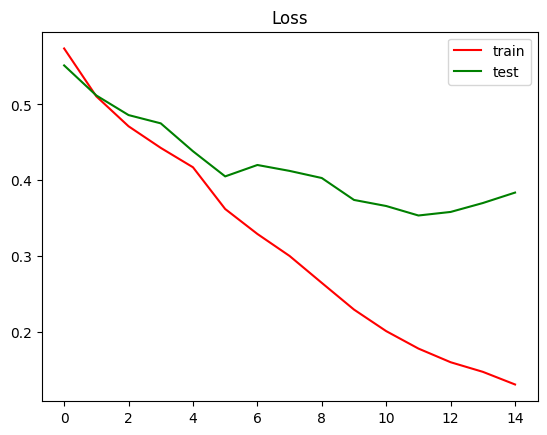

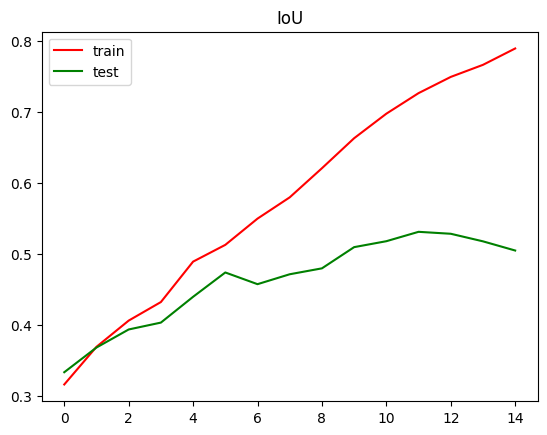

In [ ]:
save_error=True
now = datetime.now() # current date and time
date_time = now.strftime("%mm%dd%Yy%Hh%Mm%Ss")

x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.legend(['train','test'])
plt.title("Loss")

if save_error:
    # plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.legend(['train','test'])
plt.title("IoU")


if save_error:
    # plt.savefig('./results/checkpoints/error_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/error_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

In [ ]:
# x=[x for x in range(len(train_loss_vec))]
# y=[y for y in range(len(test_loss_vec))]
# plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
# plt.legend(['train','test'])
# plt.title("Loss")
# plt.show()

# x=[x for x in range(len(train_error_vec))]
# y=[y for y in range(len(test_error_vec))]
# plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
# plt.legend(['train','test'])
# plt.title("IoU")

# save_error=True
# now = datetime.now() # current date and time
# date_time = now.strftime("%m-%d-%Y-%H:%M:%S")
# if save_error: plt.savefig('./results/checkpoints/error_prueba'+date_time+'.png',format='png',transparent=True)
# plt.show()

In [ ]:
# torch.save(test_loader, './results/checkpoints/test_loader.pt')
# torch.save(train_loader,'./results/checkpoints/train_loader.pt')

#TEST loop

In [ ]:
    running_test_loss = 0
    running_test_IOU = 0
    MultiStep=False
    net.eval()
    show=True
    test_i=0
    with torch.no_grad():
        start_time = time.time()
        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            test_i += 1
            functional.reset_net(net)
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)
            if MultiStep:   #sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()

            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)
            spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346])
                spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
            spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

            if show:
                #condition to colapse all timesteps in every batch for monitoring only
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                # print("spike_pred numbers from net: ",torch.unique(spike_pred_list[2])," of size: ",spike_pred_list[2].size())
                # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_input_5D.size(0)):
                    show_learning(fig,False,
                                  spike_input_5D[None,e,:,:,:,:],
                                  spike_pred_4D[None,e,:,:,:],
                                  spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            # loss = loss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)
            loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)

            running_test_loss += loss / spikes_input.size(0)
            spike_pred = torch.round(spike_pred)
            running_test_IOU += getIOU(spike_pred, spike_mask_4D)

                # process saved metrics
        if test_i != 0:
            epoch_test_loss = running_test_loss / test_i #len(test_loader)
            epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            print("\n test i: ",test_i)
            print("len test loader: ", len(test_loader))
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_IOU))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            print(test_epoch_summary)


testing:   0%|          | 0/2994 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
testing:   1%|          | 22/2994 [00:29<1:06:47,  1.35s/it]


IndexError: list index out of range

#PLOTs

NameError: ignored

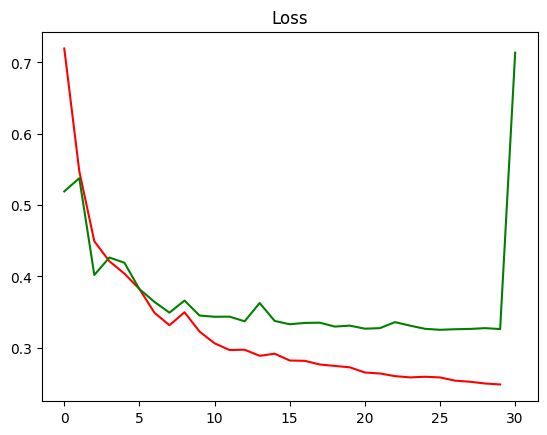

In [ ]:
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.title("Loss")
plt.legend([train,test])
plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.title("IoU")
plt.legend([train,test])
plt.show()

#TRAIN

# POOLINGNET

/content/drive/MyDrive/StereoSpikeA

/content/drive/MyDrive/StereoSpikeA/network/SNN_models.py
/content/drive/MyDrive/StereoSpikeA/test.py
/content/drive/MyDrive/StereoSpikeA/train.py
/content/drive/MyDrive/StereoSpikeA/requirements.txt
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/mvsec_dataset.py
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/utils.py
/content/drive/MyDrive/StereoSpikeA/network/loss2.py

/content/drive/MyDrive/StereoSpikeA/viz.py
/content/drive/MyDrive/StereoSpikeA/train_evimo.py
/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/base.py

--------------------

/content/drive/MyDrive/SpikeMS
/content/drive/MyDrive/SpikeMS/slayerpytorch/src/loss.py
/content/drive/MyDrive/SpikeMS/train.py
/content/drive/MyDrive/SpikeMS/runner2.py

In [ ]:
from torchsummary import summary
train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []


total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0

In [ ]:
from spikingjelly.activation_based import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

# functional.reset_net(net)

for epoch in range(n_epochs):
    train_i = 0
    test_i = 0

    show=False
    net = net.train()                                                   #<--------   0
    running_train_loss = 0
    running_train_IOU = 0
    start_time = time.time()
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if (data == None):
                # print(len(train_loader))
                continue
            optimizer.zero_grad()
            train_i += 1
            functional.reset_net(net)                                   #<--------  6
            spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']

            spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)
            if MultiStep:                                               #   sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
            spike_pred_list = net(spikes_input)
            spike_pred = spike_pred_list[3].to(device)
            spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                # spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,1,1,260,346)
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (2),keepdim=False)               #torch.Size([B, 1, 260, 346])
                # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and remove of TS dim
            spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of C dim
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.gt(spike_mask_4D, 1)

            if show:
                    #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
                print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print(" spike_pred numbers from net: ",torch.unique(spike_pred_list[3])," of size: ",spike_pred_list[3].size())
                print(" spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print(" spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                print(" spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_input_5D.size(0)): #iterates the batches dim=0
                    show_learning(fig,False,
                                  spike_input_5D[None,e,:,:,:,:],
                                  spike_pred_4D[None,e,:,:,:],
                                  spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)        #<--------  3
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
            loss.backward(retain_graph=True)                                         #<--------  4
            optimizer.step()                                        #<--------  5
            functional.reset_net(net)
            # optimizer.zero_grad()                               #<--------   1
            running_train_loss += loss.item() / spikes_input.size(0)
            spike_pred = torch.round(spike_pred)
            running_train_IOU += getIOU(spike_pred,spike_mask_4D)

                # process saved metrics
        if train_i != 0:
            epoch_train_loss = running_train_loss / train_i # len(train_loader)
            print("\n train i: ",train_i)
            print("len train loader: ", len(train_loader))
            epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_IOU))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)

        # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################
    running_test_loss = 0
    running_test_IOU = 0
    net.eval()
    show=True

    with torch.no_grad():
        start_time = time.time()
        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            test_i += 1
            functional.reset_net(net)
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)
            if MultiStep:   #sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()

            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)
            spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346])
                spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
            spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

            if show:
                #condition to colapse all timesteps in every batch for monitoring only
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                # print("spike_pred numbers from net: ",torch.unique(spike_pred_list[2])," of size: ",spike_pred_list[2].size())
                # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_input_5D.size(0)):
                    show_learning(fig,False,
                                  spike_input_5D[None,e,:,:,:,:],
                                  spike_pred_4D[None,e,:,:,:],
                                  spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

            running_test_loss += loss / spikes_input.size(0)
            spike_pred = torch.round(spike_pred)
            running_test_IOU += getIOU(spike_pred, spike_mask_4D)

                # process saved metrics
        if test_i != 0:
            epoch_test_loss = running_test_loss / test_i #len(test_loader)
            epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            print("\n test i: ",test_i)
            print("len test loader: ", len(test_loader))
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_IOU))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            print(train_epoch_summary + test_epoch_summary)
            logfile.write(train_epoch_summary + test_epoch_summary)

        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec
                        }, "./results/checkpoints/best_poolingnet_seg_if_orgnl_table_lifnode.pth")

        print("Performance saved: saving model...\n")
        torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
                    'test_loss_vec_dict': test_loss_vec,
                    'train_error_vec_dict': train_error_vec,
                    'test_error_vec_dict': test_error_vec
                    }, "./results/checkpoints/poolingnet_seg_if_orgnl_table_lifnode.pth")

        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.legend(['train','test'])
        plt.title("Loss")
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.legend(['train','test'])
        plt.title("IoU (%)")
        plt.show()
print("training finished !")

training:   0%|          | 3/2427 [00:03<46:42,  1.16s/it]


ValueError: ignored

# POOLINGNET 3D

https://github.com/wolny/pytorch-3dunet/tree/master

/content/drive/MyDrive/StereoSpikeA
/content/drive/MyDrive/StereoSpikeA/OF_EV_SNN/network_3d
/content/drive/MyDrive/StereoSpikeA/network/loss2.py


--------------------

/content/drive/MyDrive/SpikeMS
/content/drive/MyDrive/SpikeMS/slayerpytorch/src/loss.py
/content/drive/MyDrive/SpikeMS/train.py
/content/drive/MyDrive/SpikeMS/runner2.py

In [1]:
### starts a new training
# from torchsummary import summary
train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []
running_train_loss = 0
running_train_IOU = 0
running_test_loss = 0
running_test_IOU = 0
ckpt_train_i = 0
ckpt_test_i = 0
train_i = 0
test_i = 0

# ### starts a new training
# # from torchsummary import summary
# train_loss_vec = []
# train_error_vec = []
# test_loss_vec = []
# test_error_vec = []
# ckpt_train_i = 0
# ckpt_test_i = 0
# train_i = 0
# test_i = 0
# # epoch_test_loss = 0

# total_MSE = 0
# total_IOU = 0
# scalar_i = 0
# tot_frames = 0
# # ckpt_idx_train = 5300  #index of training loop
# # ckpt_idx_test = 0  #index of training loop

In [ ]:
# print("resuming training from i: "+str(int(train_i)))
print("resuming training from i: "+str(int(ckpt_train_i))+" test_i: "+str(int(ckpt_test_i)))
ckpt_train_i=0

resuming training from i: 0 test_i: 0


## Train

In [ ]:
from spikingjelly.activation_based import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

# ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

functional.reset_net(net)
if int(ckpt_train_i) >10:
    print("resuming training from checkpoint: train_i: "+str(ckpt_train_i)+", train_loss: "+str(running_train_loss)+", train_IOU: "+str(running_train_IOU))
train_i=0
test_i=0
for epoch in range(n_epochs):
    show=False
    net = net.train()                                                   #<--------   0

    start_time = time.time()
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if (data == None):
                # ckpt_i = i
                # print(len(train_loader))
                continue
            train_i += 1
            if ckpt_train_i > train_i:
            #     # print(str(i)+"<"+str(train_i))
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

            optimizer.zero_grad()

            # functional.reset_net(net)                                   #<--------  6
            spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_train = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)
            # if MultiStep:                                               #   sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
            spike_pred_list = net(spikes_input)
            spike_pred = spike_pred_list[0].to(device)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                # spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (1,21,260,346)
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0),keepdim=False)    #reduces B dim           #torch.Size([ 1, 21, 260, 346])
                # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

            # spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            spike_mask_4D = torch.any(spikes_masked_crop, dim = 1,keepdim=False) #or and remove of B dim


            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of C dim
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.gt(spike_mask_4D, 1)

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
                print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print(" spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                print(" spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print(" spike_pred numbers to viz: ",torch.unique(spike_pred_viz)," of size: ",spike_pred_viz.size())
                print(" spike_mask numbers to viz: ",torch.unique(spike_mask_viz)," of size: ",spike_mask_viz.size())
                # if spike_pred.size(0) > 10:
                #     for e in range(spike_pred.size(0)): #iterates the batches dim=0
                #         show_learning(fig,False,
                #                     spike_input_5D[None,e,:,:,:,:],
                #                     spike_pred_viz[None,e,:,:,:],
                #                     spike_mask_viz[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # elif spike_pred.size(2) > 10:
                #     for e in range(spike_pred.size(2)): #iterates the time dim=2
                #         show_learning(fig,False,
                #                     spikes_input[None,:,:,e,:,:],
                #                     spike_pred_4D[None,:,e,:,:],
                #                     spike_mask_4D[None,:,e,:,:], 'segm, timestep '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # else:
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    # show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)        #<--------  3
            # loss = vanrossumloss_module(spike_pred_4D, spike_mask_4D,2.0)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
            # loss.backward(retain_graph=False)                                         #<--------  4
            loss.backward()
            optimizer.step()                                        #<--------  5
            functional.reset_net(net)
            # optimizer.zero_grad()                               #<--------   1
            running_train_loss += loss.item() #/ spikes_input.size(0) # loss/batch_number
            spike_pred_4D = torch.round(spike_pred_4D)
            running_train_IOU += getIOU(spike_pred_4D,spike_mask_4D)


            if int(train_i) % 200 <= 1: #condition to save intermediate trainings
                print("saving training at i: "+str(train_i)+", sequence: "+str(data['file_number'])+", train_loss: "+str(running_train_loss)+", train_IOU: "+str(running_train_IOU))
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'running_train_loss': running_train_loss,
                'running_train_IOU': running_train_IOU,
                'running_test_loss': running_test_loss,
                'running_test_IOU': running_test_IOU,
                'ckpt_idx_train': train_i,
                'ckpt_idx_test': test_i
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if train_i != 0:
            epoch_train_loss = running_train_loss / train_i # len(train_loader)
            epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
            print("\n train i: ", train_i)
            print("len train loader: ", len(train_loader))
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_IOU))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)
        ckpt_train_i = train_i #temporary variable to transport the state of iterations to test loop
        # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################   TEST LOOP ##################
    if int(ckpt_test_i) >10: print("resuming training from checkpoint: train_i: "+str(ckpt_test_i)+", train_loss: "+str(running_test_loss)+", train_IOU: "+str(running_test_IOU))

    net.eval()
    show=False

    with torch.no_grad():
        start_time = time.time()
        if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))

        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            test_i += 1
            if ckpt_test_i > test_i:
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

            functional.reset_net(net)
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_test = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)
            # if MultiStep:   #sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()

            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                #condition to colapse all timesteps in every batch for monitoring only
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

            running_test_loss += loss.item()# / spikes_input.size(0)
            spike_pred_4D = torch.round(spike_pred_4D)
            running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

            if int(test_i) % 200 <= 1: #condition to save intermediate trainings
                print("saving testing at i: "+str(i)+", sequence: "+str(data['file_number'])+"")
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'running_train_loss': running_train_loss,
                'running_train_IOU': running_train_IOU,
                'running_test_loss': running_test_loss,
                'running_test_IOU': running_test_IOU,
                'ckpt_idx_train': train_i,
                'ckpt_idx_test': test_i,
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if test_i != 0:
            epoch_test_loss = running_test_loss / test_i #len(test_loader)
            epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            print("\n test i: ",test_i)
            print("len test loader: ", len(test_loader))
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_IOU))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            print(train_epoch_summary + test_epoch_summary)
            # logfile.write(train_epoch_summary + test_epoch_summary)

        # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)
        now = datetime.now() # current date and time
        date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            # logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        # 'loss': epoch_test_loss,
                        'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec,
                        'running_train_loss': running_train_loss,
                        'running_train_IOU': running_train_IOU,
                        'running_test_loss': running_test_loss,
                        'running_test_IOU': running_test_IOU,
                        'ckpt_idx_train': train_i,
                        'ckpt_idx_test': test_i
                        }, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")

        print("Performance saved: saving model...\n")
        torch.save({'epoch': epoch,
                    'model_state_dict': net.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    # 'loss': epoch_test_loss,
                    'train_loss_vec_dict': train_loss_vec,
                    'test_loss_vec_dict': test_loss_vec,
                    'train_error_vec_dict': train_error_vec,
                    'test_error_vec_dict': test_error_vec,
                    'running_train_loss': running_train_loss,
                    'running_train_IOU': running_train_IOU,
                    'running_test_loss': running_test_loss,
                    'running_test_IOU': running_test_IOU,
                    'ckpt_idx_train': train_i,
                    'ckpt_idx_test': test_i
                    }, "./results/checkpoints/"+ckpt_file+".pth")

        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.legend(['train','test'])
        plt.title("Loss")

        save_loss=True
        if save_loss: plt.savefig('./results/checkpoints/loss_test'+dataset_name+date_time+'.png',format='png',transparent=True)
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.legend(['train','test'])
        plt.title("IoU (%)")

        save_error=True
        if save_error: plt.savefig('./results/checkpoints/error_test'+dataset_name+date_time+'.png',format='png',transparent=True)
        plt.show()

    train_i = 0
    test_i = 0
    ckpt_train_i = 0
    ckpt_test_i = 0
    running_train_loss = 0
    running_train_IOU = 0
    running_test_loss = 0
    running_test_IOU = 0


print("training finished !")

training:   0%|          | 0/3741 [00:00<?, ?it/s]/content/drive/MyDrive/StereoSpike/datasets/MVSEC/mvsec_dataset.py:529: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  depthmask = torch.from_numpy(fullmask)
/content/drive/MyDrive/StereoSpike/datasets/MVSEC/mvsec_dataset.py:529: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Tr

ValueError: ignored

In [ ]:
# from spikingjelly.activation_based import neuron, layer, surrogate
# from torch._C import dtype
# MultiStep=False
# from viz import show_learning

# # ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

# functional.reset_net(net)
# if int(ckpt_train_i) >10:
#     print("resuming "+dataset_name+" train from chkpnt: train_i: "+str(int(ckpt_train_i))+", loss: "+str(running_train_loss)+", IOU: "+str(running_train_IOU))
# train_i=0
# test_i=0
# for epoch in range(n_epochs):
#     show=False
#     net = net.train()                                                   #<--------   0
#     start_time = time.time()

#     with torch.autograd.set_detect_anomaly(True):
#         for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
#             if (data == None):
#                 # ckpt_i = i
#                 # print(len(train_loader))
#                 continue
#             train_i += 1
#             if ckpt_train_i > train_i:
#             #     # print(str(i)+"<"+str(train_i))
#                 continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

#             optimizer.zero_grad()

#             # functional.reset_net(net)                                   #<--------  6
#             spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
#             spikes_masked = data['masked_spike_tensor']
#             # ckpt_idx_train = data['file_number']
#             spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
#             spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)
#             # if MultiStep:                                               #   sums all time steps in the dim=0
#             #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
#             #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
#             spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
#             # us = nn.Upsample(size = [1,2,10,180,240], mode='nearest')
#             us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')
#             spikes_input = us(spikes_input)
#             spikes_masked = spikes_masked.to(device)
#             spikes_masked = us(spikes_masked)
#             # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
#             spike_pred_list = net(spikes_input)
#             spike_pred = spike_pred_list[0].to(device)
#             # spike_pred = torch.sigmoid(spike_pred)

#             if spike_pred.ndim == 4:
#                 # spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
#                 spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (1,21,260,346)
#                 spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

#             elif spike_pred.ndim == 5:
#                 spike_pred_4D = torch.sum(spike_pred, axis = (0),keepdim=False)    #reduces B dim           #torch.Size([ 1, 21, 260, 346])
#                 # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
#                 spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

#             spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
#             # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of C dim
#             spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
#             # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
#             # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
#             # spike_mask_4D = torch.gt(spike_mask_4D, 1)

#             if show:
#                 spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
#                 spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
#                     #condition to colapse all timesteps in every batch
#                 spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
#                 spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
#                 print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
#                 print(" spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
#                 print(" spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
#                 print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
#                 print(" spike_pred numbers to viz: ",torch.unique(spike_pred_viz)," of size: ",spike_pred_viz.size())
#                 print(" spike_mask numbers to viz: ",torch.unique(spike_mask_viz)," of size: ",spike_mask_viz.size())
#                 # if spike_pred.size(0) > 10:
#                 #     for e in range(spike_pred.size(0)): #iterates the batches dim=0
#                 #         show_learning(fig,False,
#                 #                     spike_input_5D[None,e,:,:,:,:],
#                 #                     spike_pred_viz[None,e,:,:,:],
#                 #                     spike_mask_viz[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
#                 # elif spike_pred.size(2) > 10:
#                 #     for e in range(spike_pred.size(2)): #iterates the time dim=2
#                 #         show_learning(fig,False,
#                 #                     spikes_input[None,:,:,e,:,:],
#                 #                     spike_pred_4D[None,:,e,:,:],
#                 #                     spike_mask_4D[None,:,e,:,:], 'segm, timestep '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
#                 # else:
#                 for e in range(spike_pred.size(0)): #iterates the batches dim=0
#                     for i in range(spike_pred.size(2)): #iterates the time dim=2
#                         show_learning(fig,False,
#                                 spikes_input[None,None,e,:,i,:,:],
#                                 spike_pred_4D[:,None,i,:,:],
#                                 spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
#                     # show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

#             loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)        #<--------  3
#             # loss = vanrossumloss_module(spike_pred_4D, spike_mask_4D,2.0)
#             # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
#             # loss.backward(retain_graph=False)                                         #<--------  4
#             loss.backward()
#             optimizer.step()                                        #<--------  5
#             functional.reset_net(net)
#             # optimizer.zero_grad()                               #<--------   1
#             running_train_loss += loss.item() #/ spikes_input.size(0) # loss/batch_number
#             spike_pred_4D = torch.round(spike_pred_4D)
#             running_train_IOU += getIOU(spike_pred_4D,spike_mask_4D)

#             if int(train_i) % 200 <= 1: #condition to save intermediate trainings
#                 print("saving train_i:"+str(train_i)+", seq:"+str(int(data['file_number']))+",loss: "+str(running_train_loss)+",IOU: "+str(running_train_IOU)+"_"+dataset_name)
#                 torch.save({'epoch': epoch,
#                 'model_state_dict': net.state_dict(),
#                 'optimizer_state_dict': optimizer.state_dict(),
#                 # 'loss': epoch_test_loss,
#                 'train_loss_vec_dict': train_loss_vec,
#                 'test_loss_vec_dict': test_loss_vec,
#                 'train_error_vec_dict': train_error_vec,
#                 'test_error_vec_dict': test_error_vec,
#                 'running_train_loss': running_train_loss,
#                 'running_train_IOU': running_train_IOU,
#                 'running_test_loss': running_test_loss,
#                 'running_test_IOU': running_test_IOU,
#                 'ckpt_idx_train': train_i,
#                 'ckpt_idx_test': test_i
#                 }, "./results/checkpoints/"+ckpt_file+"2.pth")

#                 # process saved metrics
#     if train_i != 0:
#         epoch_train_loss = running_train_loss / train_i # len(train_loader)
#         epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
#         print("\n train i: ", train_i)
#         print("len train loader: ", len(train_loader))
#         train_loss_vec.append(float(epoch_train_loss))
#         train_error_vec.append(float(epoch_train_IOU))
#         epoch_train_time = time.time() - start_time
#         train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)
#     ckpt_train_i = train_i #temporary variable to transport the state of iterations to test loop
#         # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
#         # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
#         #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
# #################   TEST LOOP ##################
#     if int(ckpt_test_i) >10: print("resuming training from checkpoint: train_i: "+str(ckpt_test_i)+", train_loss: "+str(running_test_loss)+", train_IOU: "+str(running_test_IOU))

#     net.eval()
#     show=False

#     with torch.no_grad():
#         start_time = time.time()
#         if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))

#         for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
#             if (data == None):
#                 continue
#             test_i += 1
#             if ckpt_test_i > test_i:
#                 continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

#             functional.reset_net(net)
#             optimizer.zero_grad()
#             spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
#             spikes_masked = data['masked_spike_tensor']
#             # ckpt_idx_test = data['file_number']
#             spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
#             spikes_masked = spikes_masked.permute(0,1,4,2,3)
#             # if MultiStep:   #sums all time steps in the dim=0
#             #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
#             #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
#             spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])

#             us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')
#             spikes_input = us(spikes_input)
#             spikes_masked = spikes_masked.to(device)
#             spikes_masked = us(spikes_masked)
#             spikes_input.requires_grad_()

#             spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
#             spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
#             # spike_pred = torch.sigmoid(spike_pred)

#             if spike_pred.ndim == 4:
#                 spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
#                 spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
#                 #spike_pred_4D = spike_pred
#                 spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

#             elif spike_pred.ndim == 5:
#                 spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
#                 # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
#                 spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

#             spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
#             # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
#             spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
#             # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
#             # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
#             # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

#             # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
#             # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

#             if show:
#                 spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
#                 spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
#                 #condition to colapse all timesteps in every batch for monitoring only
#                 spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
#                 spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
#                 # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
#                 # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
#                 # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
#                 # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
#                 # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
#                 # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
#                 for e in range(spike_pred.size(0)): #iterates the batches dim=0
#                     for i in range(spike_pred.size(2)): #iterates the time dim=2
#                         show_learning(fig,False,
#                                 spikes_input[None,None,e,:,i,:,:],
#                                 spike_pred_4D[:,None,i,:,:],
#                                 spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
#                 #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

#             loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
#             # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

#             running_test_loss += loss.item()# / spikes_input.size(0)
#             spike_pred_4D = torch.round(spike_pred_4D)
#             running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

#             if int(test_i) % 200 <= 1: #condition to save intermediate trainings
#                 print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+"_"+dataset_name+" "+dataset_name)
#                 torch.save({'epoch': epoch,
#                 'model_state_dict': net.state_dict(),
#                 'optimizer_state_dict': optimizer.state_dict(),
#                 # 'loss': epoch_test_loss,
#                 'train_loss_vec_dict': train_loss_vec,
#                 'test_loss_vec_dict': test_loss_vec,
#                 'train_error_vec_dict': train_error_vec,
#                 'test_error_vec_dict': test_error_vec,
#                 'running_train_loss': running_train_loss,
#                 'running_train_IOU': running_train_IOU,
#                 'running_test_loss': running_test_loss,
#                 'running_test_IOU': running_test_IOU,
#                 'ckpt_idx_train': train_i,
#                 'ckpt_idx_test': test_i,
#                 }, "./results/checkpoints/"+ckpt_file+"2.pth")

#                 # process saved metrics
#         if test_i != 0:
#             epoch_test_loss = running_test_loss / test_i #len(test_loader)
#             epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
#             print("\n test i: ",test_i)
#             print("len test loader: ", len(test_loader))
#             test_loss_vec.append(float(epoch_test_loss))
#             test_error_vec.append(float(epoch_test_IOU))
#             epoch_test_time = time.time() - start_time
#             test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
#             print(train_epoch_summary + test_epoch_summary)
#             # logfile.write(train_epoch_summary + test_epoch_summary)

#         # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
#         # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)
#         now = datetime.now() # current date and time
#         date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
#         if epoch_test_loss < net.get_max_accuracy():
#             print("Best performances so far: saving model...\n")
#             # logfile.write("Best performances so far: saving model...\n")
#             net.update_max_accuracy(epoch_test_loss)
#             #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
#             torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
#                         'optimizer_state_dict': optimizer.state_dict(),
#                         # 'loss': epoch_test_loss,
#                         'train_loss_vec_dict': train_loss_vec,
#                         'test_loss_vec_dict': test_loss_vec,
#                         'train_error_vec_dict': train_error_vec,
#                         'test_error_vec_dict': test_error_vec,
#                         'running_train_loss': running_train_loss,
#                         'running_train_IOU': running_train_IOU,
#                         'running_test_loss': running_test_loss,
#                         'running_test_IOU': running_test_IOU,
#                         'ckpt_idx_train': train_i,
#                         'ckpt_idx_test': test_i
#                         }, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+"2.pth")

#         print("Performance saved: saving model...\n")
#         torch.save({'epoch': epoch,
#                     'model_state_dict': net.state_dict(),
#                     'optimizer_state_dict': optimizer.state_dict(),
#                     # 'loss': epoch_test_loss,
#                     'train_loss_vec_dict': train_loss_vec,
#                     'test_loss_vec_dict': test_loss_vec,
#                     'train_error_vec_dict': train_error_vec,
#                     'test_error_vec_dict': test_error_vec,
#                     'running_train_loss': running_train_loss,
#                     'running_train_IOU': running_train_IOU,
#                     'running_test_loss': running_test_loss,
#                     'running_test_IOU': running_test_IOU,
#                     'ckpt_idx_train': train_i,
#                     'ckpt_idx_test': test_i
#                     }, "./results/checkpoints/"+ckpt_file+".pth")

#         net.increment_epoch()
#         scheduler.step()
#         # Training/testing plots
#         x=[x for x in range(len(train_loss_vec))]
#         y=[y for y in range(len(test_loss_vec))]
#         plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
#         plt.legend(['train','test'])
#         plt.title("Loss")

#         save_loss=True
#         if save_loss: plt.savefig('./results/checkpoints/loss_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
#         plt.show()

#         x=[x for x in range(len(train_error_vec))]
#         y=[y for y in range(len(test_error_vec))]
#         plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
#         plt.legend(['train','test'])
#         plt.title("IoU (%)")

#         save_error=True
#         if save_error: plt.savefig('./results/checkpoints/error_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
#         plt.show()

#     train_i = 0
#     test_i = 0
#     ckpt_train_i = 0
#     ckpt_test_i = 0

#     running_train_loss = 0
#     running_train_IOU = 0
#     running_test_loss = 0
#     running_test_IOU = 0


# print("training finished !")

In [ ]:
# from spikingjelly.activation_based import neuron, layer, surrogate
# from torch._C import dtype
# MultiStep=False
# from viz import show_learning
# ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
# # ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

# functional.reset_net(net)
# if int(train_i) >10: print("resuming training from i: "+str(int(train_i)))

# for epoch in range(n_epochs):
#     show=False
#     net = net.train()                                                   #<--------   0
#     running_train_loss = 0
#     running_train_IOU = 0
#     start_time = time.time()
#     with torch.autograd.set_detect_anomaly(True):
#         for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
#             if i < train_i:
#             #     # print(str(i)+"<"+str(train_i))
#                 continue # skips batches until it arrives to checkpoint of an incomplete epoch of training
#             if (data == None):
#                 # print(len(train_loader))
#                 continue
#             optimizer.zero_grad()
#             train_i += 1
#             # functional.reset_net(net)                                   #<--------  6
#             spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
#             spikes_masked = data['masked_spike_tensor']
#             # ckpt_idx_train = data['file_number']
#             spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
#             spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)
#             if MultiStep:                                               #   sums all time steps in the dim=0
#                 spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
#                 spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
#             spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
#             spikes_masked = spikes_masked.to(device)
#             # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
#             spike_pred_list = net(spikes_input)
#             spike_pred = spike_pred_list[0].to(device)
#             # spike_pred = torch.sigmoid(spike_pred)

#             if spike_pred.ndim == 4:
#                 # spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
#                 spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (1,21,260,346)
#                 spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

#             elif spike_pred.ndim == 5:
#                 spike_pred_4D = torch.sum(spike_pred, axis = (0),keepdim=False)    #reduces B dim           #torch.Size([ 1, 21, 260, 346])
#                 # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
#                 spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

#             spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
#             # spike_mask_4D = torch.any(spike_mask_4D, dim = 1, keepdim=True)      #or of C dim
#             spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
#             # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
#             # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
#             # spike_mask_4D = torch.gt(spike_mask_4D, 1)

#             if show:
#                 spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
#                 spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
#                     #condition to colapse all timesteps in every batch
#                 spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
#                 spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
#                 print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
#                 print(" spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
#                 print(" spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
#                 print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
#                 print(" spike_pred numbers to viz: ",torch.unique(spike_pred_viz)," of size: ",spike_pred_viz.size())
#                 print(" spike_mask numbers to viz: ",torch.unique(spike_mask_viz)," of size: ",spike_mask_viz.size())
#                 # if spike_pred.size(0) > 10:
#                 #     for e in range(spike_pred.size(0)): #iterates the batches dim=0
#                 #         show_learning(fig,False,
#                 #                     spike_input_5D[None,e,:,:,:,:],
#                 #                     spike_pred_viz[None,e,:,:,:],
#                 #                     spike_mask_viz[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
#                 # elif spike_pred.size(2) > 10:
#                 #     for e in range(spike_pred.size(2)): #iterates the time dim=2
#                 #         show_learning(fig,False,
#                 #                     spikes_input[None,:,:,e,:,:],
#                 #                     spike_pred_4D[None,:,e,:,:],
#                 #                     spike_mask_4D[None,:,e,:,:], 'segm, timestep '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
#                 # else:
#                 for e in range(spike_pred.size(0)): #iterates the batches dim=0
#                     for i in range(spike_pred.size(2)): #iterates the time dim=2
#                         show_learning(fig,False,
#                                 spikes_input[None,None,e,:,i,:,:],
#                                 spike_pred_4D[:,None,i,:,:],
#                                 spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
#                     # show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

#             # print("Spike_pred_4D: ", spike_pred_4D.unique())
#             loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=1)        #<--------  3
#             # loss = vanrossumloss_module(spike_pred_4D, spike_mask_4D,2.0)
#             # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
#             # loss.backward(retain_graph=False)                                         #<--------  4
#             loss.backward()
#             optimizer.step()                                        #<--------  5
#             functional.reset_net(net)
#             # optimizer.zero_grad()                               #<--------   1
#             running_train_loss += loss.item() / spikes_input.size(0)
#             spike_pred_4D = torch.round(spike_pred_4D)
#             running_train_IOU += getIOU(spike_pred_4D,spike_mask_4D)


#             if int(i) % 100 == 0: #condition to save intermediate trainings
#                 print("saving training at i: "+str(train_i)+", sequence: "+str(data['file_number']))
#                 torch.save({'epoch': epoch,
#                 'model_state_dict': net.state_dict(),
#                 'optimizer_state_dict': optimizer.state_dict(),
#                 # 'loss': epoch_test_loss,
#                 'train_loss_vec_dict': train_loss_vec,
#                 'test_loss_vec_dict': test_loss_vec,
#                 'train_error_vec_dict': train_error_vec,
#                 'test_error_vec_dict': test_error_vec,
#                 'ckpt_idx_train': i,
#                 'ckpt_idx_test': 0
#                 }, "./results/checkpoints/"+ckpt_file+".pth")

#                 # process saved metrics
#         if train_i != 0:
#             epoch_train_loss = running_train_loss / train_i # len(train_loader)
#             epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
#             print("\n train i: ", train_i)
#             print("len train loader: ", len(train_loader))
#             train_loss_vec.append(float(epoch_train_loss))
#             train_error_vec.append(float(epoch_train_IOU))
#             epoch_train_time = time.time() - start_time
#             train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)
#         ckpt_train_i = train_i #temporary variable to transport the state of iterations to test loop
#         # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
#         # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
#         #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
# #################   TEST LOOP ##################
#     running_test_loss = 0
#     running_test_IOU = 0
#     net.eval()
#     show=True

#     with torch.no_grad():
#         start_time = time.time()
#         if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))
#         for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
#             if i < test_i:
#                 continue # skips batches until it arrives to checkpoint of an incomplete epoch of training
#             if (data == None):
#                 continue
#             test_i += 1
#             functional.reset_net(net)
#             optimizer.zero_grad()
#             spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
#             spikes_masked = data['masked_spike_tensor']
#             # ckpt_idx_test = data['file_number']
#             spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
#             spikes_masked = spikes_masked.permute(0,1,4,2,3)
#             if MultiStep:   #sums all time steps in the dim=0
#                 spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
#                 spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
#             spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
#             spikes_masked = spikes_masked.to(device)
#             spikes_input.requires_grad_()

#             spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
#             spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
#             # spike_pred = torch.sigmoid(spike_pred)

#             if spike_pred.ndim == 4:
#                 spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
#                 spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
#                 #spike_pred_4D = spike_pred
#                 spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

#             elif spike_pred.ndim == 5:
#                 spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
#                 # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
#                 spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

#             spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
#             # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
#             spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
#             # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
#             # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
#             # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

#             # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
#             # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

#             if show:
#                 spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
#                 spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
#                 #condition to colapse all timesteps in every batch for monitoring only
#                 spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
#                 spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
#                 # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
#                 # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
#                 # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
#                 # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
#                 # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
#                 # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
#                 for e in range(spike_pred.size(0)): #iterates the batches dim=0
#                     for i in range(spike_pred.size(2)): #iterates the time dim=2
#                         show_learning(fig,False,
#                                 spikes_input[None,None,e,:,i,:,:],
#                                 spike_pred_4D[:,None,i,:,:],
#                                 spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
#                 #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

#             loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=1)
#             # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

#             running_test_loss += loss.item() / spikes_input.size(0)
#             spike_pred_4D = torch.round(spike_pred_4D)
#             running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

#             if int(i) % 100 == 0: #condition to save intermediate trainings
#                 print("saving testing at i: "+str(i)+", sequence: "+str(data['file_number']))
#                 torch.save({'epoch': epoch,
#                 'model_state_dict': net.state_dict(),
#                 'optimizer_state_dict': optimizer.state_dict(),
#                 # 'loss': epoch_test_loss,
#                 'train_loss_vec_dict': train_loss_vec,
#                 'test_loss_vec_dict': test_loss_vec,
#                 'train_error_vec_dict': train_error_vec,
#                 'test_error_vec_dict': test_error_vec,
#                 'ckpt_idx_train': train_i,
#                 'ckpt_idx_test': i
#                 }, "./results/checkpoints/"+ckpt_file+".pth")

#                 # process saved metrics
#         if test_i != 0:
#             epoch_test_loss = running_test_loss / test_i #len(test_loader)
#             epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
#             print("\n test i: ",test_i)
#             print("len test loader: ", len(test_loader))
#             test_loss_vec.append(float(epoch_test_loss))
#             test_error_vec.append(float(epoch_test_IOU))
#             epoch_test_time = time.time() - start_time
#             test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
#             print(train_epoch_summary + test_epoch_summary)
#             # logfile.write(train_epoch_summary + test_epoch_summary)

#         # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
#         # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)
#         now = datetime.now() # current date and time
#         date_time = now.strftime("%m%d%Y%H%M%S")
#         if epoch_test_loss < net.get_max_accuracy():
#             print("Best performances so far: saving model...\n")
#             # logfile.write("Best performances so far: saving model...\n")
#             net.update_max_accuracy(epoch_test_loss)
#             #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
#             torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
#                         'optimizer_state_dict': optimizer.state_dict(),
#                         # 'loss': epoch_test_loss,
#                         'train_loss_vec_dict': train_loss_vec,
#                         'test_loss_vec_dict': test_loss_vec,
#                         'train_error_vec_dict': train_error_vec,
#                         'test_error_vec_dict': test_error_vec,
#                         'ckpt_idx_train': train_i,
#                         'ckpt_idx_test': test_i
#                         }, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")

#         print("Performance saved: saving model...\n")
#         torch.save({'epoch': epoch,
#                     'model_state_dict': net.state_dict(),
#                     'optimizer_state_dict': optimizer.state_dict(),
#                     # 'loss': epoch_test_loss,
#                     'train_loss_vec_dict': train_loss_vec,
#                     'test_loss_vec_dict': test_loss_vec,
#                     'train_error_vec_dict': train_error_vec,
#                     'test_error_vec_dict': test_error_vec,
#                     'ckpt_idx_train': train_i,
#                     'ckpt_idx_test': test_i
#                     }, "./results/checkpoints/"+ckpt_file+".pth")

#         net.increment_epoch()
#         scheduler.step()
#         # Training/testing plots
#         x=[x for x in range(len(train_loss_vec))]
#         y=[y for y in range(len(test_loss_vec))]
#         plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
#         plt.legend(['train','test'])
#         plt.title("Loss")
#         plt.show()
#         save_loss=True
#         if save_loss: plt.savefig('./results/checkpoints/loss_.pdf',format='pdf')

#         x=[x for x in range(len(train_error_vec))]
#         y=[y for y in range(len(test_error_vec))]
#         plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
#         plt.legend(['train','test'])
#         plt.title("IoU (%)")
#         plt.show()
#         save_error=True
#         if save_error: plt.savefig('./results/checkpoints/error_.pdf',format='pdf')
#     train_i = 0
#     test_i = 0


# print("training finished !")

training:   0%|          | 0/17325 [00:00<?, ?it/s]

saving training at i: 1, sequence: tensor([0])


training:   1%|          | 101/17325 [08:59<10:39:32,  2.23s/it]

saving training at i: 95, sequence: tensor([100])


training:   1%|          | 201/17325 [15:55<24:07:31,  5.07s/it]

saving training at i: 177, sequence: tensor([200])


training:   2%|▏         | 271/17325 [21:14<23:58:57,  5.06s/it]

In [ ]:
from spikingjelly.activation_based import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
# ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

functional.reset_net(net)
if int(train_i) >10: print("resuming training from i: "+str(int(train_i)))

for epoch in range(n_epochs):
    show=False
    net = net.train()                                                   #<--------   0
    running_train_loss = 0
    running_train_IOU = 0
    start_time = time.time()
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if i < train_i:
            #     # print(str(i)+"<"+str(train_i))
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training
            if (data == None):
                # print(len(train_loader))
                continue
            optimizer.zero_grad()
            train_i += 1
            # functional.reset_net(net)                                   #<--------  6
            spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_train = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)
            # if MultiStep:                                               #   sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
            spike_pred_list = net(spikes_input)
            spike_pred = spike_pred_list[0].to(device)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                # spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (1,21,260,346)
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0),keepdim=False)    #reduces B dim           #torch.Size([ 1, 21, 260, 346])
                # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of C dim
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.gt(spike_mask_4D, 1)

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
                print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print(" spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                print(" spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print(" spike_pred numbers to viz: ",torch.unique(spike_pred_viz)," of size: ",spike_pred_viz.size())
                print(" spike_mask numbers to viz: ",torch.unique(spike_mask_viz)," of size: ",spike_mask_viz.size())
                # if spike_pred.size(0) > 10:
                #     for e in range(spike_pred.size(0)): #iterates the batches dim=0
                #         show_learning(fig,False,
                #                     spike_input_5D[None,e,:,:,:,:],
                #                     spike_pred_viz[None,e,:,:,:],
                #                     spike_mask_viz[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # elif spike_pred.size(2) > 10:
                #     for e in range(spike_pred.size(2)): #iterates the time dim=2
                #         show_learning(fig,False,
                #                     spikes_input[None,:,:,e,:,:],
                #                     spike_pred_4D[None,:,e,:,:],
                #                     spike_mask_4D[None,:,e,:,:], 'segm, timestep '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # else:
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    # show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=1)        #<--------  3
            # loss = vanrossumloss_module(spike_pred_4D, spike_mask_4D,2.0)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
            # loss.backward(retain_graph=False)                                         #<--------  4
            loss.backward()
            optimizer.step()                                        #<--------  5
            functional.reset_net(net)
            # optimizer.zero_grad()                               #<--------   1
            running_train_loss += loss.item() / spikes_input.size(0)
            spike_pred_4D = torch.round(spike_pred_4D)
            running_train_IOU += getIOU(spike_pred_4D,spike_mask_4D)


            if int(i) % 100 == 0: #condition to save intermediate trainings
                print("saving training at i: "+str(train_i)+", sequence: "+str(data['file_number']))
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'ckpt_idx_train': i,
                'ckpt_idx_test': 0
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if train_i != 0:
            epoch_train_loss = running_train_loss / train_i # len(train_loader)
            epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
            print("\n train i: ", train_i)
            print("len train loader: ", len(train_loader))
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_IOU))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)
        ckpt_train_i = train_i #temporary variable to transport the state of iterations to test loop
        # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################   TEST LOOP ##################
    running_test_loss = 0
    running_test_IOU = 0
    net.eval()
    show=False

    with torch.no_grad():
        start_time = time.time()
        if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))
        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if i < test_i:
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training
            if (data == None):
                continue
            test_i += 1
            functional.reset_net(net)
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_test = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)
            # if MultiStep:   #sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()

            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                #condition to colapse all timesteps in every batch for monitoring only
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=1)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

            running_test_loss += loss.item() / spikes_input.size(0)
            spike_pred_4D = torch.round(spike_pred_4D)
            running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

            if int(i) % 100 == 0: #condition to save intermediate trainings
                print("saving testing at i: "+str(i)+", sequence: "+str(data['file_number']))
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'ckpt_idx_train': train_i,
                'ckpt_idx_test': i
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if test_i != 0:
            epoch_test_loss = running_test_loss / test_i #len(test_loader)
            epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            print("\n test i: ",test_i)
            print("len test loader: ", len(test_loader))
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_IOU))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            print(train_epoch_summary + test_epoch_summary)
            # logfile.write(train_epoch_summary + test_epoch_summary)

        # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)
        now = datetime.now() # current date and time
        date_time = now.strftime("%m%d%Y%H%M%S")
        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            # logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        # 'loss': epoch_test_loss,
                        'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec,
                        'ckpt_idx_train': train_i,
                        'ckpt_idx_test': test_i
                        }, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")

        print("Performance saved: saving model...\n")
        torch.save({'epoch': epoch,
                    'model_state_dict': net.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    # 'loss': epoch_test_loss,
                    'train_loss_vec_dict': train_loss_vec,
                    'test_loss_vec_dict': test_loss_vec,
                    'train_error_vec_dict': train_error_vec,
                    'test_error_vec_dict': test_error_vec,
                    'ckpt_idx_train': train_i,
                    'ckpt_idx_test': test_i
                    }, "./results/checkpoints/"+ckpt_file+".pth")

        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.legend(['train','test'])
        plt.title("Loss")

        save_loss=True
        if save_loss: plt.savefig('./results/checkpoints/loss_test'+dataset_name+date_time+'.png',format='png',transparent=True)
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.legend(['train','test'])
        plt.title("IoU (%)")

        save_error=True
        if save_error: plt.savefig('./results/checkpoints/error_test'+dataset_name+date_time+'.png',format='png',transparent=True)
        plt.show()


    train_i = 0
    test_i = 0


print("training finished !")

RuntimeError: ignored

Performance saved: saving model...



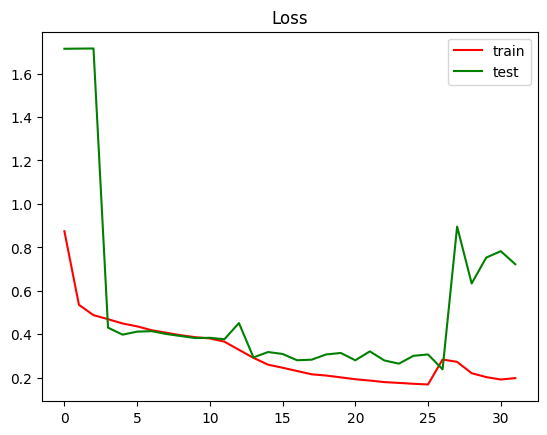

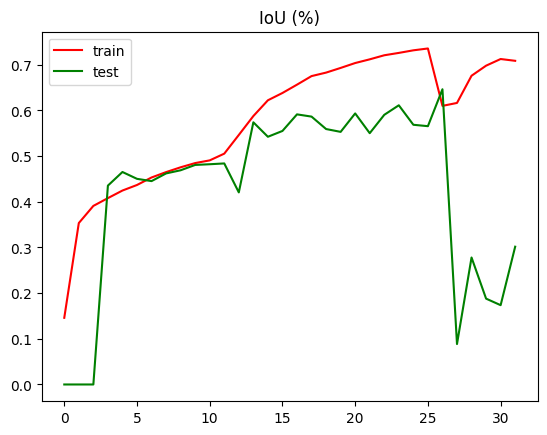

training finished !


<Figure size 640x480 with 0 Axes>

In [ ]:
if epoch_test_loss < net.get_max_accuracy():
    print("Best performances so far: saving model...\n")
    # logfile.write("Best performances so far: saving model...\n")
    net.update_max_accuracy(epoch_test_loss)
    #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
    torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'ckpt_idx_train': ckpt_idx_train,
                'ckpt_idx_test': ckpt_idx_test
                }, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")

print("Performance saved: saving model...\n")
torch.save({'epoch': epoch,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_test_loss,
            'train_loss_vec_dict': train_loss_vec,
            'test_loss_vec_dict': test_loss_vec,
            'train_error_vec_dict': train_error_vec,
            'test_error_vec_dict': test_error_vec,
            'ckpt_idx_train': ckpt_idx_train,
            'ckpt_idx_test': ckpt_idx_test
            }, "./results/checkpoints/"+ckpt_file+".pth")

net.increment_epoch()
scheduler.step()
# Training/testing plots
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.legend(['train','test'])
plt.title("Loss")
plt.show()
save_loss=True
if save_loss: plt.savefig('./results/checkpoints/loss_.pdf',format='pdf')

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.legend(['train','test'])
plt.title("IoU (%)")
plt.show()
save_error=True
if save_error: plt.savefig('./results/checkpoints/error_.pdf',format='pdf')

print("training finished !")

In [ ]:
torch.save({'epoch': epoch,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_test_loss,
            'train_loss_vec_dict': train_loss_vec,
            'test_loss_vec_dict': test_loss_vec,
            'train_error_vec_dict': train_error_vec,
            'test_error_vec_dict': test_error_vec,
            'ckpt_idx_train': ckpt_idx_train,
            'ckpt_idx_test': ckpt_idx_test
            }, "./results/checkpoints/poolingnet3d_seg_if_orgnl_box_lifnode.pth")
# torch.save(train_loader,"./results/checkpoints/train_loader_poolingnet3d_seg_if_orgnl_box_lifnode.pth")
# torch.save(test_loader,"./results/checkpoints/test_loader_poolingnet3d_seg_if_orgnl_box_lifnode.pth")
###


In [ ]:
checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_floor_lifnode.pth') #poolingnet3d_seg_if_orgnl_floor_lifnode.pth
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
epoch_test_loss = checkpoint['loss']
ckpt_idx_test = checkpoint['ckpt_idx_test']
ckpt_idx_train = checkpoint['ckpt_idx_train']
net.update_max_accuracy(epoch_test_loss)

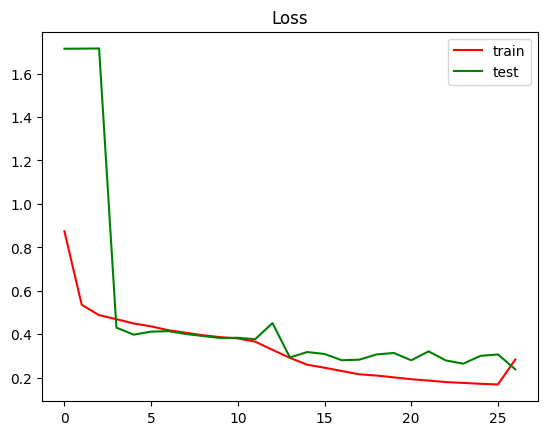

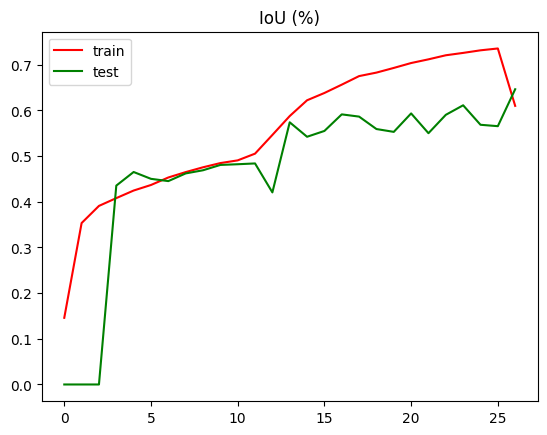

<Figure size 640x480 with 0 Axes>

In [ ]:
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.legend(['train','test'])
        plt.title("Loss")
        plt.show()
        save_loss=True
        if save_loss: plt.savefig('./results/checkpoints/loss_.pdf',format='pdf')

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.legend(['train','test'])
        plt.title("IoU (%)")
        plt.show()
        save_error=True
        if save_error: plt.savefig('./results/checkpoints/error_.pdf',format='pdf')

In [ ]:
epoch_test_loss = 0
torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
            'test_loss_vec_dict': test_loss_vec,
            'train_error_vec_dict': train_error_vec,
            'test_error_vec_dict': test_error_vec
            }, "./results/checkpoints/poolingnet_seg3d_if_orgnl_table_lifnode.pth")

# Train Update

In [ ]:
### starts a new training
# from torchsummary import summary
train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []
running_train_loss = 0
running_train_IOU = 0
running_test_loss = 0
running_test_IOU = 0
ckpt_train_i = 0
ckpt_test_i = 0
train_i = 0
test_i = 0
train_done=False
test_done=False
epoch_test_loss = 0
epoch_test_IOU = 0
epoch_train_loss = 0
epoch_train_IOU = 0
test_epoch_summary = 0
train_epoch_summary = 0

In [ ]:
# # print("./results/checkpoints/"+ckpt_file+"5.pth")
# ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
checkpoint_path = "./results/checkpoints/"+ckpt_file+".pth"
# checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
# # checkpoint = torch.load("./results/checkpoints/"+ckpt_file+"5.pth")
checkpoint = torch.load(checkpoint_path)

train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
running_train_loss = checkpoint['running_train_loss']
running_train_IOU = checkpoint['running_train_IOU']
running_test_loss = checkpoint['running_test_loss']
running_test_IOU = checkpoint['running_test_IOU']
test_epoch_summary = checkpoint['test_epoch_summary']
train_epoch_summary = checkpoint['train_epoch_summary']
epoch_train_loss = checkpoint['epoch_train_loss']
epoch_test_loss = checkpoint['epoch_test_loss']
epoch = checkpoint['epoch']
# net.update_max_accuracy(epoch_test_loss)
ckpt_train_i = checkpoint['ckpt_idx_train']
ckpt_test_i = checkpoint['ckpt_idx_test']
train_done = checkpoint['train_done']
test_done = checkpoint['test_done']
train_i=0
test_i=0

# checkpoint = {'epoch': epoch,
#             'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
#             'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
#             'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
#             'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
#             'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
#             'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
#             'train_done': train_done,'test_done': test_done,
#             'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
#             'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
import sys
try:
    from spikingjelly.activation_based import neuron, layer, surrogate
    from torch._C import dtype
    MultiStep=False
    from viz import show_learning

    # ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

    functional.reset_net(net)
    if int(ckpt_train_i) >10:
        print("resuming training of "+dataset_name+" in epoch "+str(epoch)+" from chkpnt: train_i: "+str(int(ckpt_train_i))+", loss: "+str(running_train_loss)+", IOU: "+str(running_train_IOU))
    train_i=0
    test_i=0

    for epoch in range(n_epochs):
        show=False
        net = net.train()                                                   #<--------   0
        start_time = time.time()

        with torch.autograd.set_detect_anomaly(True):
            for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
                if train_done == True:
                    break
                if (data == None):
                    # ckpt_i = i
                    # print(len(train_loader))
                    continue
                # if i == int(len(train_loader)-2):
                #     print("Training loop finished"+str(i)+"="+str(len(train_loader)))
                #     train_done = 1

                train_i += 1
                if ckpt_train_i > train_i:
                #     # print(str(i)+"<"+str(train_i))
                    continue # skips batches until it arrives to checkpoint of an incomplete epoch of training
                # if i >= (len(train_loader)-1):
                #     print("train finished... ")
                #     continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

                optimizer.zero_grad()

                # functional.reset_net(net)                                   #<--------  6
                spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
                spikes_masked = data['masked_spike_tensor']
                # ckpt_idx_train = data['file_number']
                spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
                spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)
                # if MultiStep:                                               #   sums all time steps in the dim=0
                #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
                spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
    ##
                # us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')  # downsampling to 6,180,240
                # spikes_input = us(spikes_input)
                spikes_masked = spikes_masked.to(device)
                # spikes_masked = us(spikes_masked)
    ##
                spike_pred_list = net(spikes_input)
                spike_pred = spike_pred_list[0].to(device)
                # spike_pred = torch.sigmoid(spike_pred)

                if spike_pred.ndim == 4:
                    # spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                    spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (1,21,260,346)
                    spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

                elif spike_pred.ndim == 5:
                    spike_pred_4D = torch.sum(spike_pred, axis = (0),keepdim=False)    #reduces B dim           #torch.Size([ 1, 21, 260, 346])
                    # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                    spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

                spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of C dim
                spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
                # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
                # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
                # spike_mask_4D = torch.gt(spike_mask_4D, 1)

                if show:
                    spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                    spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                        #condition to colapse all timesteps in every batch
                    spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
                    spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
                    print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                    print(" spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                    print(" spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                    print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                    print(" spike_pred numbers to viz: ",torch.unique(spike_pred_viz)," of size: ",spike_pred_viz.size())
                    print(" spike_mask numbers to viz: ",torch.unique(spike_mask_viz)," of size: ",spike_mask_viz.size())
                    # if spike_pred.size(0) > 10:
                    #     for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    #         show_learning(fig,False,
                    #                     spike_input_5D[None,e,:,:,:,:],
                    #                     spike_pred_viz[None,e,:,:,:],
                    #                     spike_mask_viz[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    # elif spike_pred.size(2) > 10:
                    #     for e in range(spike_pred.size(2)): #iterates the time dim=2
                    #         show_learning(fig,False,
                    #                     spikes_input[None,:,:,e,:,:],
                    #                     spike_pred_4D[None,:,e,:,:],
                    #                     spike_mask_4D[None,:,e,:,:], 'segm, timestep '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    # else:
                    for e in range(spike_pred.size(0)): #iterates the batches dim=0
                        for i in range(spike_pred.size(2)): #iterates the time dim=2
                            show_learning(fig,False,
                                    spikes_input[None,None,e,:,i,:,:],
                                    spike_pred_4D[:,None,i,:,:],
                                    spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                        # show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

                loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)        #<--------  3
                # loss = vanrossumloss_module(spike_pred_4D, spike_mask_4D,2.0)
                # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
                # loss.backward(retain_graph=False)                                         #<--------  4
                loss.backward()
                optimizer.step()                                        #<--------  5
                functional.reset_net(net)
                # optimizer.zero_grad()                               #<--------   1
                running_train_loss += loss.item() #/ spikes_input.size(0) # loss/batch_number
                spike_pred_4D = torch.round(spike_pred_4D)
                running_train_IOU += getIOU(spike_pred_4D,spike_mask_4D)

                if (int(train_i) % 100 <= 0): #condition to save intermediate trainings
                    checkpoint = {'epoch': epoch,
                                'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                                'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                                'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                                'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                                'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                                'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                                'train_done': train_done,'test_done': test_done,
                                'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                                'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                    print("saving train_i:"+str(train_i)+", seq:"+str(int(data['file_number']))+",loss: "+str(running_train_loss)+",IOU: "+str(running_train_IOU)+" for "+dataset_name)
                    torch.save(checkpoint, checkpoint_path)

                    ckpt_train_i = train_i #temporary variable to transport the state of iterations to test loop
                    # process saved metrics

        if train_done == False:
            epoch_train_loss = running_train_loss / train_i # len(train_loader)
            epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
            # print("i: ", i)
            print("train i: ", train_i)
            print("len train loader: ", len(train_loader))
            # print("train_done: ", train_done)
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_IOU))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)

            #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
            checkpoint = {'epoch': epoch,
                        'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                        'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                        'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                        'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                        'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                        'train_done': train_done,'test_done': test_done,
                        'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                        'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
            print("Train finished, saving...")
            torch.save(checkpoint, checkpoint_path)
            train_done = True
        else:
            print("Skipping training loop...")

        # here must arrive when train_done = 2
    #################   TEST LOOP ##################
        if int(ckpt_test_i) >10: print("resuming testing in epoch "+str(epoch)+ "from checkpoint: test_i: "+str(ckpt_test_i)+", test_loss: "+str(running_test_loss)+", test_IOU: "+str(running_test_IOU))

        net.eval()
        show=False

        with torch.no_grad():
            start_time = time.time()
            if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))

            for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
                if test_done == True:
                    break
                if (data == None):
                    continue
                test_i += 1
                if ckpt_test_i > test_i:
                    continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

                functional.reset_net(net)
                optimizer.zero_grad()
                spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
                spikes_masked = data['masked_spike_tensor']
                # ckpt_idx_test = data['file_number']
                spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
                spikes_masked = spikes_masked.permute(0,1,4,2,3)
                # if MultiStep:   #sums all time steps in the dim=0
                #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
                spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
                # us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')
                # spikes_input = us(spikes_input)
                spikes_masked = spikes_masked.to(device)
                # spikes_masked = us(spikes_masked)
                # spikes_input.requires_grad_()
                spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
                spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
                # spike_pred = torch.sigmoid(spike_pred)

                if spike_pred.ndim == 4:
                    spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                    spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                    #spike_pred_4D = spike_pred
                    spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

                elif spike_pred.ndim == 5:
                    spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                    # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                    spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

                spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
                spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
                # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
                # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

                # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
                # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

                if show:
                    spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                    spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch for monitoring only
                    spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                    spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                    # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                    # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                    # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                    # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                    # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                    # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                    for e in range(spike_pred.size(0)): #iterates the batches dim=0
                        for i in range(spike_pred.size(2)): #iterates the time dim=2
                            show_learning(fig,False,
                                    spikes_input[None,None,e,:,i,:,:],
                                    spike_pred_4D[:,None,i,:,:],
                                    spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

                loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
                # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

                running_test_loss += loss.item()# / spikes_input.size(0)
                spike_pred_4D = torch.round(spike_pred_4D)
                running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

                # if i == (len(test_loader)-1):
                #     print("Testing loop finished")
                #     test_done = 1
                # print(len(test_loader))
                # print(i)
                if int(test_i) % 100 <= 0: #condition to save intermediate trainings
                    checkpoint = {'epoch': epoch,
                                'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                                'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                                'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                                'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                                'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                                'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                                'train_done': train_done,'test_done': test_done,
                                'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                                'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                    print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                    torch.save(checkpoint, checkpoint_path)
                    ckpt_test_i = test_i

            if test_done == False:
                epoch_test_loss = running_test_loss / test_i #len(test_loader)
                epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
                print("\n test i: ",test_i)
                print("len test loader: ", len(test_loader))
                test_loss_vec.append(float(epoch_test_loss))
                test_error_vec.append(float(epoch_test_IOU))
                epoch_test_time = time.time() - start_time
                test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
                print(str(train_epoch_summary) + str(test_epoch_summary))

                net.increment_epoch()
                scheduler.step()

                # print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                checkpoint = {'epoch': epoch,
                            'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
                            'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                            'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                            'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                            'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                            'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                            'train_done': train_done,'test_done': test_done,
                            'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                            'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                print("Test finished, saving...")
                torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                now = datetime.now() # current date and time
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
                print("Performance saved: saving model...\n")

                torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                if epoch_test_loss < net.get_max_accuracy():
                    print("Best performances so far: saving model...\n")
                    # logfile.write("Best performances so far: saving model...\n")
                    net.update_max_accuracy(epoch_test_loss)
                    #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
                    torch.save(checkpoint, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")
                test_done = True
            else:
                print("Skipping testing loop...")

    ################# Training/testing plots
            x=[x for x in range(len(train_loss_vec))]
            y=[y for y in range(len(test_loss_vec))]
            plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
            plt.legend(['train','test'])
            plt.title("Loss")

            save_loss=True
            if save_loss: plt.savefig('./results/checkpoints/loss_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

            x=[x for x in range(len(train_error_vec))]
            y=[y for y in range(len(test_error_vec))]
            plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
            plt.legend(['train','test'])
            plt.title("IoU (%)")

            save_error=True
            if save_error: plt.savefig('./results/checkpoints/error_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

        train_i = 0
        test_i = 0
        ckpt_train_i = 0
        ckpt_test_i = 0
        test_done = False
        train_done = False

        running_train_loss = 0
        running_train_IOU = 0
        running_test_loss = 0
        running_test_IOU = 0
        test_epoch_summary = 0
        train_epoch_summary = 0
        print("training epoch " +str(epoch)+"finished !")

    print("training finished !")
except KeyboardInterrupt:
    print("saving training before exit....keyboardinterrupt")
#     ckpt_train_i = train_i
#     ckpt_test_i = test_i
    # checkpoint = {'epoch': epoch,
    #         'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
    #         'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
    #         'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
    #         'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
    #         'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
    #         'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
    #         'train_done': train_done,'test_done': test_done,
    #         'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
    #         'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
    # torch.save(checkpoint, checkpoint_path)
#     torch.save(checkpoint, "./results/checkpoints/"+ckpt_file+".pth")

except OSError:
    print("saving training before exit.... oserror")

else:
     print("saving training before exit....")

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-21-6d3098ff4c46>", line 7, in <cell line: 7>
    checkpoint = torch.load(checkpoint_path)
  File "/usr/local/lib/python3.10/dist-packages/torch/serialization.py", line 986, in load
    with _open_file_like(f, 'rb') as opened_file:
  File "/usr/local/lib/python3.10/dist-packages/torch/serialization.py", line 435, in _open_file_like
    return _open_file(name_or_buffer, mode)
  File "/usr/local/lib/python3.10/dist-packages/torch/serialization.py", line 416, in __init__
    super().__init__(open(name, mode))
OSError: [Errno 107] Transport endpoint is not connected: './results/checkpoints/poolingnet3d_seg_lif_orgnl_wall_lr0.0005_mbgr6.pth'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10

# unet

In [ ]:
train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []

total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0


In [ ]:
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=True
from viz import show_learning

functional.reset_net(net)
epoch = net.epoch
for epoch in range(n_epochs):

    show=False
    net = net.train()
    running_train_loss = 0
    running_train_IOU = 0
    start_time = time.time()
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if (data == None):
                continue
            optimizer.zero_grad()                               #<--------   1
            spikes_input = data['spike_tensor']                 #   torch.Size([4, 2, 260, 346, 10])
            spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.permute(4,0,1,2,3)      #   torch.Size([10, 4, 2, 260, 346])
            spikes_masked = spikes_masked.permute(4,0,1,2,3)
            if not MultiStep:                                   #   sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([T,B,C,260, 346])
            spikes_masked = spikes_masked.to(device)
            print("Original: ",spikes_input.shape)
            #net = layer.MultiStepContainer(net)
            spike_pred_list =  net(spikes_input)                #<--------   2  # len(spike_pred_list) = 4
            #spike_pred_list = functional.multi_step_forward(spikes_input, net)
            spike_pred =  spike_pred_list[3].to(device)

            # print("spike_pred_list0: ", spike_pred_list[0].size())            #   torch.Size([4, 1, 260, 346])
            # print("spike_pred_list1: ", spike_pred_list[1].size())            #   torch.Size([10, 4, 1, 260, 346])
            print("spike_pred: ", spike_pred.size())
            print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
            spike_pred = torch.sigmoid(spike_pred)
            if spike_pred.ndim == 4:
                spike_input_crop  =  spikes_input[:,:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  ()
                spikes_masked_crop =spikes_masked[:,:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3)]         #ndim 4
                spike_pred_4D = spike_pred
            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0))               #torch.Size([B, 1, 260, 346])
                spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop =spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5
            spike_mask_4D = torch.sum(spikes_masked_crop, axis = (0))           #torch.Size([B,1,260, 346])
            if show:
                if MultiStep:       #condition to colapse all timesteps in every batch
                    spike_input_5D = torch.sum(spikes_input, axis = (0),keepdim=True)
                    spike_input_5D = spike_input_5D.permute(1,0,2,3,4)
                for e in range(spike_input_5D.size(0)):
                    show_learning(fig,False, spike_input_5D[None,e,:,:,:,:], spike_pred_4D[None,e,:,:,:], spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = loss_module(spike_pred_4D, spike_mask_4D)        #<--------  3
            loss.backward()                                         #<--------  4
            optimizer.step()                                        #<--------  5
            #net.detach()
            functional.reset_net(net)                               #<--------  6
            running_train_loss += loss.item() / spikes_input.size(0)
            running_train_IOU += getIOU(spike_pred,spikes_masked_crop)

                # process saved metrics
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_IOU = running_train_IOU / len(train_loader)
        train_loss_vec.append(float(epoch_train_loss))
        train_error_vec.append(float(epoch_train_IOU))
        epoch_train_time = time.time() - start_time
        train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)

        tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################
    running_test_loss = 0
    running_test_IOU = 0
    net.eval()
    show=True

    with torch.no_grad():
        start_time = time.time()
        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([4, 2, 260, 346, 10])
            spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.permute(4,0,1,2,3)      #   torch.Size([10, 4, 2, 260, 346])
            spikes_masked = spikes_masked.permute(4,0,1,2,3)
            if not MultiStep:   #sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([TS,B,C,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()
            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            #spike_pred_list = functional.multi_step_forward(spikes_input, net)
            spike_pred =  spike_pred_list[1].to(device)
            # print("output net: ",spike_pred_list[3].size())

            print("spike_pred: ", spike_pred.size())
            print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
            spike_pred = torch.sigmoid(spike_pred)
            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4
                spikes_masked_crop = spikes_masked[:,:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                spike_pred_4D = spike_pred
                #print("dgsfdgsd",spikes_masked_crop.size())
            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5
            spike_mask_4D = torch.sum(spikes_masked_crop, axis = (0))       #torch.Size([B,1,260, 346])
            if show:
                if MultiStep:       #condition to colapse all timesteps in every batch
                    spike_input_5D = torch.sum(spikes_input, axis = (0),keepdim=True)
                    spike_input_5D = spike_input_5D.permute(1,0,2,3,4)
                for e in range(spike_input_5D.size(0)):
                    show_learning(fig,False,
                                  spike_input_5D[None,e,:,:,:,:],
                                  spike_pred_4D[None,e,:,:,:],
                                  spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)
            loss = loss_module(spike_pred_4D, spike_mask_4D)
            functional.reset_net(net)
            running_test_loss += loss / spikes_input.size(0)
            running_test_IOU += getIOU(spike_pred, spike_mask_4D)

                # process saved metrics
        epoch_test_loss = running_test_loss / len(test_loader)
        epoch_test_IOU = running_test_IOU / len(test_loader)
        test_loss_vec.append(float(epoch_test_loss))
        test_error_vec.append(float(epoch_test_IOU))
        epoch_test_time = time.time() - start_time
        test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
        print(train_epoch_summary + test_epoch_summary)
        logfile.write(train_epoch_summary + test_epoch_summary)

        tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)

        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({
                        'epoch': epoch,
                        'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': epoch_test_loss,
                        'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec
                        }, "./results/checkpoints/stereospike_seg_sergio.pth")

        net.increment_epoch()
        scheduler.step()

        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.title("Loss")
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.title("IoU")
        plt.show()
print("training finished !")

# poolingnet multitask projektdepth

/content/drive/MyDrive/StereoSpikeA

/content/drive/MyDrive/StereoSpikeA/network/SNN_models.py
/content/drive/MyDrive/StereoSpikeA/test.py
/content/drive/MyDrive/StereoSpikeA/train.py
/content/drive/MyDrive/StereoSpikeA/requirements.txt
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/mvsec_dataset.py
/content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/utils.py
/content/drive/MyDrive/StereoSpikeA/network/loss2.py
/content/drive/MyDrive/StereoSpikeA/viz.py
/content/drive/MyDrive/StereoSpikeA/train_evimo.py
/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/base.py

--------------------

/content/drive/MyDrive/SpikeMS
/content/drive/MyDrive/SpikeMS/slayerpytorch/src/loss.py
/content/drive/MyDrive/SpikeMS/train.py
/content/drive/MyDrive/SpikeMS/runner2.py

In [ ]:
train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []

total_MSE = 0
total_IOU = 0
scalar_i = 0
tot_frames = 0


In [ ]:
from spikingjelly.activation_based import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

# functional.reset_net(net)

for epoch in range(n_epochs):
    train_i = 0
    test_i = 0

    show=True
    net = net.train()                                                   #<--------   0
    running_train_loss = 0
    running_train_IOU = 0
    running_train_MDE = 0
    start_time = time.time()
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if (data == None):
                # print(len(train_loader))
                continue
            optimizer.zero_grad()
            train_i += 1
            functional.reset_net(net)                                   #<--------  6
            spikes_input = data['spike_tensor']                         #       torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            depth_masked = data['depth_mask_tensor']                    #       torch.Size([1, 2, 260, 346, 21]) (B,C,H,W,T)
            # print(" depth_mask numbers from db: ",torch.unique(depth_masked)," of size: ",depth_masked.size())

            spikes_input = spikes_input.permute(0,1,4,2,3)              #       torch.Size([8, 2, 10, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)            #       (0,1,4,2,3)
            depth_masked = depth_masked.permute(0,1,4,2,3)            #         (0,1,4,2,3)
            if MultiStep:                                               #       sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)                      #       torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            depth_masked = depth_masked.to(device)
            # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
            depth_pred_list,segm_pred_list =  net(spikes_input)
            depth_pred =  depth_pred_list[3].to(device)
            segm_pred =  segm_pred_list[3].to(device)             #ndim 4  (B,2,260,346)
            segm_pred = torch.sigmoid(segm_pred)

            if segm_pred.ndim == 4:
                # segm_input_crop  =  spikes_input[:, :, :, :segm_pred.size(2), :segm_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                segm_masked_crop =spikes_masked[:, :, :, :segm_pred.size(2), :segm_pred.size(3)]       #ndim 4  (B,1,1,260,346)
                segm_pred_4D = torch.sum(segm_pred, axis = (1),keepdim=True) #    reduction of T dim

            elif spike_pred.ndim == 5:
                segm_pred_4D = torch.sum(segm_pred, axis = (2))               #torch.Size([B, 1, 260, 346])
                # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                segm_masked_crop =spikes_masked[:segm_pred.size(0), :segm_pred.size(1), :segm_pred.size(2), :segm_pred.size(3),:segm_pred.size(4)]       #ndim 5

            segm_mask_4D = torch.any(segm_masked_crop, dim = 2,keepdim=False) #or and remove of TS dim [B,C,T,260, 346]
            segm_mask_4D = torch.any(segm_mask_4D, dim = 1,keepdim=True)      #or of C dim
            segm_mask_4D = torch.mul(segm_mask_4D,1.)                         #conversion to numbers

            depth_mask_4D = torch.mean(depth_masked, dim = 2,keepdim=False)     # or and remove of TS dim
            depth_mask_4D = torch.sum(depth_mask_4D, dim = 1,keepdim=True)      # or of C dim

            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.gt(spike_mask_4D, 1)

            if show:
                #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
# depth
                print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print("spike_pred numbers from net: ",torch.unique(depth_pred_list[3])," of size: ",depth_pred_list[3].size())
                print("depth_mask numbers from db: ",torch.unique(depth_masked)," of size: ",depth_masked.size())
                print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print("depth_pred numbers to loss/viz: ",torch.unique(depth_pred)," of size: ",depth_pred.size())
                print("depth_mask numbers to loss/viz: ",torch.unique(depth_mask_4D)," of size: ",depth_mask_4D.size())
                for e in range(spike_input_5D.size(0)): #iterates the batches dim=0
                    show_learning(fig,False,
                                  spike_input_5D[None,e,:,:,:,:],                               #the input
                                  depth_pred[None,e,:,:,:],                                     #the prediction
                                  depth_mask_4D[None,e,:,:,:], 'depth, batch '+str(e),i)          #the groundtruth
# segmentation
                print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print(" segm_pred numbers from net: ",torch.unique(segm_pred_list[3])," of size: ",segm_pred_list[3].size())
                print(" segm_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print(" segm_pred numbers to loss/viz: ",torch.unique(segm_pred_4D)," of size: ",segm_pred_4D.size())
                print(" segm_mask numbers to loss/viz: ",torch.unique(segm_mask_4D)," of size: ",segm_mask_4D.size())
                for e in range(spike_input_5D.size(0)): #iterates the batches dim=0
                    show_learning(fig,False,
                                  spike_input_5D[None,e,:,:,:,:],                                #the input
                                  segm_pred_4D[None,e,:,:,:],                                      #the prediction
                                  segm_mask_4D[None,e,:,:,:], 'segmentation, batch '+str(e),i)          #the groundtruth                           #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i

                #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)
            loss = segmdepthloss_module(segm_pred_4D, segm_mask_4D,depth_pred, depth_mask_4D)
            # loss_depth = rmseloss_module(depth_pred, depth_mask_4D)
            # loss_segm = bcediceloss_module(segm_pred_4D, segm_mask_4D,weightbce=0.1)        #<--------  3
            # loss = 2*loss_depth + loss_segm
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
            loss.backward(retain_graph=False)                                         #<--------  4
            optimizer.step()                                        #<--------  5
            # functional.reset_net(net)
            # optimizer.zero_grad()                               #<--------   1
            running_train_loss += loss.item() / spikes_input.size(0)
            spike_pred = torch.round(segm_pred)
            running_train_IOU += getIOU(segm_pred_4D,segm_mask_4D)
            running_train_MDE += MeanDepthError(depth_pred, depth_mask_4D)

                # process saved metrics
        if train_i != 0:
            epoch_train_loss = running_train_loss / train_i # len(train_loader)
            print("\n train i: ",train_i)
            print("len train loader: ", len(train_loader))
            epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_IOU))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)

        # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################
    running_test_loss = 0
    running_test_IOU = 0
    net.eval()
    show=True

    with torch.no_grad():
        start_time = time.time()
        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            test_i += 1
            functional.reset_net(net)
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)
            if MultiStep:   #sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()

            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)
            spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346])
                spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
            spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

            if show:
                #condition to colapse all timesteps in every batch for monitoring only
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                # print("spike_pred numbers from net: ",torch.unique(spike_pred_list[2])," of size: ",spike_pred_list[2].size())
                # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_input_5D.size(0)):
                    show_learning(fig,False,
                                  spike_input_5D[None,e,:,:,:,:],
                                  spike_pred_4D[None,e,:,:,:],
                                  spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = loss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

            running_test_loss += loss / spikes_input.size(0)
            spike_pred = torch.round(spike_pred)
            running_test_IOU += getIOU(spike_pred, spike_mask_4D)

                # process saved metrics
        if test_i != 0:
            epoch_test_loss = running_test_loss / test_i #len(test_loader)
            epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            print("\n test i: ",test_i)
            print("len test loader: ", len(test_loader))
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_IOU))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            print(train_epoch_summary + test_epoch_summary)
            logfile.write(train_epoch_summary + test_epoch_summary)

        # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)

        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec
                        }, "./results/checkpoints/best_poolingnet_seg_if_orgnl_table_lifnode.pth")

        print("Performance saved: saving model...\n")
        torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
                    'test_loss_vec_dict': test_loss_vec,
                    'train_error_vec_dict': train_error_vec,
                    'test_error_vec_dict': test_error_vec
                    }, "./results/checkpoints/poolingnet_seg_if_orgnl_table_lifnode.pth")

        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.legend(['train','test'])
        plt.title("Loss")
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.legend(['train','test'])
        plt.title("IoU (%)")
        plt.show()
print("training finished !")

training:   0%|          | 0/116 [00:00<?, ?it/s]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0778, -0.0555, -0.0459,  ...,  0.0317,  0.0396,  0.0404],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0827, -0.0589, -0.0488,  ...,  0.0337,  0.0421,  0.0429],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4806, 0.4861, 0.4885,  ..., 0.5079, 0.5099, 0.5101], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

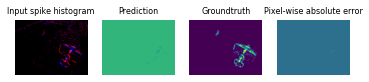

depth, batch 0


<Figure size 432x288 with 0 Axes>

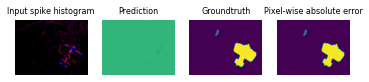

training:   1%|          | 1/116 [00:02<04:31,  2.36s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0538, -0.0455, -0.0426,  ...,  0.0309,  0.0391,  0.0445],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0571, -0.0484, -0.0453,  ...,  0.0328,  0.0415,  0.0473],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5., 6.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4866, 0.4886, 0.4893,  ..., 0.5077, 0.5098, 0.5111], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size

<Figure size 432x288 with 0 Axes>

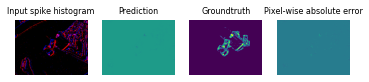

depth, batch 0


<Figure size 432x288 with 0 Axes>

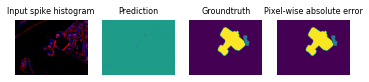

training:   2%|▏         | 2/116 [00:04<03:42,  1.95s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0470, -0.0457, -0.0454,  ...,  0.0317,  0.0319,  0.0371],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0500, -0.0485, -0.0482,  ...,  0.0337,  0.0339,  0.0394],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4882, 0.4886, 0.4887,  ..., 0.5079, 0.5080, 0.5093], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

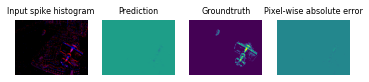

depth, batch 0


<Figure size 432x288 with 0 Axes>

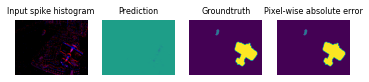

training:   3%|▎         | 3/116 [00:05<03:41,  1.96s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0952, -0.0894, -0.0798,  ...,  0.0560,  0.0584,  0.0666],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.1011, -0.0950, -0.0847,  ...,  0.0595,  0.0620,  0.0708],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4762, 0.4777, 0.4801,  ..., 0.5140, 0.5146, 0.5167], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

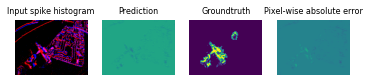

depth, batch 0


<Figure size 432x288 with 0 Axes>

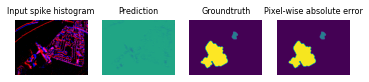

training:   3%|▎         | 4/116 [00:07<03:26,  1.85s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0773, -0.0658, -0.0622,  ...,  0.0392,  0.0502,  0.0531],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0821, -0.0699, -0.0661,  ...,  0.0417,  0.0533,  0.0564],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4807, 0.4836, 0.4844,  ..., 0.5098, 0.5125, 0.5133], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

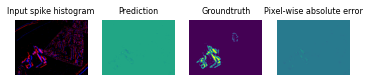

depth, batch 0


<Figure size 432x288 with 0 Axes>

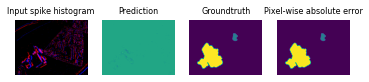

training:   4%|▍         | 5/116 [00:09<03:16,  1.77s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0818, -0.0817, -0.0678,  ...,  0.0523,  0.0526,  0.0589],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0869, -0.0868, -0.0721,  ...,  0.0555,  0.0558,  0.0625],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4796, 0.4796, 0.4831,  ..., 0.5131, 0.5131, 0.5147], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

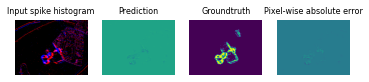

depth, batch 0


<Figure size 432x288 with 0 Axes>

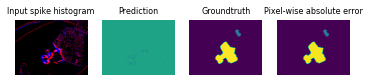

training:   5%|▌         | 6/116 [00:10<03:09,  1.72s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0583, -0.0579, -0.0563,  ...,  0.0467,  0.0473,  0.0526],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0619, -0.0616, -0.0599,  ...,  0.0496,  0.0502,  0.0559],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4854, 0.4855, 0.4859,  ..., 0.5117, 0.5118, 0.5131], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

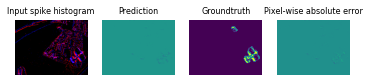

depth, batch 0


<Figure size 432x288 with 0 Axes>

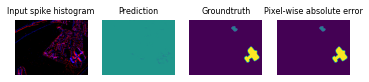

training:   6%|▌         | 7/116 [00:12<03:03,  1.68s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0477, -0.0434, -0.0420,  ...,  0.0376,  0.0391,  0.0422],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0507, -0.0461, -0.0447,  ...,  0.0399,  0.0415,  0.0448],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4881, 0.4892, 0.4895,  ..., 0.5094, 0.5098, 0.5105], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

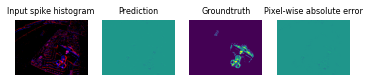

depth, batch 0


<Figure size 432x288 with 0 Axes>

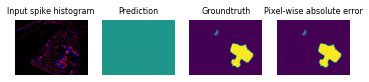

training:   7%|▋         | 8/116 [00:14<02:58,  1.66s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0422, -0.0419, -0.0409,  ...,  0.0425,  0.0457,  0.0459],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0449, -0.0445, -0.0434,  ...,  0.0452,  0.0485,  0.0487],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4894, 0.4895, 0.4898,  ..., 0.5106, 0.5114, 0.5115], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

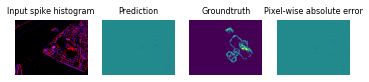

depth, batch 0


<Figure size 432x288 with 0 Axes>

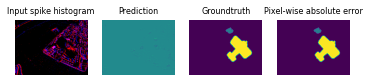

training:   8%|▊         | 9/116 [00:15<02:55,  1.64s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0658, -0.0646, -0.0629,  ...,  0.0650,  0.0679,  0.0859],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0700, -0.0686, -0.0669,  ...,  0.0690,  0.0721,  0.0913],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4835, 0.4839, 0.4843,  ..., 0.5162, 0.5170, 0.5215], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

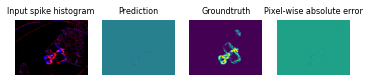

depth, batch 0


<Figure size 432x288 with 0 Axes>

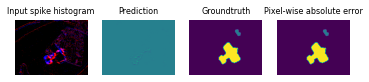

training:   9%|▊         | 10/116 [00:17<03:03,  1.73s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0551, -0.0478, -0.0439,  ...,  0.0539,  0.0542,  0.0592],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0585, -0.0508, -0.0467,  ...,  0.0573,  0.0576,  0.0629],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([ 0.,  1.,  2.,  3.,  4.,  5., 20.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4862, 0.4881, 0.4890,  ..., 0.5135, 0.5135, 0.5148], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  tor

<Figure size 432x288 with 0 Axes>

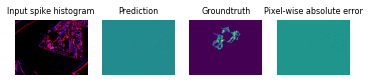

depth, batch 0


<Figure size 432x288 with 0 Axes>

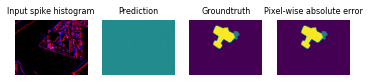

training:   9%|▉         | 11/116 [00:19<03:00,  1.72s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0478, -0.0396, -0.0389,  ...,  0.0419,  0.0495,  0.0526],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0508, -0.0421, -0.0414,  ...,  0.0445,  0.0526,  0.0559],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5., 6.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4881, 0.4901, 0.4903,  ..., 0.5105, 0.5124, 0.5131], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size

<Figure size 432x288 with 0 Axes>

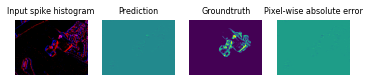

depth, batch 0


<Figure size 432x288 with 0 Axes>

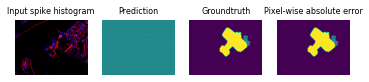

training:  10%|█         | 12/116 [00:20<02:55,  1.69s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0578, -0.0402, -0.0394,  ...,  0.0531,  0.0559,  0.0678],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0614, -0.0427, -0.0418,  ...,  0.0565,  0.0594,  0.0721],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4856, 0.4900, 0.4902,  ..., 0.5133, 0.5140, 0.5170], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

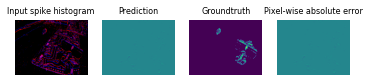

depth, batch 0


<Figure size 432x288 with 0 Axes>

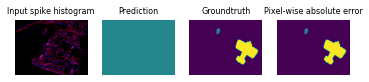

training:  11%|█         | 13/116 [00:22<02:52,  1.67s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0656, -0.0590, -0.0580,  ...,  0.0858,  0.0861,  0.1081],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0697, -0.0627, -0.0616,  ...,  0.0912,  0.0915,  0.1149],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4836, 0.4853, 0.4855,  ..., 0.5214, 0.5215, 0.5270], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

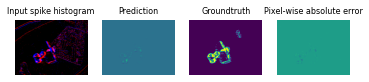

depth, batch 0


<Figure size 432x288 with 0 Axes>

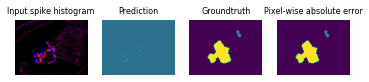

training:  12%|█▏        | 14/116 [00:24<02:48,  1.66s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0452, -0.0450, -0.0382,  ...,  0.0384,  0.0385,  0.0401],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0480, -0.0478, -0.0406,  ...,  0.0408,  0.0409,  0.0426],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4887, 0.4887, 0.4905,  ..., 0.5096, 0.5096, 0.5100], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

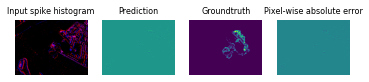

depth, batch 0


<Figure size 432x288 with 0 Axes>

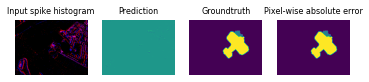

training:  13%|█▎        | 15/116 [00:25<02:45,  1.64s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0482, -0.0481, -0.0480,  ...,  0.0781,  0.0802,  0.0844],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0512, -0.0511, -0.0510,  ...,  0.0830,  0.0852,  0.0897],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([ 0.,  1.,  2.,  3.,  4.,  5., 20.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4880, 0.4880, 0.4880,  ..., 0.5195, 0.5200, 0.5211], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  tor

<Figure size 432x288 with 0 Axes>

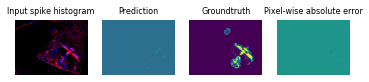

depth, batch 0


<Figure size 432x288 with 0 Axes>

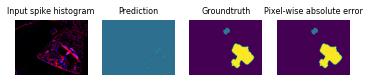

training:  14%|█▍        | 16/116 [00:27<02:44,  1.64s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0445, -0.0358, -0.0333,  ...,  0.0478,  0.0478,  0.0493],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0473, -0.0380, -0.0354,  ...,  0.0508,  0.0508,  0.0524],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4889, 0.4911, 0.4917,  ..., 0.5120, 0.5120, 0.5123], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

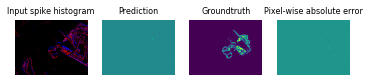

depth, batch 0


<Figure size 432x288 with 0 Axes>

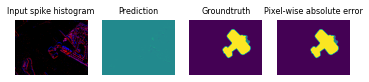

training:  15%|█▍        | 17/116 [00:29<02:48,  1.70s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0411, -0.0393, -0.0364,  ...,  0.0556,  0.0579,  0.0653],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0437, -0.0418, -0.0386,  ...,  0.0591,  0.0616,  0.0693],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5., 6.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4897, 0.4902, 0.4909,  ..., 0.5139, 0.5145, 0.5163], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size

<Figure size 432x288 with 0 Axes>

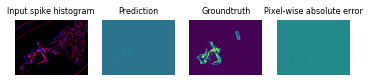

depth, batch 0


<Figure size 432x288 with 0 Axes>

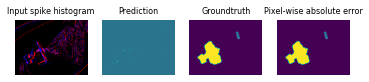

training:  16%|█▌        | 18/116 [00:31<02:47,  1.71s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0491, -0.0460, -0.0456,  ...,  0.0933,  0.1021,  0.1399],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0522, -0.0489, -0.0484,  ...,  0.0991,  0.1085,  0.1486],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4877, 0.4885, 0.4886,  ..., 0.5233, 0.5255, 0.5349], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

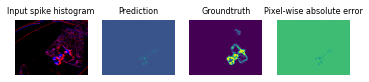

depth, batch 0


<Figure size 432x288 with 0 Axes>

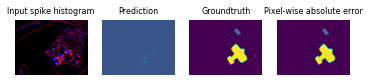

training:  16%|█▋        | 19/116 [00:32<02:45,  1.71s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0454, -0.0447, -0.0406,  ...,  0.0706,  0.0802,  0.0887],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0482, -0.0475, -0.0431,  ...,  0.0750,  0.0852,  0.0943],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4887, 0.4888, 0.4899,  ..., 0.5176, 0.5200, 0.5222], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

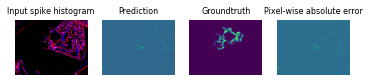

depth, batch 0


<Figure size 432x288 with 0 Axes>

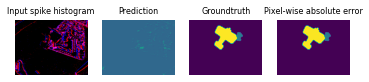

training:  17%|█▋        | 20/116 [00:34<02:41,  1.68s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0408, -0.0353, -0.0329,  ...,  0.0470,  0.0482,  0.0540],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0434, -0.0376, -0.0349,  ...,  0.0499,  0.0512,  0.0574],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4898, 0.4912, 0.4918,  ..., 0.5117, 0.5120, 0.5135], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

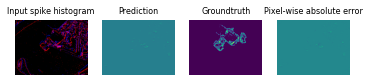

depth, batch 0


<Figure size 432x288 with 0 Axes>

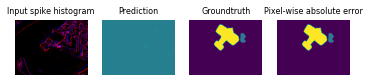

training:  18%|█▊        | 21/116 [00:36<02:38,  1.67s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0496, -0.0413, -0.0403,  ...,  0.0627,  0.0726,  0.0746],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0528, -0.0438, -0.0429,  ...,  0.0666,  0.0771,  0.0792],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4876, 0.4897, 0.4899,  ..., 0.5157, 0.5181, 0.5186], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

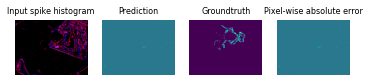

depth, batch 0


<Figure size 432x288 with 0 Axes>

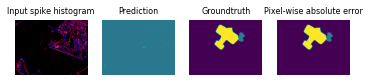

training:  19%|█▉        | 22/116 [00:37<02:35,  1.66s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0582, -0.0563, -0.0528,  ...,  0.1693,  0.1835,  0.1911],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0619, -0.0598, -0.0561,  ...,  0.1884,  0.2004,  0.2033],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4854, 0.4859, 0.4868,  ..., 0.5422, 0.5458, 0.5476], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

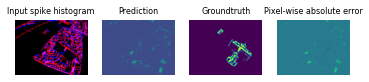

depth, batch 0


<Figure size 432x288 with 0 Axes>

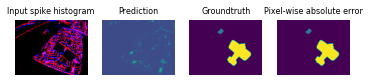

training:  20%|█▉        | 23/116 [00:39<02:32,  1.64s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0406, -0.0363, -0.0348,  ...,  0.0776,  0.0782,  0.0859],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0431, -0.0386, -0.0370,  ...,  0.0825,  0.0831,  0.0912],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4899, 0.4909, 0.4913,  ..., 0.5194, 0.5195, 0.5214], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

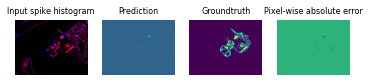

depth, batch 0


<Figure size 432x288 with 0 Axes>

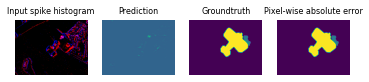

training:  21%|██        | 24/116 [00:41<02:37,  1.72s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0298, -0.0284, -0.0284,  ...,  0.0427,  0.0438,  0.0475],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0317, -0.0302, -0.0302,  ...,  0.0454,  0.0465,  0.0505],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4925, 0.4929, 0.4929,  ..., 0.5107, 0.5109, 0.5119], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

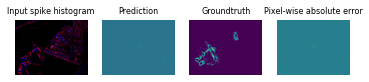

depth, batch 0


<Figure size 432x288 with 0 Axes>

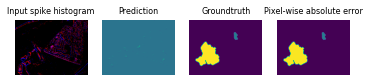

training:  22%|██▏       | 25/116 [00:42<02:33,  1.69s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0487, -0.0481, -0.0479,  ...,  0.0604,  0.0623,  0.0660],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0518, -0.0512, -0.0509,  ...,  0.0642,  0.0662,  0.0701],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4878, 0.4880, 0.4880,  ..., 0.5151, 0.5156, 0.5165], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

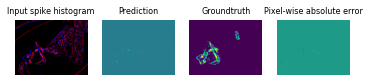

depth, batch 0


<Figure size 432x288 with 0 Axes>

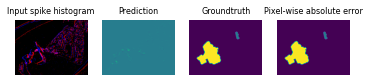

training:  22%|██▏       | 26/116 [00:44<02:33,  1.71s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0487, -0.0342, -0.0290,  ...,  0.0490,  0.0557,  0.0578],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0518, -0.0364, -0.0308,  ...,  0.0521,  0.0592,  0.0614],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4878, 0.4914, 0.4928,  ..., 0.5123, 0.5139, 0.5145], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

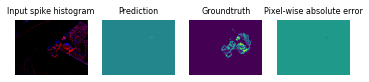

depth, batch 0


<Figure size 432x288 with 0 Axes>

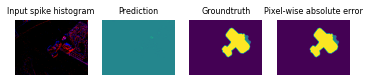

training:  23%|██▎       | 27/116 [00:46<02:30,  1.70s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0461, -0.0450, -0.0443,  ...,  0.1399,  0.1562,  0.1873],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0490, -0.0479, -0.0470,  ...,  0.1487,  0.1660,  0.1990],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4885, 0.4887, 0.4889,  ..., 0.5349, 0.5390, 0.5467], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

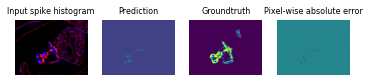

depth, batch 0


<Figure size 432x288 with 0 Axes>

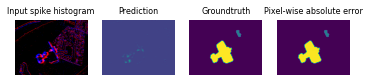

training:  24%|██▍       | 28/116 [00:47<02:28,  1.69s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0544, -0.0368, -0.0363,  ...,  0.0386,  0.0439,  0.0505],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0578, -0.0391, -0.0385,  ...,  0.0410,  0.0467,  0.0536],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4864, 0.4908, 0.4909,  ..., 0.5096, 0.5110, 0.5126], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 

<Figure size 432x288 with 0 Axes>

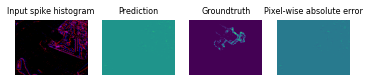

depth, batch 0


<Figure size 432x288 with 0 Axes>

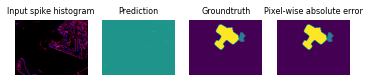

training:  25%|██▌       | 29/116 [00:49<02:25,  1.68s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0457, -0.0326, -0.0294,  ...,  0.0470,  0.0477,  0.0486],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0485, -0.0347, -0.0313,  ...,  0.0499,  0.0506,  0.0516],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([0., 1., 2., 3., 4., 5.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4886, 0.4918, 0.4926,  ..., 0.5117, 0.5119, 0.5121], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  torch.Size([1,

<Figure size 432x288 with 0 Axes>

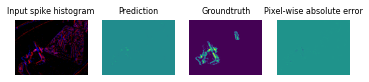

depth, batch 0


<Figure size 432x288 with 0 Axes>

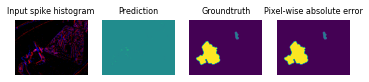

training:  26%|██▌       | 30/116 [00:51<02:23,  1.66s/it]


spike_input numbers to net:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
seg_pred numbers from net:  tensor([-0.0555, -0.0530, -0.0521,  ...,  0.0878,  0.0886,  0.1034],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
depth_pred numbers from net:  tensor([-0.0589, -0.0563, -0.0554,  ...,  0.0933,  0.0941,  0.1099],
       device='cuda:0', grad_fn=<Unique2Backward0>)  of size:  torch.Size([1, 1, 260, 346])
seg_mask numbers from db:  tensor([0., 1.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
depth_mask numbers from db:  tensor([0., 3., 7.], device='cuda:0')  of size:  torch.Size([1, 2, 21, 260, 346])
spike_input 5d numbers to viz:  tensor([ 0.,  1.,  2.,  3.,  4.,  5., 20.], device='cuda:0')  of size:  torch.Size([1, 1, 2, 260, 346])
seg_pred numbers to loss/viz:  tensor([0.4861, 0.4868, 0.4870,  ..., 0.5219, 0.5221, 0.5258], device='cuda:0',
       grad_fn=<Unique2Backward0>)  of size:  tor

training:  26%|██▌       | 30/116 [00:51<02:28,  1.73s/it]


KeyboardInterrupt: ignored

<Figure size 432x288 with 0 Axes>

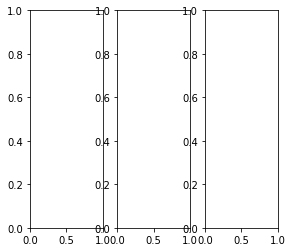

In [ ]:
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

functional.reset_net(net)

for epoch in range(n_epochs):

    show=True
    net = net.train()               #<--------   0
    running_train_loss = 0
    running_train_IOU = 0
    start_time = time.time()
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if (data == None):
                continue
            functional.reset_net(net)                               #<--------  6
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            spikes_input = spikes_input.permute(0,1,4,2,3)

            seg_masked = data['masked_spike_tensor']
            seg_masked = seg_masked.permute(0,1,4,2,3)

            depth_masked = data['depth_mask_tensor']
            depth_masked = depth_masked.permute(0,1,4,2,3)

            if not MultiStep:                                   #   sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                seg_masked = torch.sum(seg_masked,axis=0,keepdim=True)
                depth_masked = torch.sum(depth_masked,axis=0,keepdim=True)

            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            seg_masked = seg_masked.to(device)
            depth_masked = depth_masked.to(device)

            seg_pred_list,depth_pred_list =  net(spikes_input)                #<--------   2  # len(spike_pred_list) = 4
            # seg_pred_list = net(spikes_input)
            seg_pred =  seg_pred_list[3].to(device)
            seg_pred = torch.sigmoid(seg_pred)
            depth_pred =  depth_pred_list[3].to(device)

            if seg_pred.ndim == 4:
                # spike_input_crop = spikes_input[:, :, :, :seg_pred.size(2), :seg_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                seg_masked_crop = seg_masked[:, :, :, :seg_pred.size(2), :seg_pred.size(3)]       #ndim 4  (B,1,1,260,346)
                depth_masked_crop = depth_masked[:, :, :, :depth_pred.size(2), :depth_pred.size(3)]
                seg_pred_4D = torch.sum(seg_pred, axis = (1),keepdim=True) #
                depth_pred_4D = torch.sum(depth_pred, axis = (1),keepdim=True) #

                # spike_input_crop = spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]
                # seg_input_crop = seg_input[:, :, :, :seg_pred.size(2), :seg_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                # seg_masked_crop = seg_masked[:, :, :, :seg_pred.size(2), :seg_pred.size(3)]       #ndim 4  (B,1,1,260,346)
                # seg_pred_4D = torch.sum(seg_pred, axis = (1),keepdim=True) #

                # depth_input_crop = depth_input[:, :, :, :depth_pred.size(2), :depth_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                # depth_masked_crop = depth_masked[:, :, :, :depth_pred.size(2), :depth_pred.size(3)]       #ndim 4  (B,1,1,260,346)
                # depth_pred_4D = torch.sum(depth_pred, axis = (1),keepdim=True) #

            elif seg_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (2))               #torch.Size([B, 1, 260, 346])
                spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop =spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

            seg_mask_4D = torch.any(seg_masked_crop, dim = 2,keepdim=False) #or and remove of TS dim
            seg_mask_4D = torch.any(seg_mask_4D, dim = 1,keepdim=True)      #or of C dim
            seg_mask_4D = torch.mul(seg_mask_4D,1.)          #conversion to

            depth_mask_4D = torch.mean(depth_masked_crop, dim = 2,keepdim=False) #or and remove of TS dim
            depth_mask_4D = torch.mean(depth_mask_4D, dim = 1,keepdim=True)      #or of C dim
            #depth_mask_4D = torch.mul(depth_mask_4D,1.)          #conversion to

            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.gt(spike_mask_4D, 1)

            if show:
                    #condition to colapse all timesteps in every batch
                spikes_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)
                spikes_input_5D = spikes_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)

                print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())

                print("seg_pred numbers from net: ",torch.unique(seg_pred_list[3])," of size: ",seg_pred_list[3].size())
                print("depth_pred numbers from net: ",torch.unique(depth_pred_list[3])," of size: ",depth_pred_list[3].size())

                print("seg_mask numbers from db: ",torch.unique(seg_masked)," of size: ",seg_masked.size())
                print("depth_mask numbers from db: ",torch.unique(depth_masked)," of size: ",depth_masked.size())


                print("spike_input 5d numbers to viz: ",torch.unique(spikes_input_5D)," of size: ",spikes_input_5D.size())

                print("seg_pred numbers to loss/viz: ",torch.unique(seg_pred_4D)," of size: ",seg_pred_4D.size())
                print("seg_mask numbers to loss/viz: ",torch.unique(seg_mask_4D)," of size: ",seg_mask_4D.size())

                print("depth_pred numbers to loss/viz: ",torch.unique(depth_pred_4D)," of size: ",depth_pred_4D.size())
                print("depth_mask numbers to loss/viz: ",torch.unique(depth_mask_4D)," of size: ",depth_mask_4D.size())
                for e in range(spikes_input_5D.size(0)):
                    show_learning(fig,False,
                                  spikes_input_5D[None,e,:,:,:,:],
                                  seg_pred_4D[None,e,:,:,:],
                                  seg_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                for e in range(spikes_input_5D.size(0)):
                    show_learning(fig,False,
                                  spikes_input_5D[None,e,:,:,:,:],
                                  depth_pred_4D[None,e,:,:,:],
                                  depth_mask_4D[None,e,:,:,:], 'depth, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],      [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            # loss = loss_module(seg_pred_4D, seg_mask_4D,depth_pred_4D, depth_mask_4D)        #<--------  3
            loss = loss_module(seg_pred_4D, seg_mask_4D)
            loss.backward()                                         #<--------  4
            optimizer.step()                                        #<--------  5

            optimizer.zero_grad()                               #<--------   1
            running_train_loss += loss.item() / spikes_input.size(0)
            seg_pred = torch.round(seg_pred)
            running_train_IOU += getIOU(seg_pred,seg_mask_4D)

                # process saved metrics
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_IOU = running_train_IOU / len(train_loader)
        train_loss_vec.append(float(epoch_train_loss))
        train_error_vec.append(float(epoch_train_IOU))
        epoch_train_time = time.time() - start_time
        train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)

        # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################
    running_test_loss = 0
    running_test_IOU = 0
    net.eval()
    show=True

    with torch.no_grad():
        start_time = time.time()
        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            functional.reset_net(net)
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)
            if not MultiStep:   #sums all time steps in the dim=0
                spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()

            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[3].to(device)             # (1,1,260,346)
            spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346])
                spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
            spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

            if show:
                #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print("spike_pred numbers from net: ",torch.unique(spike_pred_list[3])," of size: ",spike_pred_list[3].size())
                print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_input_5D.size(0)):
                    show_learning(fig,False,
                                    spike_input_5D[None,e,:,:,:,:],
                                    spike_pred_4D[None,e,:,:,:],
                                    spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = loss_module(spike_pred_4D, spike_mask_4D)

            running_test_loss += loss / spikes_input.size(0)
            spike_pred = torch.round(spike_pred)
            running_test_IOU += getIOU(spike_pred, spike_mask_4D)

                # process saved metrics
        epoch_test_loss = running_test_loss / len(test_loader)
        epoch_test_IOU = running_test_IOU / len(test_loader)
        test_loss_vec.append(float(epoch_test_loss))
        test_error_vec.append(float(epoch_test_IOU))
        epoch_test_time = time.time() - start_time
        test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
        print(train_epoch_summary + test_epoch_summary)
        logfile.write(train_epoch_summary + test_epoch_summary)

        # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)

        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec
                        }, "./results/checkpoints/stereospike_seg_sergio3.pth")

        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.title("Loss")
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.title("IoU (%)")
        plt.show()
print("training finished !")

# test

In [ ]:
from torch._C import dtype
from spikingjelly.clock_driven import neuron, layer, surrogate
from torch._C import dtype
MultiStep=True
from viz import show_learning
show = True           # display network's predictions during training / validation

############
# Test #
############
running_test_loss = 0
running_test_IOU = 0
net.eval()
show=True

with torch.no_grad():
    start_time = time.time()
    for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
        if (data == None):
            continue
        functional.reset_net(net)
        optimizer.zero_grad()
        spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
        spikes_masked = data['masked_spike_tensor']
        spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
        spikes_masked = spikes_masked.permute(0,1,4,2,3)
        if not MultiStep:   #sums all time steps in the dim=0
            spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
        spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
        spikes_masked = spikes_masked.to(device)
        spikes_input.requires_grad_()

        spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
        #spike_pred_list = functional.multi_step_forward(spikes_input, net)
        spike_pred =  spike_pred_list[2].to(device)             # (1,1,260,346)
        spike_pred = torch.sigmoid(spike_pred)
        # print("output net: ",spike_pred_list[3].size())
        print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
        if spike_pred.ndim == 4:
            spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
            spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
            #spike_pred_4D = spike_pred
            spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

        elif spike_pred.ndim == 5:
            spike_pred_4D = torch.sum(spike_pred, axis = (2))           #torch.Size([B, 1, 260, 346])
            spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
            spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

        spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
        spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

        if show:
            if MultiStep:       #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
            for e in range(spike_input_5D.size(0)):
                show_learning(fig,False,
                                spike_input_5D[None,e,:,:,:,:],
                                spike_pred_4D[None,e,:,:,:],
                                spike_mask_4D[None,e,:,:,:], 'segm, batch '+str(e),i)  #plt.fig,Save,[B,1,2,260,346],  [B, 1, 260, 346], [B, 1, 260, 346], text,       i
            #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)
        loss = loss_module(spike_pred_4D, spike_mask_4D)

        running_test_loss += loss / spikes_input.size(0)
        running_test_IOU += getIOU(spike_pred, spike_mask_4D)

            # process saved metrics
    epoch_test_loss = running_test_loss / len(test_loader)
    epoch_test_IOU = running_test_IOU / len(test_loader)
    test_loss_vec.append(float(epoch_test_loss))
    test_error_vec.append(float(epoch_test_IOU))
    epoch_test_time = time.time() - start_time
    test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
    print( test_epoch_summary)

    tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
    tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)


    scheduler.step()

    x=[x for x in range(len(train_loss_vec))]
    y=[y for y in range(len(test_loss_vec))]
    plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
    plt.title("Loss")
    plt.show()

    x=[x for x in range(len(train_error_vec))]
    y=[y for y in range(len(test_error_vec))]
    plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
    plt.title("IoU")
    plt.show()
print("training finished !")


testing:   0%|          | 0/2994 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
testing:   1%|          | 22/2994 [00:40<1:30:44,  1.83s/it]


IndexError: list index out of range

In [ ]:
%cd /content/drive/MyDrive/StereoSpikeA/OF_EV_SNN
!ls
!python /content/drive/MyDrive/StereoSpikeA/OF_EV_SNN/network_3d/poolingNet_cat_1res.py

# generate MVSEC dataset video

In [ ]:
dir=str('/content/drive/MyDrive/StereoSpike/results/visualizations2/')
make_vid_from_pngs(dir, (2160,1440), 20, 'results/preds3_19_03_2024.mp4') #1700,403

In [ ]:
!python train_evimo.py

In [ ]:
!python /content/drive/MyDrive/StereoSpike/datasets/MVSEC/utils.py

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from datasets.MVSEC.utils import mvsecToVideo, mvsecSpikesAndDepth, mvsecShowBlended, mvsecLoadRectificationMaps, mvsecRectifyEvents, mvsecCumulateSpikesIntoFrames, mvsecSpikesAndDepth
# load dataset files
root = '/content/drive/MyDrive/StereoSpike/datasets/MVSEC/data/'
# datafile = root + 'indoor_flying/indoor_flying4_data'
datafile = root + 'outdoor_day/outdoor_day1_data'
data = h5py.File(datafile + '.hdf5', 'r')
# datafile_gt = root + 'indoor_flying/indoor_flying4_gt'
datafile_gt = root + 'outdoor_day/outdoor_day1_gt'
data_gt = h5py.File(datafile_gt + '.hdf5', 'r')

# raw grayscale images
images = data['davis']['left']['image_raw']
#mvsecToVideo(images)

# depth maps
Ldepths_rect = data_gt['davis']['left']['depth_image_rect']  # RECTIFIED / LEFT
Rdepths_rect = data_gt['davis']['right']['depth_image_rect']  # RECTIFIED / RIGHT
Ldepths_raw = data_gt['davis']['left']['depth_image_raw']  # RAW / LEFT
Rdepths_raw = data_gt['davis']['right']['depth_image_raw']  # RAW / RIGHT
Ldepths_rect_ts = np.array(data_gt['davis']['left']['depth_image_rect_ts'])
Rdepths_rect_ts = np.array(data_gt['davis']['right']['depth_image_rect_ts'])

# blended: Visualization of all events from the left DAVIS that are 25ms from each left depth map superimposed on
# the depth map. Gives a preview of what each sequence looks like. Provided by the authors of the dataset.
Lblended = data_gt['davis']['left']['blended_image_rect']
Rblended = data_gt['davis']['right']['blended_image_rect']

# get the events
Levents = np.array(data['davis']['left']['events'])  # EVENTS: X Y TIME POLARITY
Revents = np.array(data['davis']['right']['events'])  # EVENTS: X Y TIME POLARITY

# rectify the coordinates of spike events
# calib_root = root + 'indoor_flying/indoor_flying_calib/indoor_flying_'
calib_root = root + 'outdoor_day/outdoor_day_calib/outdoor_day_'
Lx_path = root + calib_root + 'left_x_map.txt'
Ly_path = root + calib_root + 'left_y_map.txt'
Rx_path = root + calib_root + 'right_x_map.txt'
Ry_path = root + calib_root + 'right_y_map.txt'
Lx_map, Ly_map, Rx_map, Ry_map = mvsecLoadRectificationMaps(Lx_path, Ly_path, Rx_path, Ry_path)
rect_Levents = mvsecRectifyEvents(Levents, Lx_map, Ly_map)
rect_Revents = mvsecRectifyEvents(Revents, Rx_map, Ry_map)

# show data in a video file (cumulated spikes between frames)
#mvsecToVideo(images)
AER_frames, sync_labels = mvsecCumulateSpikesIntoFrames(rect_Levents, Ldepths_rect, Ldepths_rect_ts, 2)
mvsecSpikesAndDepth(Ldepths_rect, rect_Levents, Lblended)
mvsecShowBlended(Lblended, Rblended)
mvsecShowDepth(Ldepths_rect, Rdepths_rect, Ldepths_raw, Rdepths_raw, Rblended, Lblended)


In [ ]:
#!pip install spikingjelly==0.0.0.0.12
%cd /content/drive/MyDrive
!git clone https://github.com/fangwei123456/spikingjelly.git
%cd /content/drive/MyDrive/spikingjelly
!git checkout 0.0.0.0.12
!python setup.py install
#!ls


In [ ]:
import torch
from spikingjelly.activation_based import neuron
from spikingjelly import visualizing
from matplotlib import pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 200
if_node = neuron.IFNode(v_reset=None)
T = 128
x = torch.arange(-0.2, 1.2, 0.04)
plt.scatter(torch.arange(x.shape[0]), x)
plt.title('Input $x_{i}$ to IF neurons')
plt.xlabel('Neuron index $i$')
plt.ylabel('Input $x_{i}$')
plt.grid(linestyle='-.')
plt.show()

#download & preprocess evimo datasets




In [ ]:
%cd /content/drive/MyDrive/datasets/EVIMO_Dataset/

# download database
# !wget https://obj.umiacs.umd.edu/evimo1npz/train_table_npz.tar.gz
# !wget https://obj.umiacs.umd.edu/evimo1txt/train_table_txt.tar.gz
# !wget https://obj.umiacs.umd.edu/evimo1txt/train_box_txt.tar.gz
!wget https://obj.umiacs.umd.edu/evimo1txt/train_floor_txt.tar.gz
# !wget https://obj.umiacs.umd.edu/evimo1txt/train_wall_txt.tar.gz
# !wget https://obj.umiacs.umd.edu/evimo1txt/train_box_txt.tar.gz
# !wget https://obj.umiacs.umd.edu/evimo1txt/train_box_txt.tar.gz

# extract database
# !tar -xvf /content/drive/MyDrive/datasets/EVIMO_Dataset/train_box_txt.tar.gz
!tar -xvf /content/drive/MyDrive/datasets/EVIMO_Dataset/train_floor_txt.tar.gz
# !tar -xvf /content/drive/MyDrive/datasets/EVIMO_Dataset/train_wall_txt.tar.gz
# !tar -xvf /content/drive/MyDrive/datasets/EVIMO_Dataset/eval_table_npz.tar.gz
# !tar -xvf /content/drive/MyDrive/datasets/EVIMO_Dataset/train_table_npz.tar.gz

# !tar -xvf /content/drive/MyDrive/datasets/EVIMO_Dataset/train_table_txt.tar.gz
%cd /content/drive/MyDrive/StereoSpikeA



Streaming output truncated to the last 5000 lines.
train/floor/txt/seq_02/img/depth_mask_1207.png
train/floor/txt/seq_02/img/depth_mask_1208.png
train/floor/txt/seq_02/img/depth_mask_1209.png
train/floor/txt/seq_02/img/depth_mask_121.png
train/floor/txt/seq_02/img/depth_mask_1210.png
train/floor/txt/seq_02/img/depth_mask_1211.png
train/floor/txt/seq_02/img/depth_mask_1212.png
train/floor/txt/seq_02/img/depth_mask_1213.png
train/floor/txt/seq_02/img/depth_mask_1214.png
train/floor/txt/seq_02/img/depth_mask_1216.png
train/floor/txt/seq_02/img/depth_mask_1217.png
train/floor/txt/seq_02/img/depth_mask_1218.png
train/floor/txt/seq_02/img/depth_mask_1219.png
train/floor/txt/seq_02/img/depth_mask_122.png
train/floor/txt/seq_02/img/depth_mask_1220.png
train/floor/txt/seq_02/img/depth_mask_1221.png
train/floor/txt/seq_02/img/depth_mask_1222.png
train/floor/txt/seq_02/img/depth_mask_1223.png
train/floor/txt/seq_02/img/depth_mask_1224.png
train/floor/txt/seq_02/img/depth_mask_1225.png
train/floor

In [ ]:
# %cd /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt
# %cd /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt
# %cd /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/floor/txt
# %cd /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/tabletop/txt
%cd /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt
# %cd /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/train/floor/txt

# !python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000 -f /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_02 # -f /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/train/floor/txt/seq_00
# !python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000 -f /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_03
# !python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000 -f /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_06
# !python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000 -f /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_08
# !python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000 -f /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_09
!python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000 -f /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_10
!python /content/drive/MyDrive/SpikeMS/preprocessingHelpers/evimo2hdf5-v3.py -w 0.01 -m 1000 -f /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_11

/content/drive/.shortcut-targets-by-id/1zZI3ByBJSx_iMFiA-nDfsiLUtVpFhZfX/EVIMO_Dataset/train/box/txt
Starting folder /content/drive/MyDrive/datasets/EVIMO_Dataset/train/box/txt/seq_10
  0% 153408/117331432 [00:00<01:16, 1534001.00it/s]update frame 1 0.164838
update frame 2 0.199847
update frame 3 0.229882
update frame 4 0.264815
  0% 306809/117331432 [00:02<15:10, 128577.14it/s] update frame 5 0.294873
update frame 6 0.329876
  0% 374582/117331432 [00:03<18:54, 103056.42it/s]update frame 7 0.364773
  0% 414475/117331432 [00:03<20:07, 96855.74it/s] update frame 8 0.394848
  0% 441643/117331432 [00:04<22:20, 87168.69it/s]update frame 9 0.42984
  0% 493899/117331432 [00:04<22:27, 86690.05it/s]update frame 10 0.459784
  0% 553390/117331432 [00:05<20:50, 93400.20it/s]update frame 11 0.48983
  1% 601906/117331432 [00:05<21:05, 92223.70it/s]update frame 12 0.524851
  1% 659331/117331432 [00:06<20:23, 95345.45it/s]update frame 13 0.554844
  1% 715520/117331432 [00:06<20:26, 95089.70it/s]update

In [ ]:
from numpy import load

data = load('eval/table/npz/seq_02.npz')
lst = data.files
for item in lst:
    print(item)
    print(data[item].shape)
    # print(data[item])

events
(3230803, 4)
index
(401,)
discretization
()
K
(3, 3)
D
(4,)
depth
(129, 260, 346)
mask
(129, 260, 346)
meta


ValueError: ignored

In [ ]:
!cd  /content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data
!unzip /content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/outdoor_night_calib.zip

Archive:  /content/drive/MyDrive/StereoSpikeA/datasets/MVSEC/data/outdoor_night_calib.zip
replace camchain-imucam-outdoor_night.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace outdoor_night_left_x_map.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace outdoor_night_left_y_map.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace outdoor_night_right_x_map.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace outdoor_night_right_y_map.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 
error:  invalid response [{ENTER}]
replace outdoor_night_right_y_map.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


# Segmentación Sergi

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
import sys
import locale
import os
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding
sys.path.append('/content/drive/MyDrive')
%cd /content/drive/MyDrive/StereoSpike
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
!pip3 install -r requirements.txt

Mounted at /content/drive/
/content/drive/MyDrive/StereoSpike
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 kB 16.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.7/800.7 kB 46.0 MB/s eta 0:00:00
  Created wheel for loris: filename=loris-0.5.3-cp310-cp310-linux_x86_64.whl size=612397 sha256=7a27cc04d2a65219e8258596180fcd582fb3768d5439609a499787dfeaf683bb
  Stored in directory: /root/.cache/pip/wheels/20/a8/32/daab9b19824ce87c93fb0b5cac79905eabc5fa0f72b1aa1bc7
Successfully built loris


In [ ]:
!pwd

/content/drive/MyDrive/StereoSpike


## Libraries importing

In [ ]:
import time
import random
from tqdm import tqdm
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
#import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "0"
import torch
import torch.nn as nn
#import torch.nn.functional as F
from torchvision import transforms
# from torch.utils.tensorboard import SummaryWriter

from spikingjelly.activation_based import functional
from spikingjelly.activation_based import surrogate
# from spikingjelly.event_driven import neuron
from datasets.data_augmentation import ToTensor_mono,ToTensor_ms, RandomHorizontalFlip_ms, RandomVerticalFlip_ms, RandomTimeMirror, RandomEventDrop_ms
#from network.SNN_models2 import unetRNN6Layer_noBlock
from network.SNN_models import StereoSpike, \
                    fromZero_feedforward_multiscale_tempo_Matt_SpikeFlowNetLike, \
                    fromZero_feedforward_multiscale_tempo_monocular_SpikeFlowNetLike, \
                    fromZero_feedforward_multiscale_tempo_monocular_Motion, \
                    fromZero_feedforward_multiscale_tempo_monocular_Motion2, \
                    unetMotion#, Unet
# from network.SNN_models2 import unetMotion3, unetMotion4
from OF_EV_SNN.network_3d.poolingNet_cat_1res import NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d, \
                    PLIFNeuronPool_Separable_Pool3d_2, \
                    NeuronPool_Separable_Pool3d, \
                    NeuronPool_Separable_Pool3d_2, \
                    PLIFNeuronPool_Separable_Pool3d_ts, \
                    NeuronPool_Separable_Pool3d_3x3, \
                    NeuronPool_Separable_Pool3d_original, \
                    NeuronPool_Separable_Pool3d_depth_segm, \
                    SpikeMS_poolingnet, \
                    poolingnet3d

from network.ANN_models import StereoSpike_equivalentANN
from network.metrics import MeanDepthError, log_to_lin_depths, disparity_to_depth
from network.Params import yamlParams
#from datasets.MVSEC import mvsec_dataset2 as evimo_base
from network.loss2 import Total_Loss, DiceLoss, BCEDiceLoss, getIOU, VanRossumLoss, SegmDepthLoss
from datasets.MVSEC.mvsec_dataset import EVIMODatasetBase, EVIMODatasetBaseNPZ, EVIMODatasetBase_serg
#from network.SNN_models2 import unetRNN6Layer_noBlock

from torch.utils.data.dataloader import default_collate
from viz import show_learning, show_loss
from PIL import Image
import os
#from network.loss import getIOU, MSE
#from datasets.MVSEC import load_MVSEC
########################
# COMPLEMENT FUNCTIONS #
########################

def my_collate(batch):
    batch = list(filter (lambda x:x is not None, batch))
    if not batch:
        return None

    return default_collate(batch)
##############################
# DEVICE AND REPRODUCIBILITY #
##############################

device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

# logfile = open("./results/checkpoints/test_results_sergio.txt", "w+")
###########################
# VISUALIZATION FUNCTIONS #
###########################

plt.ion()
fig = plt.figure()

torch.use_deterministic_algorithms(False)

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

## Training Params

In [ ]:
######################
# GENERAL PARAMETERS #
######################
general_config = "/content/drive/MyDrive/StereoSpike/general_config.yaml"
genconfigs = yamlParams(general_config)
imageDir = "images" # Cambiar por una direccion
saveImageInterval = 1

# nfpdm = 50              # number of frames per depth map (1 label every 50 ms)
learned_metric = 'LIN' # learn metric depth ('LIN'), normalized log depth ('LOG') or disparity ('DISP')
learning_rate = 2e-4
weight_decay = 0.0
n_epochs = 300

mode='segm'

rmseloss_module = Total_Loss() #alpha=0.5, scale_weights=(1., 1., 1., 1.), penalize_spikes=False)
#loss_module = DiceLoss()
bcediceloss_module = BCEDiceLoss()

segmdepthloss_module = SegmDepthLoss()
vanrossumloss_module = VanRossumLoss()
#loss_module = DepthBCEDiceLoss()

## Load net class and database params

In [ ]:
########################
## TRAINING FRAMEWORK ##
########################
# Create the network

neuron_type = "lif"

# net = NeuronPool_Separable_Pool3d_depth_segm(multiply_factor = 10.).to(device) #ts 20
# net = NeuronPool_Separable_Pool3d_3x3(multiply_factor = 10.).to(device)
# net = NeuronPool_Separable_Pool3d_original(multiply_factor = 10.,time_window = 21).to(device) #ts 21
# net = SpikeMS_poolingnet(multiply_factor = 10., time_window = 10).to(device)
# net = poolingnet3d(multiply_factor = 2., time_window = 10).to(device)

if neuron_type == "lif":
    net = poolingnet3d_lif(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)
elif neuron_type == "izhikevich":
    net = poolingnet3d_i(multiply_factor = 2., size=(10,260,346), in_channels = 2, encoder_in_channels = 32, out_channels = 2).to(device)

trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print('Trainable parameters: {}'.format(trainable_params))


# Initialize network weights

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)


# Create the optimizer
lr = 5e-4
wd = 1e-3
optimizer = torch.optim.AdamW(net.parameters(), lr = lr, weight_decay = wd)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [10, 20, 40, 80, 160, 320], gamma = 0.5)

USING SPIKING MODEL
Trainable parameters: 1660384


## single database loader

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile_test = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#from datasets.data_augmentation import ToTensor,ToTensor_mono, RandomHorizontalFlip, RandomVerticalFlip, RandomTimeMirror, RandomEventDrop
#from datasets.MVSEC.mvsec_dataset2 import EVIMODatasetBase

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database = EVIMODatasetBase(datafile, genconfigs, maskDir, crop,
                                maxBackgroundRatio, incrementalPercent)
    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

dataset_size = len(database)
    # uncomment if you want to split test/train using single hdf5 file
torch.manual_seed(0)
test_split = genconfigs['model']['testSplit'] # self.genconfigs['model']['testSplit']                      #

test_size = int(test_split * dataset_size)                              #
train_size = dataset_size - test_size                                   #
train_dataset, test_dataset = torch.utils.data.random_split(database,[train_size, test_size])    #

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=test_dataset,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

tb_writer = SummaryWriter('./results/checkpoints/')

In [ ]:
######  complete dataset ########
##################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test =  EVIMODatasetBase(datafile_test,  genconfigs, maskDir_test,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train = EVIMODatasetBase(datafile_train, genconfigs, maskDir_train, crop,
                                maxBackgroundRatio, incrementalPercent)
    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

tb_writer = SummaryWriter('./results/checkpoints/')

## TEST stereospike

In [ ]:
from torch._C import dtype
show = True           # display network's predictions during training / validation

############
# Test #
############
# self._trainfromscratch()    # train from scratch
    # self._loadNetFromCheckpoint(checkpoint, modeltype)
    # checkpoint = torch.load(checkpoint) # Creo que tampoco se puede porque está guardado específicamente con slayerpytorch
    # net.load_state_dict(checkpoint['state_dict']) # Aqui esto no va porque espera que se cargue con convoluciones tipo slayerpytorch
# net.load_state_dict(torch.load('./results/checkpoints/stereospike_seg.pth'))
net = net.eval()

epoch_test_IOU = 0
epoch_test_MSE = 0
total_IOU = 0
epoch_test_time = 0

scalar_i = 0
scalar=0
tot_frames = 0

if saveImages and not os.path.exists(imageDir):
                os.mkdir(imageDir)

#for epoch in range(n_epochs):

start_time = time.time()
running_test_IOU = 0
running_test_MSE = 0
running_test_loss = 0

with torch.no_grad():
    for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> test_loader
        if (data == None):
            scalar +=1
            continue

        # data = moveToGPUDevice(data, device, dtype)

        spikes_input = data['spike_tensor']           #torch.Size([1, 2, 260, 346, 10])
        spikes_masked = data['masked_spike_tensor']
        print("original size: ",spikes_input.size())
        # spikes_input = spikes_input.ToTensor()
        spikes_input = torch.sum(spikes_input, axis=0,keepdim=True)
        spikes_masked = torch.sum(spikes_masked, axis=0,keepdim=True)
        # spikes_input = np.squeeze(spikes_input, axis=0)
        # spikes_masked = np.squeeze(spikes_masked, axis=0)
        # print("Squeeze: ", spikes_input.shape)
        spikes_input = spikes_input.permute(4,0,1,2,3)#torch.Size([10, 1, 2, 260, 346])
        spikes_masked = spikes_masked.permute(4,0,1,2,3)

        spikes_input = torch.sum(spikes_input, axis = (0),keepdim=True)     #condensa la dimension 0 de 10 a 1
        print("tensor size: ",spikes_input.shape)
        spikes_input = spikes_input.to(device)
        spikes_masked = spikes_masked.to(device)


        spike_pred_list, spks =  net(spikes_input)                          # <-------------------------------------
        spike_pred =  spike_pred_list[0].to(device)   #torch.Size([10, 1, 2, 260, 346])

        #model returns output and intermediate layers
        # try:
        #     print("try")
        #     print("try: ", spikes_input.ndim)
        #     spike_pred =  net.forward(spikes_input).to(device)

        # #model returns just the output layer
        # except:
        #     print("except")
        #     if spikes_input.ndim == 5:
        #         spikes_input = torch.sum(spikes_input, axis=0)
        #     print("except: ", spikes_input.ndim)
        #     spike_pred_arr = net.forward(spikes_input)
        #     spike_pred = spike_pred_arr[0].to(device)

        # print("spike_pred_shape: ",spike_pred.shape)
        # print("spike_pred: ",spike_pred.size(3))
        if spike_pred.ndim == 3:
            spike_input_crop = spikes_input[ :, :spike_pred.size(1), :spike_pred.size(2)]
            spikes_masked_crop = spikes_masked[:, :spike_pred.size(1), :spike_pred.size(2)]
        else:
            spike_input_crop = spikes_input[:spike_pred.size(0), :, :spike_pred.size(2), :spike_pred.size(3)]      #torch.Size([10, 1, 2, 260, 346])
            spikes_masked_crop = spikes_masked[:spike_pred.size(0), :, :spike_pred.size(2), :spike_pred.size(3)]      #torch.Size([10, 1, 2, 260, 346])
        # spike_input_crop = spikes_input[:, :, :spike_pred.size(2), :spike_pred.size(3), :spike_pred.size(4)]
        # spikes_masked_crop = spikes_masked[:, :, :spike_pred.size(2), :spike_pred.size(3), :spike_pred.size(4)]
        print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
        spike_pred_2D = torch.sum(spike_pred, axis = (0,1))                     #torch.Size([2, 260, 346])
        spike_pred_2D_2 = torch.sum(spike_pred, axis = (0,1),keepdim=True)      #torch.Size([1, 1, 2, 260, 346])


        #spike_mask_2D = torch.sum(spikes_masked_crop, axis = (0,1))
        spike_mask_2D = torch.sum(spikes_masked_crop, axis = (0,1,2))   #output: torch.Size([260, 346])
        spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #output: torch.Size([10, 1, 260, 346])
        spike_mask_2D = spike_mask_2D.to(device)
        # print("shape spike_pred: ", spike_pred.ndim)
        # print("shape spikes_masked_crop: ", spikes_masked_crop.ndim)
        # print("shape spikes_masked_crop: ", spikes_masked_crop.shape)

        #calculate the loss and update the weights
        # print("shape spike_pred_2d: ", spike_pred_2D.ndim)
        # print("shape spike_mask_2D: ", spike_mask_2D.ndim)
        # print("shape spike_pred_2d: ", spike_pred_2D.shape)

        if show:
            spike_mask_viz = torch.sum(spikes_masked_crop, axis = (0))          # output: torch.Size([1, 2, 260, 346])
            spike_mask_viz = torch.sum(spike_mask_viz, axis = (1),keepdim=True) # output : torch.Size([1, 1, 260, 346])
            show_learning(fig, False, spikes_input, spike_pred_2D_2, spike_mask_viz, 'segmentacion',i)    #plt.fig, [1, 2, 260, 346, 1], [1, 1, 260, 346], [1, 1, 260, 346], text,i

    #   loss = loss_module(spike_pred,  spike_mask_viz, spks)
    #   net.detach()
        #total_loss = loss_module(spike_pred_2D, spike_mask_2D)

        #calculate metrics
        loss = loss_module(spike_pred,spike_mask_4D) #gt = 1,1,260,346, pred = list of 5 tensor

        # iou = loss_module.getIOU(spike_pred,spike_mask_4D)#spike_pred_2D, spike_mask_2D)
        # mse = loss_module.MSE(spike_pred,spike_mask_4D)#spike_pred_2D, spike_mask_2D)

        # total_IOU += iou*len(data['ratio'])
        # total_MSE += mse*len(data['ratio'])

        #print(i, ": ", "curr iou ", iou, "curr mse ",mse, "ratio ", data['ratio'])
        #self.tb_writer.add_scalar('iou', iou.item(), scalar_i)

        scalar_i += 1
        tot_frames += len(data['ratio'])

        #running_test_loss += loss / spikes_input.size(0)
        #running_test_IOU += iou

        running_test_loss += loss.item() / spikes_input.size(0)
        #running_test_MSE += mse

        scalar_i +=1
        #print("total_loss: ", running_test_loss)
    ############
            # process saved metrics
    epoch_test_loss = running_test_loss / len(test_loader)
    #epoch_test_IOU = running_test_IOU / len(test_loader)
    #epoch_test_MSE = running_test_MSE / len(test_loader)
    epoch_test_time = time.time() - start_time
    #test_epoch_summary = "Epoch: {}, Test Loss: {}, Test Mean Depth Error (m): {}, Time: {}\n".format(epoch,
               #                                                                                             epoch_test_loss,
                #                                                                                            epoch_test_MDE,
                 #                                                                                           epoch_test_time)
    print("\n i: ",scalar_i)
    print("\n i nothing: ",scalar)
    print('test_IOU: ', epoch_test_IOU)
    print('test_MSE: ', epoch_test_MSE)
    print('test_time: ', epoch_test_time)

    print("mean_IOU for {} batches of frames".format(tot_frames), total_IOU/tot_frames)

## multidataset loader

In [ ]:
import os
import argparse

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground

num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#########################################################################
# its important to keep the hdf5 file with its corresponding img folder #
# of each sequence if both exist, otherwise erase any incomplete sequence,
# because the dataloader will load the dataset incorrectly
#########################################################################

dataset_path = '/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset'
path_list = os.listdir(dataset_path)

maskDirs_eval = []
datafiles_eval = []
maskDirs_train = []
datafiles_train = []

database_test_list=[]
database_train_list=[]

matches1 = []
matches2 = []
matches3 = []
matches4 = []

# ls = ['box','fast','floor','table','wall'] #here specify the datasets to train/test
ls = ['box']
dataset_name = "_".join(ls)
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode_Dani"

for j, dir in enumerate(path_list):
    dataset_folder = os.path.join(dataset_path, dir)
    if dir == 'eval':
        print("Starting folder: ", dir)
        for dirpath, dirnames, filenames in tqdm(os.walk(dataset_folder), desc='searching data sequencues'):

            for filename in [f for f in filenames if f.endswith(".hdf5")]:
                eval_file = os.path.join(dirpath, filename)
                datafiles_eval.append(eval_file)

            for dirname in [d for d in dirnames if d.endswith("img")]:
                eval_dir = os.path.join(dirpath, dirname)
                maskDirs_eval.append(eval_dir)

    elif dir == 'train':
        print("Starting folder: ", dir)
        for dirpath, dirnames, filenames in tqdm(os.walk(dataset_folder), desc='searching data sequencues'):

            for filename in [f for f in filenames if f.endswith(".hdf5")]:
                train_file = os.path.join(dirpath, filename)
                datafiles_train.append(train_file)

            for dirname in [d for d in dirnames if d.endswith("img")]:
                train_dir = os.path.join(dirpath, dirname)
                maskDirs_train.append(train_dir)
# print("todas las encontradas \n")
datafiles_eval.sort()
maskDirs_eval.sort()

# print(datafiles_eval)
# print(maskDirs_eval)

datafiles_train.sort()
maskDirs_train.sort()

# print(datafiles_train)
# print(maskDirs_train)

for l in ls:
    for datafile_eval in datafiles_eval:
        if l in datafile_eval:
            matches1.append(datafile_eval)
    for maskDir_eval in maskDirs_eval:
        if l in maskDir_eval:
            matches2.append(maskDir_eval)
    for datafile_train in datafiles_train:
        if l in datafile_train:
            matches3.append(datafile_train)
    for maskDir_train in maskDirs_train:
        if l in maskDir_train:
            matches4.append(maskDir_train)

datafiles_eval = matches1
maskDirs_eval = matches2
datafiles_train = matches3
maskDirs_train = matches4

# print("despues de seleccionar \n")
# datafiles_eval.sort()
# maskDirs_eval.sort()

# print(datafiles_eval)
# print(maskDirs_eval)

# datafiles_train.sort()
# maskDirs_train.sort()

# print(datafiles_train)
# print(maskDirs_train)

if len(datafiles_eval) != len(maskDirs_eval) or len(datafiles_eval) != len(maskDirs_eval):
    print("datafiles and maskdir don't match")
    exit()

for datafile_eval,maskDir_eval in zip(datafiles_eval,maskDirs_eval):
    database_test =  EVIMODatasetBase_serg(datafile_eval, 10, 1, genconfigs, maskDir_eval,  crop,
                    maxBackgroundRatio, incrementalPercent)
    database_test_list.append(database_test)

for datafile_train,maskDir_train in zip(datafiles_train,maskDirs_train):
    database_train =  EVIMODatasetBase_serg(datafile_train, 10, 1, genconfigs, maskDir_train,  crop,
                    maxBackgroundRatio, incrementalPercent)
    database_train_list.append(database_train)

database_train = torch.utils.data.ConcatDataset(database_train_list)
database_test = torch.utils.data.ConcatDataset(database_test_list)

test_loader = torch.utils.data.DataLoader(
    dataset=database_test,                                                       #
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    collate_fn=my_collate,
    drop_last=False)

train_loader = torch.utils.data.DataLoader(
    dataset=database_train,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    collate_fn=my_collate,
    drop_last=False)

Starting folder:  eval


searching data sequencues: 58it [03:12,  3.32s/it]


Starting folder:  train


searching data sequencues: 54it [09:44, 10.83s/it]


EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (1476697, 4), type "<f8">
<HDF5 dataset "events_idx": shape (42,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (41, 3), type "<f8">
EVIMO tot length 40
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (4971251, 4), type "<f8">
<HDF5 dataset "events_idx": shape (126,), type "<i8">
<HDF5 dataset "numframes": shape (), type "<i8">
<HDF5 dataset "timeframes": shape (125, 3), type "<f8">
EVIMO tot length 124
EVIMO_dataset:  /content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02/img
<KeysViewHDF5 ['events', 'events_idx', 'numframes', 'timeframes']>
<HDF5 dataset "events": shape (64

## multiple dataset loader TABLE completo

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "table"

num_workers = 4 #genconfigs['hardware']['readerThreads']
batch_size = 1 #genconfigs['batchsize']

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 3.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"
#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

## multiple dataset loader FAST completo

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1, genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1, genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

tb_writer = SummaryWriter('./results/checkpoints/')

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

tb_writer = SummaryWriter('./results/checkpoints/')

## multiple dataset loader FAST completo

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "fast"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/fast/txt/seq_05.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/fast/txt/seq_02.hdf5"



#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,  genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

tb_writer = SummaryWriter('./results/checkpoints/')

## multiple dataset loader WALL completo

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "wall"
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 1.5 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/wall/txt/seq_01.hdf5"

maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/wall/txt/seq_01.hdf5"

#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1,  genconfigs, maskDir_test_00,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00,10, 1,  genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01,10, 1,   genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01,10, 1,  genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)


    print("EVIMO wall used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

## multiple dataset loader FLOOR completo

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "floor"
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/table/txt/seq_05.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00,  10, 1, genconfigs, maskDir_test_00,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop, maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,  genconfigs, maskDir_test_01,  crop, maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop, maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,  genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1,  genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1, genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1, genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO table used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

## multiple dataset loader BOX

In [ ]:
######################
# GENERAL PARAMETERS #
######################
nfpdm = 1              # number of frames per depth map (1 label every 50 ms)
N_inference = 1        # number of chunks for training/testing (1 chunk = 50 ms = nfpdm frames)
N_warmup = 1           # number of chunks for warmup (if you want to use a stateful model)

# mode = "depth"		     #depth/motion
mode = "motion"		     #depth/motion
datasetType = "EVIMO"
dataset_name = "box"
ckpt_file = "poolingnet3d_seg_if_orgnl_"+dataset_name+"_lifnode"

##############################################
# SPIKEMS PARAMETERS ONLY FOR MOTION SEGMENT #
##############################################

crop = False # True
maxBackgroundRatio = 6 #relation background/foreground
# checkpoint = "/content/drive/MyDrive/SpikeMS/pretrainedModels/EVIMO-pretrained/out/checkpoint.pth.tar"
# modeltype = "unetRNN6Layer_noBlock"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_02.hdf5"
# maskDir = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00/img"
# datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_00.hdf5"

maskDir_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00/img"
datafile_train_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_00.hdf5"
maskDir_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01/img"
datafile_train_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_01.hdf5"
maskDir_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02/img"
datafile_train_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_02.hdf5"
maskDir_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03/img"
datafile_train_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_03.hdf5"
maskDir_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04/img"
datafile_train_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_04.hdf5"
maskDir_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05/img"
datafile_train_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_05.hdf5"
maskDir_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06/img"
datafile_train_06 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_06.hdf5"
maskDir_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07/img"
datafile_train_07 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_07.hdf5"
maskDir_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08/img"
datafile_train_08 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_08.hdf5"
maskDir_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09/img"
datafile_train_09 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_09.hdf5"
maskDir_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10/img"
datafile_train_10 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_10.hdf5"
maskDir_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11/img"
datafile_train_11 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/train/box/txt/seq_11.hdf5"


maskDir_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00/img"
datafile_test_00 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_00.hdf5"
maskDir_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01/img"
datafile_test_01 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_01.hdf5"
maskDir_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02/img"
datafile_test_02 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_02.hdf5"
maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03/img"
datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_03.hdf5"
maskDir_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04/img"
datafile_test_04 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_04.hdf5"
maskDir_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05/img"
datafile_test_05 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/box/txt/seq_05.hdf5"


# maskDir_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03/img"
# datafile_test_03 = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/txt/seq_03.hdf5"


#datafile = "/content/drive/MyDrive/StereoSpikeA/datasets/EVIMO_Dataset/eval/table/npz/seq_02.npz"
incrementalPercent  = 1
saveImages = True
imageLabel = ""

#output_dir = "/content/drive/MyDrive/SpikeMS/logs/" # os.path.join(os.getcwd(), 'logs')

In [ ]:
#######################  complete database  ######################
################################################################

print("data_motion")
tsfm = transforms.Compose([
    #ToTensor_ms(),
    RandomHorizontalFlip_ms(p=0.5),
    RandomVerticalFlip_ms(p=0.5),
    #RandomTimeMirror(p=0.5),
    RandomEventDrop_ms(p=0.5, min_drop_rate=0., max_drop_rate=0.4)
])
if(datasetType == "EVIMO"):
    database_test_00 =  EVIMODatasetBase(datafile_test_00, 10, 1, genconfigs, maskDir_test_00,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_01, 10, 1, genconfigs, maskDir_test_01,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_02, 10, 1, genconfigs, maskDir_test_02,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_04, 10, 1, genconfigs, maskDir_test_04,  crop,
            maxBackgroundRatio, incrementalPercent)
    database_test_00 =  EVIMODatasetBase(datafile_test_05, 10, 1, genconfigs, maskDir_test_05,  crop,
            maxBackgroundRatio, incrementalPercent)

    database_train_00 = EVIMODatasetBase(datafile_train_00, 10, 1, genconfigs, maskDir_train_00, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_01 =  EVIMODatasetBase(datafile_test_01, 10, 1,   genconfigs, maskDir_test_01,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_01 = EVIMODatasetBase(datafile_train_01, 10, 1, genconfigs, maskDir_train_01, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_02 =  EVIMODatasetBase(datafile_test_02, 10, 1,   genconfigs, maskDir_test_02,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_02 = EVIMODatasetBase(datafile_train_02, 10, 1, genconfigs, maskDir_train_02, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_test_03 =  EVIMODatasetBase(datafile_test_03, 10, 1, genconfigs, maskDir_test_03,  crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_03 = EVIMODatasetBase(datafile_train_03, 10, 1, genconfigs, maskDir_train_03, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_04 = EVIMODatasetBase(datafile_train_04, 10, 1,  genconfigs, maskDir_train_04, crop,
                                maxBackgroundRatio, incrementalPercent)

    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)
    database_train_05 = EVIMODatasetBase(datafile_train_05, 10, 1,  genconfigs, maskDir_train_05, crop,
                                maxBackgroundRatio, incrementalPercent)

    # for box dataset
    # database_test_06 =  EVIMODatasetBase(datafile_test_06,  genconfigs, maskDir_test_06,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_06 = EVIMODatasetBase(datafile_train_06, 10, 1,  genconfigs, maskDir_train_06, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_07 =  EVIMODatasetBase(datafile_test_07,  genconfigs, maskDir_test_07,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_07 = EVIMODatasetBase(datafile_train_07, 10, 1,  genconfigs, maskDir_train_07, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_08 =  EVIMODatasetBase(datafile_test_08,  genconfigs, maskDir_test_08,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_08 = EVIMODatasetBase(datafile_train_08, 10, 1,  genconfigs, maskDir_train_08, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_test_09 =  EVIMODatasetBase(datafile_test_09,  genconfigs, maskDir_test_09,  crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_09 = EVIMODatasetBase(datafile_train_09, 10, 1,  genconfigs, maskDir_train_09, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_10 = EVIMODatasetBase(datafile_train_10, genconfigs, maskDir_train_10, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_10 = EVIMODatasetBase(datafile_train_10, 10, 1,  genconfigs, maskDir_train_10, crop,
                                maxBackgroundRatio, incrementalPercent)

    # database_train_11 = EVIMODatasetBase(datafile_train_11, genconfigs, maskDir_train_11, crop,
    #                             maxBackgroundRatio, incrementalPercent)
    database_train_11 = EVIMODatasetBase(datafile_train_11, 10, 1,  genconfigs, maskDir_train_11, crop,
                                maxBackgroundRatio, incrementalPercent)

    print("EVIMO used")
# elif(datasetType == "MOD"):
#     database = base.MODDatasetBase(datafile, self.genconfigs, self.maskDir, crop, maxBackgroundRatio, incrementalPercent)
#     print("MOD used")
else:
    raise Exception("Only EVIMO dataset with hdf5 format generated by preprocessing scripts handled with this code.")
    # raise Exception("Only EVIMO or MOD datasets with hdf5 format generated by preprocessing scripts handled with this code.")



database_train = torch.utils.data.ConcatDataset([database_train_00, database_train_01, database_train_02,database_train_03,database_train_04,database_train_05])
database_test = torch.utils.data.ConcatDataset([database_test_00, database_test_01,database_test_02])

# uncomment if you want to split test/train using single hdf5 file
num_workers = genconfigs['hardware']['readerThreads']
batch_size = genconfigs['batchsize']


test_loader = torch.utils.data.DataLoader(
        dataset=database_test,                                                       #
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

train_loader = torch.utils.data.DataLoader(
        dataset=database_train,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=my_collate,
        drop_last=False)

#tb_writer = SummaryWriter(output_dir)

def set_random_seed(seed):
    # Python
    random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)  # use torch.manual_seed() to seed the RNG for all devices (both CPU and CUDA)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if int(torch.__version__.split('.')[1]) < 8:
        torch.set_deterministic(True)  # for pytorch < 1.8
    else:
        torch.use_deterministic_algorithms(True)

    # NumPy
    np.random.seed(seed)

################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "w+")

hyperparameters_report = \
    '''
    MODEL
    ------------------------------
    {}
    DATA
    ------------------------------
    nfpdm = {}
    N_train = {}
    training_set = {}
    test_set = {}
    learned_metric = {}
    data_augmentation = {}
    SHUFFLED TRAINING PROCEDURE
    ------------------------------
    batchsize = {}
    lr = {}
    wd = {}
    '''.format(net._get_name(),

               nfpdm,
               N_inference,
               len(train_loader),
               len(test_loader),
               learned_metric,
               tsfm,

               batch_size,
               learning_rate,
               weight_decay)

# logfile.write(hyperparameters_report)
print(hyperparameters_report)

# tb_writer = SummaryWriter('./results/checkpoints/')

## load state

In [ ]:
# checkpoint = torch.load('./results/checkpoints/poolingnet_seg_lif4x4_table.pth')
# checkpoint = torch.load('./results/checkpoints/stereospike_seg_sergio4.pth')
# checkpoint = torch.load('./results/checkpoints/poolingnet_seg_if_orgnl_table.pth')
# checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_box_lifnode.pth') #poolingnet3d_seg_if_orgnl_floor_lifnode.pth

print("./results/checkpoints/"+ckpt_file+".pth")
# checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
checkpoint = torch.load("./results/checkpoints/"+ckpt_file+".pth")

train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
running_train_loss = checkpoint['running_train_loss']
running_train_IOU = checkpoint['running_train_IOU']
running_test_loss = checkpoint['running_test_loss']
running_test_IOU = checkpoint['running_test_IOU']
epoch = checkpoint['epoch']
# epoch_test_loss = checkpoint['loss']
# net.update_max_accuracy(epoch_test_loss)
ckpt_train_i = checkpoint['ckpt_idx_train']
ckpt_test_i = checkpoint['ckpt_idx_test']


# net.load_state_dict(torch.load("./results/checkpoints/stereospike_seg_sergio3.pth"))
################
#    LOGGING   #
################

# logfile = open("./results/checkpoints/training_logs_sergio.txt", "a") # a for apending

./results/checkpoints/poolingnet3d_seg_if_orgnl_box_lifnode_Dani.pth


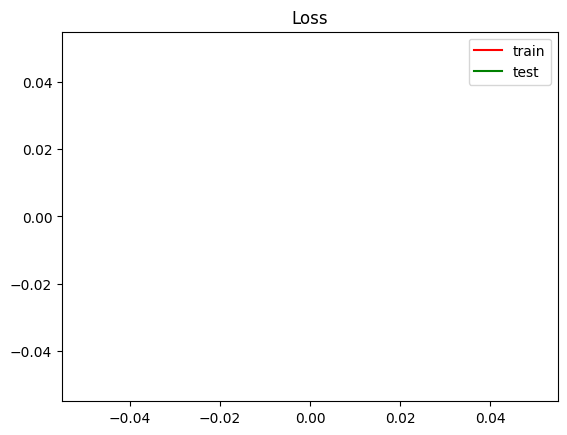

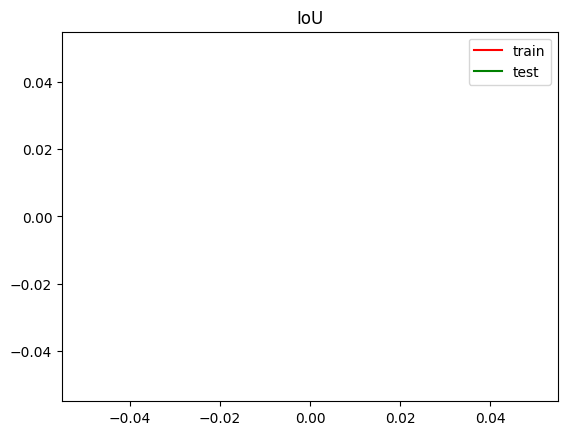

In [ ]:
save_error=True
now = datetime.now() # current date and time
date_time = now.strftime("%mm%dd%Yy%Hh%Mm%Ss")

x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.legend(['train','test'])
plt.title("Loss")

if save_error:
    # plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/loss_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.legend(['train','test'])
plt.title("IoU")


if save_error:
    # plt.savefig('./results/checkpoints/error_prueba'+date_time+'.png',format='png',transparent=True)
    plt.savefig('./results/checkpoints/error_prueba'+date_time+'.pdf',format='pdf',transparent=True)

plt.show()

## TEST loop

In [ ]:
running_test_loss = 0
    running_test_IOU = 0
    ckpt_test_i = 0
    test_i = 0
    # MultiStep=False
    net.eval()
    show=True
    test_i=0
    save_pngs=True
    with torch.no_grad():
        start_time = time.time()
        if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))
        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            test_i += 1
            if ckpt_test_i > test_i:
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

            functional.reset_net(net)
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)
            # if MultiStep:   #sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()

            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0))           # 2 torch.Size([B, 1, 260, 346])
                # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and reduce of TS
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

            if show:
                # spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                # spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)

                # spike_pred = torch.sum(spike_pred, axis = (2),keepdim=True)  #condition to colapse all timesteps in every batch for monitoring only
                # spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                # spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)

                # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                # print("spike_pred numbers from net: ",torch.unique(spike_pred_list[2])," of size: ",spike_pred_list[2].size())
                # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,save_pngs,
                                spikes_input[None,None,e,:,i,:,:], #(B, T=1, C=2, 260, 346)
                                spike_pred_4D[:,None,i,:,:],       # (T, C, 260, 346)
                                spike_mask_4D[:,None,i,:,:],       # (T, C, 260, 346)
                                '\n segm, batch: '+str(e)+' timestep: '+str(i)+' file: '+str(test_i-1)+str(i),
                                '_'+dataset_name+str(test_i-1)+str(i)) # string for file name
               #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            # loss = loss_module(spike_pred_4D, spike_mask_4D,weightbce=0.1)
            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)

            running_test_loss += loss.item()# / spikes_input.size(0)
            spike_pred_4D = torch.round(spike_pred_4D)
            running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

                # process saved metrics
        if test_i != 0:
            epoch_test_loss = running_test_loss / test_i #len(test_loader)
            epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            print("\n test i: ",test_i)
            print("len test loader: ", len(test_loader))
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_IOU))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            print(test_epoch_summary)

         # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.legend(['train','test'])
        plt.title("Loss")

        save_loss=True
        if save_loss: plt.savefig('./results/checkpoints/loss_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.legend(['train','test'])
        plt.title("IoU (%)")

        save_error=True
        if save_error: plt.savefig('./results/checkpoints/error_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
        plt.show()

## PLOTs

In [ ]:
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.title("Loss")
plt.legend([train,test])
plt.show()

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.title("IoU")
plt.legend([train,test])
plt.show()

## initialize variable if new training

In [ ]:
### starts a new training
# from torchsummary import summary
train_loss_vec = []
train_error_vec = []
test_loss_vec = []
test_error_vec = []
running_train_loss = 0
running_train_IOU = 0
running_test_loss = 0
running_test_IOU = 0
ckpt_train_i = 0
ckpt_test_i = 0
train_i = 0
test_i = 0
# epoch_test_loss = 0

# total_MSE = 0
# total_IOU = 0
# scalar_i = 0
# tot_frames = 0
# ckpt_idx_train = 5300  #index of training loop
# ckpt_idx_test = 0  #index of training loop

In [ ]:
print("resuming training from i: "+str(int(ckpt_train_i))+"test_i: "+str(int(ckpt_test_i)))
ckpt_train_i=0

resuming training from i: 0test_i: 0


## start training

In [ ]:
from spikingjelly.activation_based import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

# ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

functional.reset_net(net)
if int(ckpt_train_i) >10:
    print("resuming "+dataset_name+" train from chkpnt: train_i: "+str(int(ckpt_train_i))+", loss: "+str(running_train_loss)+", IOU: "+str(running_train_IOU))
train_i=0
test_i=0
for epoch in range(n_epochs):
    show=False
    net = net.train()                                                   #<--------   0

    start_time = time.time()
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if (data == None):
                # ckpt_i = i
                # print(len(train_loader))
                continue
            train_i += 1
            if ckpt_train_i > train_i:
            #     # print(str(i)+"<"+str(train_i))
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

            optimizer.zero_grad()

            # functional.reset_net(net)                                   #<--------  6
            spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_train = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)
            # if MultiStep:                                               #   sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
            spike_pred_list = net(spikes_input)
            spike_pred = spike_pred_list[0].to(device)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                # spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (1,21,260,346)
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0),keepdim=False)    #reduces B dim           #torch.Size([ 1, 21, 260, 346])
                # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of C dim
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.gt(spike_mask_4D, 1)

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
                print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print(" spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                print(" spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print(" spike_pred numbers to viz: ",torch.unique(spike_pred_viz)," of size: ",spike_pred_viz.size())
                print(" spike_mask numbers to viz: ",torch.unique(spike_mask_viz)," of size: ",spike_mask_viz.size())
                # if spike_pred.size(0) > 10:
                #     for e in range(spike_pred.size(0)): #iterates the batches dim=0
                #         show_learning(fig,False,
                #                     spike_input_5D[None,e,:,:,:,:],
                #                     spike_pred_viz[None,e,:,:,:],
                #                     spike_mask_viz[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # elif spike_pred.size(2) > 10:
                #     for e in range(spike_pred.size(2)): #iterates the time dim=2
                #         show_learning(fig,False,
                #                     spikes_input[None,:,:,e,:,:],
                #                     spike_pred_4D[None,:,e,:,:],
                #                     spike_mask_4D[None,:,e,:,:], 'segm, timestep '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # else:
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    # show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)        #<--------  3
            # loss = vanrossumloss_module(spike_pred_4D, spike_mask_4D,2.0)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
            # loss.backward(retain_graph=False)                                         #<--------  4
            loss.backward()
            optimizer.step()                                        #<--------  5
            functional.reset_net(net)
            # optimizer.zero_grad()                               #<--------   1
            running_train_loss += loss.item() #/ spikes_input.size(0) # loss/batch_number
            spike_pred_4D = torch.round(spike_pred_4D)
            running_train_IOU += getIOU(spike_pred_4D,spike_mask_4D)

            if int(train_i) % 200 <= 1: #condition to save intermediate trainings
                print("saving train_i:"+str(train_i)+", seq:"+str(int(data['file_number']))+",loss: "+str(running_train_loss)+",IOU: "+str(running_train_IOU)+"_"+dataset_name)
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'running_train_loss': running_train_loss,
                'running_train_IOU': running_train_IOU,
                'running_test_loss': running_test_loss,
                'running_test_IOU': running_test_IOU,
                'ckpt_idx_train': train_i,
                'ckpt_idx_test': test_i
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if train_i != 0:
            epoch_train_loss = running_train_loss / train_i # len(train_loader)
            epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
            print("\n train i: ", train_i)
            print("len train loader: ", len(train_loader))
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_IOU))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)
        ckpt_train_i = train_i #temporary variable to transport the state of iterations to test loop
        # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################   TEST LOOP ##################
    if int(ckpt_test_i) >10: print("resuming training from checkpoint: train_i: "+str(ckpt_test_i)+", train_loss: "+str(running_test_loss)+", train_IOU: "+str(running_test_IOU))

    net.eval()
    show=False

    with torch.no_grad():
        start_time = time.time()
        if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))

        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            test_i += 1
            if ckpt_test_i > test_i:
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

            functional.reset_net(net)
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_test = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)
            # if MultiStep:   #sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()

            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                #condition to colapse all timesteps in every batch for monitoring only
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

            running_test_loss += loss.item()# / spikes_input.size(0)
            spike_pred_4D = torch.round(spike_pred_4D)
            running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

            if int(test_i) % 200 <= 1: #condition to save intermediate trainings
                print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+"_"+dataset_name+" "+dataset_name)
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'running_train_loss': running_train_loss,
                'running_train_IOU': running_train_IOU,
                'running_test_loss': running_test_loss,
                'running_test_IOU': running_test_IOU,
                'ckpt_idx_train': train_i,
                'ckpt_idx_test': test_i,
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if test_i != 0:
            epoch_test_loss = running_test_loss / test_i #len(test_loader)
            epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            print("\n test i: ",test_i)
            print("len test loader: ", len(test_loader))
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_IOU))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            print(train_epoch_summary + test_epoch_summary)
            # logfile.write(train_epoch_summary + test_epoch_summary)

        # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)
        now = datetime.now() # current date and time
        date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            # logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        # 'loss': epoch_test_loss,
                        'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec,
                        'running_train_loss': running_train_loss,
                        'running_train_IOU': running_train_IOU,
                        'running_test_loss': running_test_loss,
                        'running_test_IOU': running_test_IOU,
                        'ckpt_idx_train': train_i,
                        'ckpt_idx_test': test_i
                        }, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")

        print("Performance saved: saving model...\n")
        torch.save({'epoch': epoch,
                    'model_state_dict': net.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    # 'loss': epoch_test_loss,
                    'train_loss_vec_dict': train_loss_vec,
                    'test_loss_vec_dict': test_loss_vec,
                    'train_error_vec_dict': train_error_vec,
                    'test_error_vec_dict': test_error_vec,
                    'running_train_loss': running_train_loss,
                    'running_train_IOU': running_train_IOU,
                    'running_test_loss': running_test_loss,
                    'running_test_IOU': running_test_IOU,
                    'ckpt_idx_train': train_i,
                    'ckpt_idx_test': test_i
                    }, "./results/checkpoints/"+ckpt_file+".pth")

        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.legend(['train','test'])
        plt.title("Loss")

        save_loss=True
        if save_loss: plt.savefig('./results/checkpoints/loss_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.legend(['train','test'])
        plt.title("IoU (%)")

        save_error=True
        if save_error: plt.savefig('./results/checkpoints/error_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
        plt.show()

    train_i = 0
    test_i = 0
    ckpt_train_i = 0
    ckpt_test_i = 0
    running_train_loss = 0
    running_train_IOU = 0
    running_test_loss = 0
    running_test_IOU = 0


print("training finished !")

resuming box train from chkpnt: train_i: 2801, loss: 1442.872601673007, IOU: 1148.883424926568


training:   0%|          | 0/23732 [00:00<?, ?it/s]/content/drive/MyDrive/StereoSpike/datasets/MVSEC/mvsec_dataset.py:529: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  depthmask = torch.from_numpy(fullmask)
/content/drive/MyDrive/StereoSpike/datasets/MVSEC/mvsec_dataset.py:529: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (T

saving train_i:2801, seq:2095,loss: 1443.6587424129248,IOU: 1149.0149922554863_box


training:  24%|██▍       | 5641/23732 [19:33<23:08:06,  4.60s/it]

saving train_i:3000, seq:848,loss: 1546.8382825180888,IOU: 1220.656254194517_box


...

training:  57%|█████▋    | 13615/23732 [4:52:48<1:56:26,  1.45it/s]

saving train_i:6200, seq:1520,loss: 2746.471404258162,IOU: 2837.708188316527_box


training:  58%|█████▊    | 13655/23732 [4:52:56<1:24:36,  1.99it/s]

saving train_i:6201, seq:1560,loss: 2746.7514109648764,IOU: 2838.2941038094846_box


training:  60%|█████▉    | 14137/23732 [5:00:02<7:11:13,  2.70s/it]

In [ ]:
from spikingjelly.activation_based import neuron, layer, surrogate
from torch._C import dtype
MultiStep=False
from viz import show_learning

# ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

functional.reset_net(net)
if int(ckpt_train_i) >10:
    print("resuming training from checkpoint: train_i: "+str(ckpt_train_i)+", train_loss: "+str(running_train_loss)+", train_IOU: "+str(running_train_IOU))
train_i=0
test_i=0
for epoch in range(n_epochs):
    show=False
    net = net.train()                                                   #<--------   0

    start_time = time.time()
    with torch.autograd.set_detect_anomaly(True):
        for i, data in enumerate(tqdm(train_loader, desc='training')):  #loader --> train_loader
            if (data == None):
                # ckpt_i = i
                # print(len(train_loader))
                continue
            train_i += 1
            if ckpt_train_i > train_i:
            #     # print(str(i)+"<"+str(train_i))
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

            optimizer.zero_grad()

            # functional.reset_net(net)                                   #<--------  6
            spikes_input = data['spike_tensor']                         #   torch.Size([8, 2, 260, 346, 10]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_train = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)              #   torch.Size([8, 2, 10, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)            # (0,1,4,2,3)
            # if MultiStep:                                               #   sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)                      #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            # spike_pred_list=  net(spikes_input)                       #<--------   2  # len(spike_pred_list) = 4
            spike_pred_list = net(spikes_input)
            spike_pred = spike_pred_list[0].to(device)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                # spike_input_crop  =  spikes_input[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:, :, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4  (1,21,260,346)
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0),keepdim=False)    #reduces B dim           #torch.Size([ 1, 21, 260, 346])
                # spike_input_crop  =  spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of C dim
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2),keepdim=False)           # ([B,2,21,260, 346])  --> ([B,2,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,2,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.gt(spike_mask_4D, 1)

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True) # (B,C,T,H,W) --> (B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      # (B,C,1,H,W) --> (B,1,C,H,W)
                print("\n spike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                print(" spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                print(" spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                print(" spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                print(" spike_pred numbers to viz: ",torch.unique(spike_pred_viz)," of size: ",spike_pred_viz.size())
                print(" spike_mask numbers to viz: ",torch.unique(spike_mask_viz)," of size: ",spike_mask_viz.size())
                # if spike_pred.size(0) > 10:
                #     for e in range(spike_pred.size(0)): #iterates the batches dim=0
                #         show_learning(fig,False,
                #                     spike_input_5D[None,e,:,:,:,:],
                #                     spike_pred_viz[None,e,:,:,:],
                #                     spike_mask_viz[None,e,:,:,:], 'segm, batch '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # elif spike_pred.size(2) > 10:
                #     for e in range(spike_pred.size(2)): #iterates the time dim=2
                #         show_learning(fig,False,
                #                     spikes_input[None,:,:,e,:,:],
                #                     spike_pred_4D[None,:,e,:,:],
                #                     spike_mask_4D[None,:,e,:,:], 'segm, timestep '+str(e),i)                          #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                # else:
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    # show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)        #<--------  3
            # loss = vanrossumloss_module(spike_pred_4D, spike_mask_4D,2.0)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2)        #<--------  3
            # loss.backward(retain_graph=False)                                         #<--------  4
            loss.backward()
            optimizer.step()                                        #<--------  5
            functional.reset_net(net)
            # optimizer.zero_grad()                               #<--------   1
            running_train_loss += loss.item() #/ spikes_input.size(0) # loss/batch_number
            spike_pred_4D = torch.round(spike_pred_4D)
            running_train_IOU += getIOU(spike_pred_4D,spike_mask_4D)


            if int(train_i) % 200 <= 1: #condition to save intermediate trainings
                print("saving training at i: "+str(train_i)+", sequence: "+str(data['file_number'])+", train_loss: "+str(running_train_loss)+", train_IOU: "+str(running_train_IOU))
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'running_train_loss': running_train_loss,
                'running_train_IOU': running_train_IOU,
                'running_test_loss': running_test_loss,
                'running_test_IOU': running_test_IOU,
                'ckpt_idx_train': train_i,
                'ckpt_idx_test': test_i
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if train_i != 0:
            epoch_train_loss = running_train_loss / train_i # len(train_loader)
            epoch_train_IOU = running_train_IOU / train_i #len(train_loader)
            print("\n train i: ", train_i)
            print("len train loader: ", len(train_loader))
            train_loss_vec.append(float(epoch_train_loss))
            train_error_vec.append(float(epoch_train_IOU))
            epoch_train_time = time.time() - start_time
            train_epoch_summary = "Epoch: {}, Train Loss: {}, IOU Error (m): {}, Time: {}\n".format(epoch,epoch_train_loss,epoch_train_IOU,epoch_train_time)
        ckpt_train_i = train_i #temporary variable to transport the state of iterations to test loop
        # tb_writer.add_scalar('train_loss', epoch_train_loss, epoch)
        # tb_writer.add_scalar('train_iou', epoch_train_IOU, epoch)
        #print("spike_pred numbers: ",np.unique(spike_pred.cpu().detach().numpy()))
#################   TEST LOOP ##################
    if int(ckpt_test_i) >10: print("resuming training from checkpoint: train_i: "+str(ckpt_test_i)+", train_loss: "+str(running_test_loss)+", train_IOU: "+str(running_test_IOU))

    net.eval()
    show=False

    with torch.no_grad():
        start_time = time.time()
        if int(test_i) >10: print("resuming testing from i: "+str(int(test_i)))

        for i, data in enumerate(tqdm(test_loader, desc='testing')):  #loader --> train_loader
            if (data == None):
                continue
            test_i += 1
            if ckpt_test_i > test_i:
                continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

            functional.reset_net(net)
            optimizer.zero_grad()
            spikes_input = data['spike_tensor']                 #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
            spikes_masked = data['masked_spike_tensor']
            # ckpt_idx_test = data['file_number']
            spikes_input = spikes_input.permute(0,1,4,2,3)     #   torch.Size([8, 2, 21, 260, 346])
            spikes_masked = spikes_masked.permute(0,1,4,2,3)
            # if MultiStep:   #sums all time steps in the dim=0
            #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
            #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
            spikes_input = spikes_input.to(device)              #   torch.Size([B,C,T,260, 346])
            spikes_masked = spikes_masked.to(device)
            spikes_input.requires_grad_()

            spike_pred_list =  net(spikes_input)                # len(spike_pred_list) = 4
            spike_pred =  spike_pred_list[0].to(device)             # (1,1,260,346)
            # spike_pred = torch.sigmoid(spike_pred)

            if spike_pred.ndim == 4:
                spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                #spike_pred_4D = spike_pred
                spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True) #

            elif spike_pred.ndim == 5:
                spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

            spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False) #or and remove of B dim
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion from bool to numbers
            # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False) #or and reduce of TS
            # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of channels
            # spike_mask_4D = torch.mul(spike_mask_4D,1.)          #conversion to

            # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))       #([B,1,21,260, 346])  --> ([B,1,260, 346])
            # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)       #([B,1,21,260, 346])  --> ([B,1,260, 346])

            if show:
                spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                #condition to colapse all timesteps in every batch for monitoring only
                spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)       #  (B,C,T,H,W)-->(B,C,1,H,W)
                spike_input_5D = spike_input_5D.permute(0,2,1,3,4)      #  (B,1,C,H,W)
                # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                for e in range(spike_pred.size(0)): #iterates the batches dim=0
                    for i in range(spike_pred.size(2)): #iterates the time dim=2
                        show_learning(fig,False,
                                spikes_input[None,None,e,:,i,:,:],
                                spike_pred_4D[:,None,i,:,:],
                                spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

            loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
            # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

            running_test_loss += loss.item()# / spikes_input.size(0)
            spike_pred_4D = torch.round(spike_pred_4D)
            running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

            if int(test_i) % 200 <= 1: #condition to save intermediate trainings
                print("saving testing at i: "+str(i)+", sequence: "+str(data['file_number'])+"")
                torch.save({'epoch': epoch,
                'model_state_dict': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                # 'loss': epoch_test_loss,
                'train_loss_vec_dict': train_loss_vec,
                'test_loss_vec_dict': test_loss_vec,
                'train_error_vec_dict': train_error_vec,
                'test_error_vec_dict': test_error_vec,
                'running_train_loss': running_train_loss,
                'running_train_IOU': running_train_IOU,
                'running_test_loss': running_test_loss,
                'running_test_IOU': running_test_IOU,
                'ckpt_idx_train': train_i,
                'ckpt_idx_test': test_i,
                }, "./results/checkpoints/"+ckpt_file+".pth")

                # process saved metrics
        if test_i != 0:
            epoch_test_loss = running_test_loss / test_i #len(test_loader)
            epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
            print("\n test i: ",test_i)
            print("len test loader: ", len(test_loader))
            test_loss_vec.append(float(epoch_test_loss))
            test_error_vec.append(float(epoch_test_IOU))
            epoch_test_time = time.time() - start_time
            test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
            print(train_epoch_summary + test_epoch_summary)
            # logfile.write(train_epoch_summary + test_epoch_summary)

        # tb_writer.add_scalar('test_loss', epoch_test_loss, epoch)
        # tb_writer.add_scalar('test_iou', epoch_test_IOU, epoch)
        now = datetime.now() # current date and time
        date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
        if epoch_test_loss < net.get_max_accuracy():
            print("Best performances so far: saving model...\n")
            # logfile.write("Best performances so far: saving model...\n")
            net.update_max_accuracy(epoch_test_loss)
            #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
            torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        # 'loss': epoch_test_loss,
                        'train_loss_vec_dict': train_loss_vec,
                        'test_loss_vec_dict': test_loss_vec,
                        'train_error_vec_dict': train_error_vec,
                        'test_error_vec_dict': test_error_vec,
                        'running_train_loss': running_train_loss,
                        'running_train_IOU': running_train_IOU,
                        'running_test_loss': running_test_loss,
                        'running_test_IOU': running_test_IOU,
                        'ckpt_idx_train': train_i,
                        'ckpt_idx_test': test_i
                        }, "./results/checkpoints/best_"+ckpt_file+"_"+date_time+".pth")

        print("Performance saved: saving model...\n")
        torch.save({'epoch': epoch,
                    'model_state_dict': net.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    # 'loss': epoch_test_loss,
                    'train_loss_vec_dict': train_loss_vec,
                    'test_loss_vec_dict': test_loss_vec,
                    'train_error_vec_dict': train_error_vec,
                    'test_error_vec_dict': test_error_vec,
                    'running_train_loss': running_train_loss,
                    'running_train_IOU': running_train_IOU,
                    'running_test_loss': running_test_loss,
                    'running_test_IOU': running_test_IOU,
                    'ckpt_idx_train': train_i,
                    'ckpt_idx_test': test_i
                    }, "./results/checkpoints/"+ckpt_file+".pth")

        net.increment_epoch()
        scheduler.step()
        # Training/testing plots
        x=[x for x in range(len(train_loss_vec))]
        y=[y for y in range(len(test_loss_vec))]
        plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
        plt.legend(['train','test'])
        plt.title("Loss")

        save_loss=True
        if save_loss: plt.savefig('./results/checkpoints/loss_test'+dataset_name+date_time+'.png',format='png',transparent=True)
        plt.show()

        x=[x for x in range(len(train_error_vec))]
        y=[y for y in range(len(test_error_vec))]
        plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
        plt.legend(['train','test'])
        plt.title("IoU (%)")

        save_error=True
        if save_error: plt.savefig('./results/checkpoints/error_test'+dataset_name+date_time+'.png',format='png',transparent=True)
        plt.show()

    train_i = 0
    test_i = 0
    ckpt_train_i = 0
    ckpt_test_i = 0
    running_train_loss = 0
    running_train_IOU = 0
    running_test_loss = 0
    running_test_IOU = 0


print("training finished !")

In [ ]:
torch.save({'epoch': epoch,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_test_loss,
            'train_loss_vec_dict': train_loss_vec,
            'test_loss_vec_dict': test_loss_vec,
            'train_error_vec_dict': train_error_vec,
            'test_error_vec_dict': test_error_vec,
            'ckpt_idx_train': ckpt_idx_train,
            'ckpt_idx_test': ckpt_idx_test
            }, "./results/checkpoints/poolingnet3d_seg_if_orgnl_box_lifnode.pth")
# torch.save(train_loader,"./results/checkpoints/train_loader_poolingnet3d_seg_if_orgnl_box_lifnode.pth")
# torch.save(test_loader,"./results/checkpoints/test_loader_poolingnet3d_seg_if_orgnl_box_lifnode.pth")
###

In [ ]:
checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_floor_lifnode.pth') #poolingnet3d_seg_if_orgnl_floor_lifnode.pth
train_loss_vec = checkpoint['train_loss_vec_dict']
test_loss_vec = checkpoint['test_loss_vec_dict']
train_error_vec = checkpoint['train_error_vec_dict']
test_error_vec = checkpoint['test_error_vec_dict']
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
epoch_test_loss = checkpoint['loss']
ckpt_idx_test = checkpoint['ckpt_idx_test']
ckpt_idx_train = checkpoint['ckpt_idx_train']
net.update_max_accuracy(epoch_test_loss)

In [ ]:
x=[x for x in range(len(train_loss_vec))]
y=[y for y in range(len(test_loss_vec))]
plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
plt.legend(['train','test'])
plt.title("Loss")
plt.show()
save_loss=True
if save_loss: plt.savefig('./results/checkpoints/loss_.pdf',format='pdf')

x=[x for x in range(len(train_error_vec))]
y=[y for y in range(len(test_error_vec))]
plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
plt.legend(['train','test'])
plt.title("IoU (%)")
plt.show()
save_error=True
if save_error: plt.savefig('./results/checkpoints/error_.pdf',format='pdf')

In [ ]:
epoch_test_loss = 0
torch.save({'epoch': epoch, 'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_test_loss, 'train_loss_vec_dict': train_loss_vec,
            'test_loss_vec_dict': test_loss_vec,
            'train_error_vec_dict': train_error_vec,
            'test_error_vec_dict': test_error_vec
            }, "./results/checkpoints/poolingnet_seg3d_if_orgnl_table_lifnode.pth")

 Evaluar

Scheduler's parameters: 

{
    "milestones": {
        "10": 1,
        "20": 1,
        "40": 1,
        "80": 1,
        "160": 1,
        "320": 1
    },
    "gamma": 0.5,
    "base_lrs": [
        0.0005
    ],
    "last_epoch": 0,
    "verbose": false,
    "_step_count": 1,
    "_get_lr_called_within_step": false,
    "_last_lr": [
        0.0005
    ]
}


testing:   1%|          | 22/2994 [00:30<21:49,  2.27it/s]

segm, batch: 0 timestep: 0


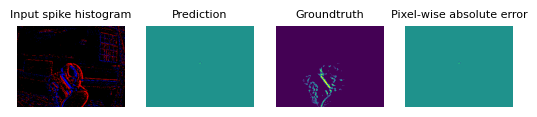

segm, batch: 0 timestep: 1


<Figure size 640x480 with 0 Axes>

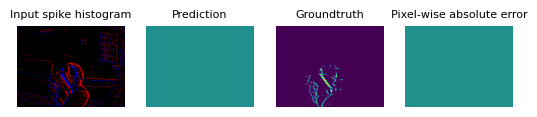

segm, batch: 0 timestep: 2


<Figure size 640x480 with 0 Axes>

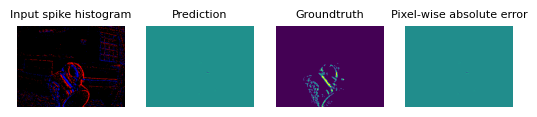

segm, batch: 0 timestep: 3


<Figure size 640x480 with 0 Axes>

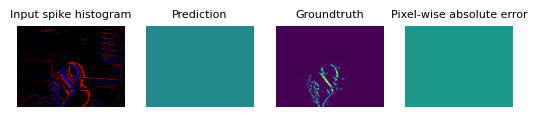

segm, batch: 0 timestep: 4


<Figure size 640x480 with 0 Axes>

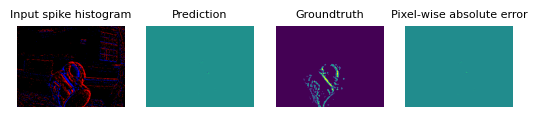

segm, batch: 0 timestep: 5


<Figure size 640x480 with 0 Axes>

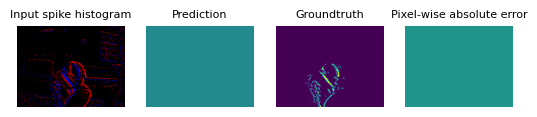

segm, batch: 0 timestep: 6


<Figure size 640x480 with 0 Axes>

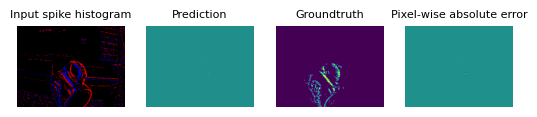

testing:   1%|          | 22/2994 [00:50<21:49,  2.27it/s]

segm, batch: 0 timestep: 7


<Figure size 640x480 with 0 Axes>

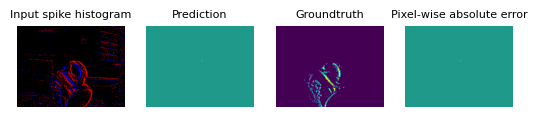

segm, batch: 0 timestep: 8


<Figure size 640x480 with 0 Axes>

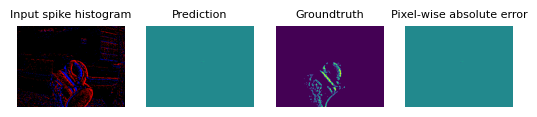

segm, batch: 0 timestep: 9


<Figure size 640x480 with 0 Axes>

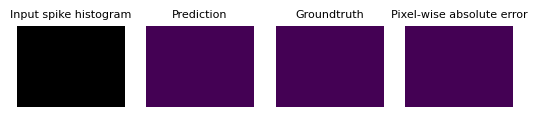

testing:   1%|          | 23/2994 [00:53<2:53:32,  3.50s/it]

segm, batch: 0 timestep: 0


<Figure size 640x480 with 0 Axes>

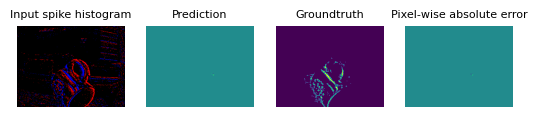

segm, batch: 0 timestep: 1


<Figure size 640x480 with 0 Axes>

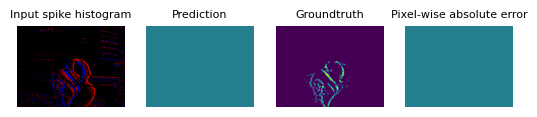

segm, batch: 0 timestep: 2


<Figure size 640x480 with 0 Axes>

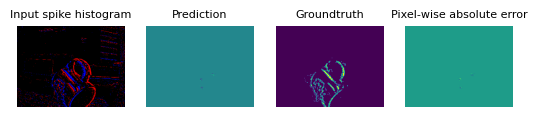

segm, batch: 0 timestep: 3


<Figure size 640x480 with 0 Axes>

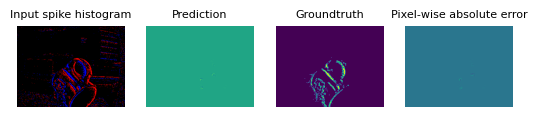

segm, batch: 0 timestep: 4


<Figure size 640x480 with 0 Axes>

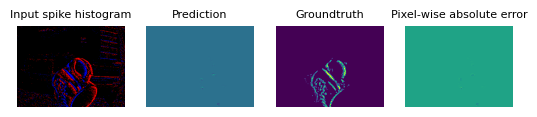

segm, batch: 0 timestep: 5


<Figure size 640x480 with 0 Axes>

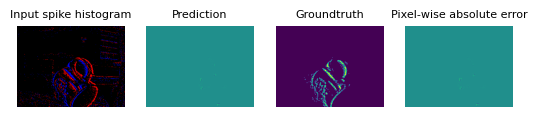

segm, batch: 0 timestep: 6


<Figure size 640x480 with 0 Axes>

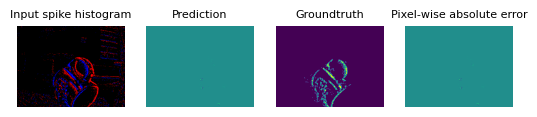

segm, batch: 0 timestep: 7


<Figure size 640x480 with 0 Axes>

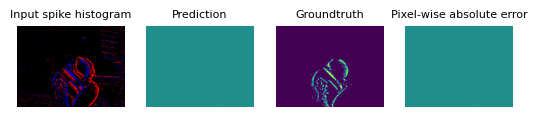

segm, batch: 0 timestep: 8


<Figure size 640x480 with 0 Axes>

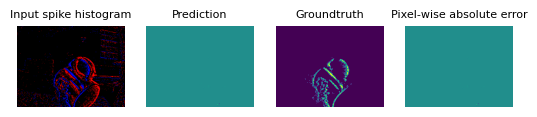

segm, batch: 0 timestep: 9


<Figure size 640x480 with 0 Axes>

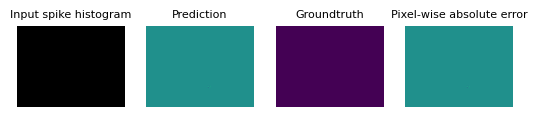

testing:   1%|          | 24/2994 [01:07<4:17:13,  5.20s/it]

segm, batch: 0 timestep: 0


<Figure size 640x480 with 0 Axes>

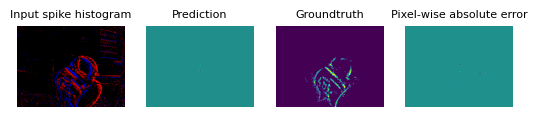

segm, batch: 0 timestep: 1


<Figure size 640x480 with 0 Axes>

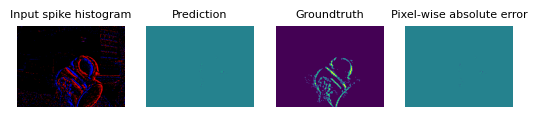

segm, batch: 0 timestep: 2


<Figure size 640x480 with 0 Axes>

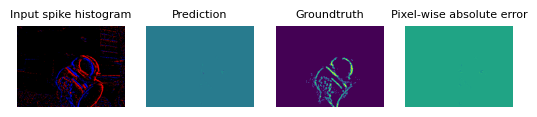

segm, batch: 0 timestep: 3


<Figure size 640x480 with 0 Axes>

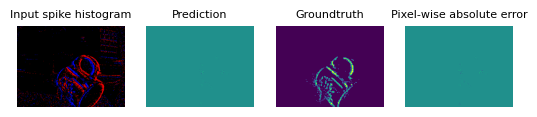

segm, batch: 0 timestep: 4


<Figure size 640x480 with 0 Axes>

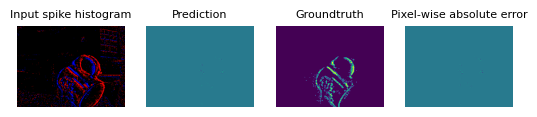

segm, batch: 0 timestep: 5


<Figure size 640x480 with 0 Axes>

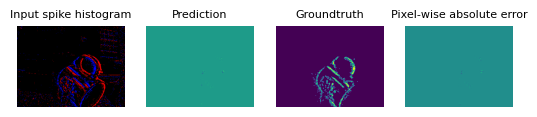

segm, batch: 0 timestep: 6


<Figure size 640x480 with 0 Axes>

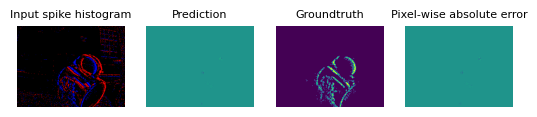

segm, batch: 0 timestep: 7


<Figure size 640x480 with 0 Axes>

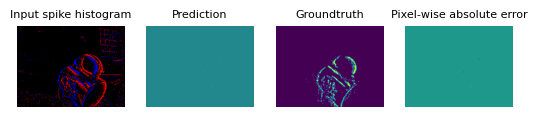

segm, batch: 0 timestep: 8


<Figure size 640x480 with 0 Axes>

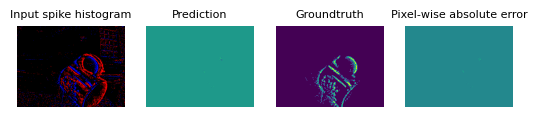

segm, batch: 0 timestep: 9


<Figure size 640x480 with 0 Axes>

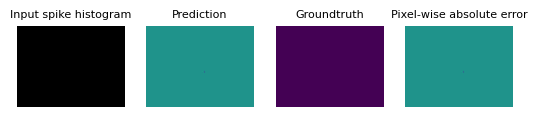

testing:   1%|          | 25/2994 [01:21<5:40:22,  6.88s/it]

segm, batch: 0 timestep: 0


<Figure size 640x480 with 0 Axes>

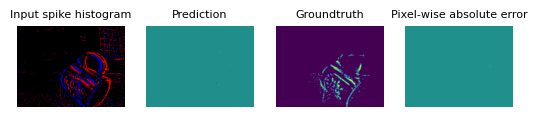

segm, batch: 0 timestep: 1


<Figure size 640x480 with 0 Axes>

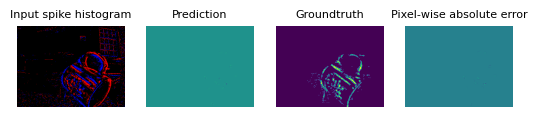

segm, batch: 0 timestep: 2


<Figure size 640x480 with 0 Axes>

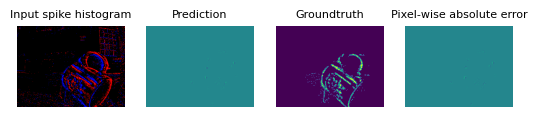

segm, batch: 0 timestep: 3


<Figure size 640x480 with 0 Axes>

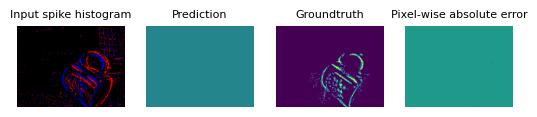

segm, batch: 0 timestep: 4


<Figure size 640x480 with 0 Axes>

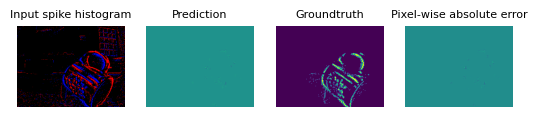

segm, batch: 0 timestep: 5


<Figure size 640x480 with 0 Axes>

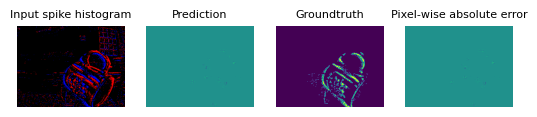

segm, batch: 0 timestep: 6


<Figure size 640x480 with 0 Axes>

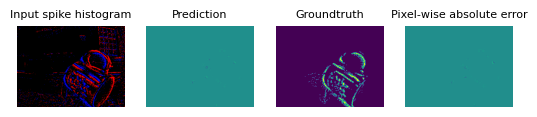

segm, batch: 0 timestep: 7


<Figure size 640x480 with 0 Axes>

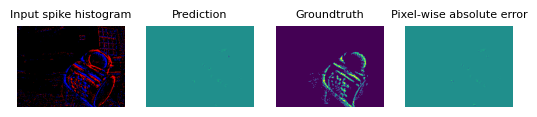

segm, batch: 0 timestep: 8


<Figure size 640x480 with 0 Axes>

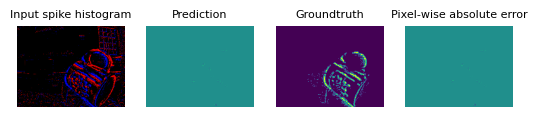

segm, batch: 0 timestep: 9


<Figure size 640x480 with 0 Axes>

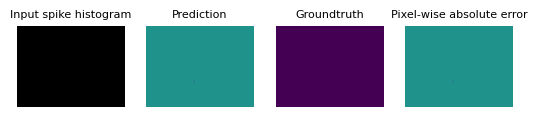

testing:   1%|          | 26/2994 [01:35<6:53:47,  8.37s/it]

segm, batch: 0 timestep: 0


<Figure size 640x480 with 0 Axes>

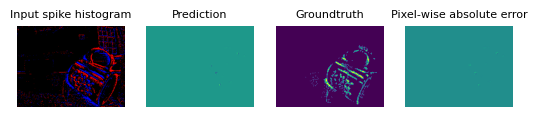

segm, batch: 0 timestep: 1


<Figure size 640x480 with 0 Axes>

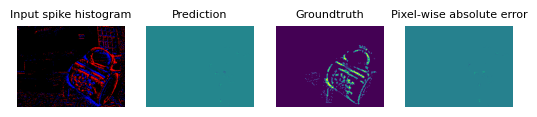

segm, batch: 0 timestep: 2


<Figure size 640x480 with 0 Axes>

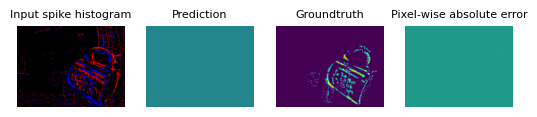

segm, batch: 0 timestep: 3


<Figure size 640x480 with 0 Axes>

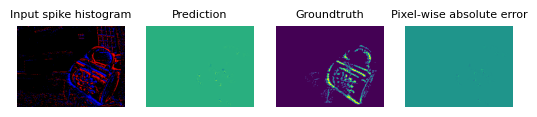

segm, batch: 0 timestep: 4


<Figure size 640x480 with 0 Axes>

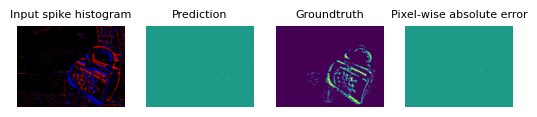

segm, batch: 0 timestep: 5


<Figure size 640x480 with 0 Axes>

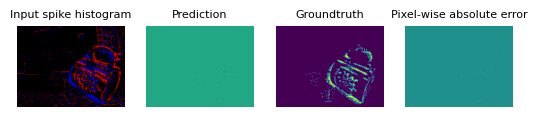

segm, batch: 0 timestep: 6


<Figure size 640x480 with 0 Axes>

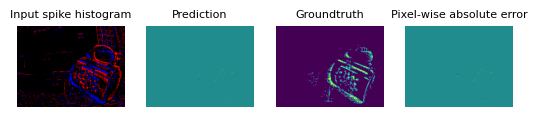

segm, batch: 0 timestep: 7


<Figure size 640x480 with 0 Axes>

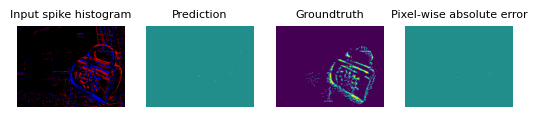

segm, batch: 0 timestep: 8


<Figure size 640x480 with 0 Axes>

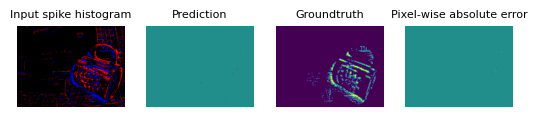

segm, batch: 0 timestep: 9


<Figure size 640x480 with 0 Axes>

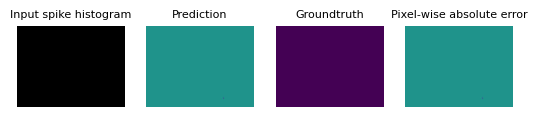

testing:   1%|          | 27/2994 [01:49<8:03:09,  9.77s/it]

segm, batch: 0 timestep: 0


<Figure size 640x480 with 0 Axes>

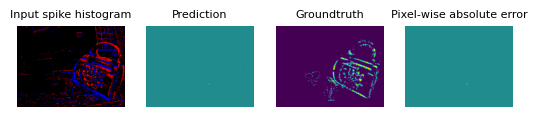

segm, batch: 0 timestep: 1


<Figure size 640x480 with 0 Axes>

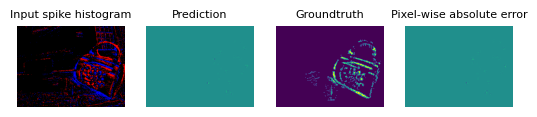

segm, batch: 0 timestep: 2


<Figure size 640x480 with 0 Axes>

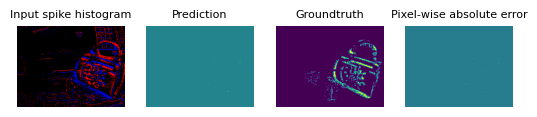

segm, batch: 0 timestep: 3


<Figure size 640x480 with 0 Axes>

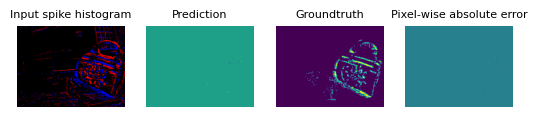

segm, batch: 0 timestep: 4


<Figure size 640x480 with 0 Axes>

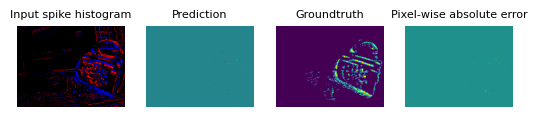

segm, batch: 0 timestep: 5


<Figure size 640x480 with 0 Axes>

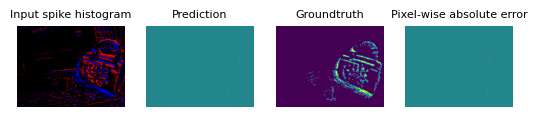

segm, batch: 0 timestep: 6


<Figure size 640x480 with 0 Axes>

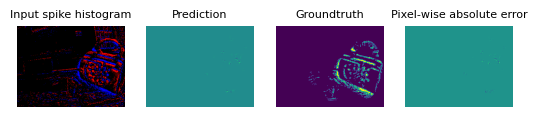

segm, batch: 0 timestep: 7


<Figure size 640x480 with 0 Axes>

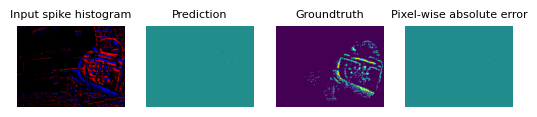

segm, batch: 0 timestep: 8


testing:   1%|          | 27/2994 [02:02<3:43:52,  4.53s/it]

saving training before exit....keyboardinterrupt


<Figure size 640x480 with 0 Axes>

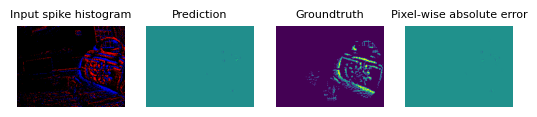

In [ ]:
import json
# # print("./results/checkpoints/"+ckpt_file+"5.pth")
# ckpt_file = "poolingnet3d_seg_lif_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)
# ckpt_file = "poolingnet3d_seg_"+neuron_type+"_orgnl_"+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience)


# checkpoint_path = "./results/checkpoints/"+ckpt_file+".pth"
# # # checkpoint = torch.load('./results/checkpoints/poolingnet3d_seg_if_orgnl_'+dataset_name+'_lifnode.pth')
# # checkpoint = torch.load("./results/checkpoints/"+ckpt_file+"5.pth")
# checkpoint = torch.load(checkpoint_path)
# print("Starting training: "+checkpoint)
import sys
try:
    from spikingjelly.activation_based import neuron, layer, surrogate
    from torch._C import dtype
    MultiStep=False
    from viz import show_learning

    # ckpt_file = "poolingnet3d_seg_SEW3D"+dataset_name+"_lifnode"

    functional.reset_net(net)
    # if int(ckpt_train_i) >10:
    #     print("resuming training of "+dataset_name+" in epoch "+str(net.epoch)+" from chkpnt: train_i: "+str(int(ckpt_train_i))+", loss: "+str(running_train_loss)+", IOU: "+str(running_train_IOU))
    train_i=0
    test_i=0

    test_done = False

    for epoch in range(n_epochs):
        print("Scheduler's parameters: \n")
        print(json.dumps(scheduler.state_dict(), indent=4))
        show=True

    #################   TEST LOOP ##################
        # if int(ckpt_test_i) >10:
        #     print("resuming testing in epoch "+str(net.epoch)+ "from checkpoint: test_i: "+str(ckpt_test_i)+", test_loss: "+str(running_test_loss)+", test_IOU: "+str(running_test_IOU))

        net.eval()
        show=True

        with torch.no_grad():
            start_time = time.time()
            if int(test_i) >10: print("resuming testing from sequence: "+str(int(test_i)))

            for i, data in enumerate(tqdm(test_loader, desc='testing')):                #loader --> train_loader
                if test_done == True:
                    break
                if (data == None):
                    continue
                test_i += 1
                # if ckpt_test_i > test_i:
                #     continue # skips batches until it arrives to checkpoint of an incomplete epoch of training

                functional.reset_net(net)
                optimizer.zero_grad()
                spikes_input = data['spike_tensor']                                     #   torch.Size([8, 2, 260, 346, 21]) (B,C,H,W,T)
                spikes_masked = data['masked_spike_tensor']
                # ckpt_idx_test = data['file_number']
                spikes_input = spikes_input.permute(0,1,4,2,3)                          #   torch.Size([8, 2, 21, 260, 346])
                spikes_masked = spikes_masked.permute(0,1,4,2,3)
                # if MultiStep:   #sums all time steps in the dim=0
                #     spikes_input  = torch.sum(spikes_input, axis=0,keepdim=True)
                #     spikes_masked = torch.sum(spikes_masked,axis=0,keepdim=True)
                spikes_input = spikes_input.to(device)                                  #   torch.Size([B,C,T,260, 346])
                # us = nn.Upsample(scale_factor = 0.6937, mode='trilinear')
                # spikes_input = us(spikes_input)
                spikes_masked = spikes_masked.to(device)
                # spikes_masked = us(spikes_masked)
                # spikes_input.requires_grad_()
                spike_pred_list =  net(spikes_input)                                    # len(spike_pred_list) = 4
                spike_pred =  spike_pred_list[0].to(device)                             # (1,1,260,346)
                # spike_pred = torch.sigmoid(spike_pred)

                if spike_pred.ndim == 4:
                    spike_input_crop = spikes_input[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]       #ndim 4 (B,2,21,260,346)
                    spikes_masked_crop = spikes_masked[:,:, :, :spike_pred.size(2), :spike_pred.size(3)]    #ndim 4
                    #spike_pred_4D = spike_pred
                    spike_pred_4D = torch.sum(spike_pred, axis = (1),keepdim=True)      #

                elif spike_pred.ndim == 5:
                    spike_pred_4D = torch.sum(spike_pred, axis = (0))           #torch.Size([B, 1, 260, 346])
                    # spike_input_crop = spikes_input[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]       #ndim 5
                    spikes_masked_crop = spikes_masked[:spike_pred.size(0), :spike_pred.size(1), :spike_pred.size(2), :spike_pred.size(3),:spike_pred.size(4)]    #ndim 5

                spike_mask_4D = torch.any(spikes_masked_crop, dim = 0,keepdim=False)    #or and remove of B dim
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)        #or of channels
                spike_mask_4D = torch.mul(spike_mask_4D,1.)                             #conversion from bool to numbers
                # spike_mask_4D = torch.any(spikes_masked_crop, dim = 2,keepdim=False)  #or and reduce of TS
                # spike_mask_4D = torch.any(spike_mask_4D, dim = 1,keepdim=True)        #or of channels
                # spike_mask_4D = torch.mul(spike_mask_4D,1.)                           #conversion to

                # spike_mask_4D = torch.sum(spikes_masked_crop, axis = (2))             #([B,1,21,260, 346])  --> ([B,1,260, 346])
                # spike_mask_4D = torch.sum(spike_mask_4D, axis = (1),keepdim=True)     #([B,1,21,260, 346])  --> ([B,1,260, 346])

                if show:
                    spike_mask_viz = torch.any(spike_mask_4D, dim = 1,keepdim=True)      #or of TS dim
                    spike_pred_viz = torch.sum(spike_pred_4D, axis = (1),keepdim=True)
                    #condition to colapse all timesteps in every batch for monitoring only
                    spike_input_5D = torch.sum(spikes_input, axis = (2),keepdim=True)   #  (B,C,T,H,W)-->(B,C,1,H,W)
                    spike_input_5D = spike_input_5D.permute(0,2,1,3,4)                  #  (B,1,C,H,W)
                    # print("\nspike_input numbers to net: ",torch.unique(spikes_input)," of size: ",spikes_input.size())
                    # print("spike_pred numbers from net: ",torch.unique(spike_pred)," of size: ",spike_pred.size())
                    # print("spike_mask numbers from db: ",torch.unique(spikes_masked)," of size: ",spikes_masked.size())
                    # print("spike_input 5d numbers to viz: ",torch.unique(spike_input_5D)," of size: ",spike_input_5D.size())
                    # print("spike_pred numbers to loss/viz: ",torch.unique(spike_pred_4D)," of size: ",spike_pred_4D.size())
                    # print("spike_mask numbers to loss/viz: ",torch.unique(spike_mask_4D)," of size: ",spike_mask_4D.size())
                    for e in range(spike_pred.size(0)): #iterates the batches dim=0
                        for i in range(spike_pred.size(2)): #iterates the time dim=2
                            show_learning(fig,True,
                                    spikes_input[None,None,e,:,i,:,:],
                                    spike_pred_4D[:,None,i,:,:],
                                    spike_mask_4D[:,None,i,:,:], 'segm, batch: '+str(e)+' timestep: '+str(i),i)           #plt.fig,Save,[B,1,2,260,346],[B, 1, 260, 346], [B, 1, 260, 346], text,       i
                    #show_learning(fig,False, spike_input_5D, spike_pred_4D, spike_mask_4D, 'segmentacion',i)

                loss = bcediceloss_module(spike_pred_4D, spike_mask_4D,weightbce=0.5)
                # loss = loss_module(spike_pred_4D, spike_mask_4D,tau=2.)

                running_test_loss += loss.item()# / spikes_input.size(0)
                spike_pred_4D = torch.round(spike_pred_4D)
                running_test_IOU += getIOU(spike_pred_4D, spike_mask_4D)

                # if i == (len(test_loader)-1):
                #     print("Testing loop finished")
                #     test_done = 1
                # print(len(test_loader))
                # print(i)
                # if int(test_i) % 100 <= 0: #condition to save intermediate trainings
                #     checkpoint = {'epoch': net.epoch,
                #                 'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(),
                #                 'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                #                 'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                #                 'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                #                 'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                #                 'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                #                 'train_done': train_done,'test_done': test_done,
                #                 'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                #                 'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                #     print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                #     torch.save(checkpoint, checkpoint_path)
                #     ckpt_test_i = test_i

            if test_done == False:
                # epoch_test_loss = running_test_loss / test_i #len(test_loader)
                # epoch_test_IOU = running_test_IOU / test_i #len(test_loader)
                # print("\n Procesed test sequences: ",test_i)
                # print("len test loader: ", len(test_loader))
                # test_loss_vec.append(float(epoch_test_loss))
                # test_error_vec.append(float(epoch_test_IOU))
                # epoch_test_time = time.time() - start_time
                # test_epoch_summary = "Epoch: {}, Test Loss: {}, Test IOU Error (m): {}, Time: {}\n".format(net.epoch, epoch_test_loss,epoch_test_IOU,epoch_test_time)
                # print(str(train_epoch_summary) + str(test_epoch_summary))

                # net.increment_epoch()
                # scheduler.step(epoch_test_loss)
                test_done = True

                # print("saving test at i: "+str(i)+", seq: "+str(data['file_number'])+",loss: "+str(running_test_loss)+",IOU: "+str(running_test_IOU)+" for "+dataset_name)
                # checkpoint = {'epoch': net.epoch,
                #             'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(), 'scheduler_state_dict': scheduler.state_dict(),
                #             'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
                #             'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
                #             'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
                #             'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
                #             'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
                #             'train_done': train_done,'test_done': test_done,
                #             'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
                #             'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
                # print("Test finished, saving...")
                # torch.save(checkpoint, checkpoint_path)
                # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                now = datetime.now() # current date and time
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
                print("Performance saved: saving model...\n")

                # torch.save(checkpoint, checkpoint_path)
                # # print("The size of the integer variable is:",sys.getsizeof(checkpoint), "bytes.")

                # if epoch_test_loss < net.get_max_accuracy():
                #     print("Best performances so far: saving model...\n")
                #     # logfile.write("Best performances so far: saving model...\n")
                #     net.update_max_accuracy(epoch_test_loss)
                #     #torch.save(net.state_dict(), "./results/checkpoints/stereospike_seg_sergio.pth")
                #     torch.save(checkpoint, "./results/checkpoints/best_epoch"+str(scheduler.last_epoch)+"_"+ckpt_file+"_"+date_time+".pth")

            else:
                print("Skipping testing loop")
                date_time = now.strftime("%m-%d-%Y-%Hh%Mm%Ss")
    ################# Training/testing plots
            x=[x for x in range(len(train_loss_vec))]
            y=[y for y in range(len(test_loss_vec))]
            plt.plot(x,train_loss_vec,'r-',y,test_loss_vec,'g-')
            plt.legend(['train','test'])
            plt.title("Loss of "+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience))

            save_loss=False
            if save_loss: plt.savefig('./results/checkpoints/loss_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

            x=[x for x in range(len(train_error_vec))]
            y=[y for y in range(len(test_error_vec))]
            plt.plot(x,train_error_vec,'r-',y,test_error_vec,'g-')
            plt.legend(['train','test'])
            plt.title("IoU (%) of "+dataset_name+"_lr"+str(lr)+"_mbgr"+str(maxBackgroundRatio)+"_rf"+str(reduce_factor)+"_wd"+str(wd)+"_p"+str(patience))

            save_error=False
            if save_error: plt.savefig('./results/checkpoints/error_test_'+dataset_name+"_"+date_time+'.pdf',format='pdf',transparent=True)
            plt.show()

        train_i = 0
        test_i = 0
        ckpt_train_i = 0
        ckpt_test_i = 0
        test_done = False
        train_done = False
        epoch += 1

        running_train_loss = 0
        running_train_IOU = 0
        running_test_loss = 0
        running_test_IOU = 0
        test_epoch_summary = 0
        train_epoch_summary = 0
        print("training epoch " +str(net.epoch)+" finished !")

    print("training finished !")
except KeyboardInterrupt:
    print("saving training before exit....keyboardinterrupt")
    # ckpt_train_i = train_i
    # ckpt_test_i = test_i
    # checkpoint = {'epoch': epoch,
    #         'model_state_dict': net.state_dict(),'optimizer_state_dict': optimizer.state_dict(),
    #         'train_loss_vec_dict': train_loss_vec,'test_loss_vec_dict': test_loss_vec,
    #         'train_error_vec_dict': train_error_vec,'test_error_vec_dict': test_error_vec,
    #         'running_train_loss': running_train_loss,'running_train_IOU': running_train_IOU,
    #         'running_test_loss': running_test_loss,'running_test_IOU': running_test_IOU,
    #         'ckpt_idx_train': train_i,'ckpt_idx_test': test_i,
    #         'train_done': train_done,'test_done': test_done,
    #         'epoch_train_loss': epoch_train_loss,'epoch_test_loss': epoch_test_loss,
    #         'train_epoch_summary':train_epoch_summary,'test_epoch_summary':test_epoch_summary }
    # torch.save(checkpoint, checkpoint_path)
    # torch.save(checkpoint, "./results/checkpoints/"+ckpt_file+".pth")

except OSError:
    print("saving training before exit.... oserror")
    # import os
    # os.kill(os.getpid(), 9)

else:
     print("saving training before exit....")